In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl

#path = 'C:/Users/schirmacher3/PycharmProjects/gnn-for-ppi/pretest_results/BRCA'
path = 'C:/Users/julia/PycharmProjects/gnn-for-ppi/pretest_results/BRCA'

#FULL DATA
MLP_results = pd.read_csv(path+'/MLP/results_outer_extended.csv')
GCN_results = pd.read_csv(path+'/GCN/results_outer_extended.csv')
GCN2MLP_results = pd.read_csv(path+'/GCN2MLP/results_outer_extended.csv')
GAT_results = pd.read_csv(path+'/GAT/results_outer_extended.csv')
GAT2MLP_results = pd.read_csv(path+'/GAT2MLP/results_outer_extended.csv')
ChebNet_results = pd.read_csv(path+'/ChebNet/results_outer_extended.csv')
ChebNet2MLP_results = pd.read_csv(path+'/ChebNet2MLP/results_outer_extended.csv')


#METHYLATION
mMLP_results = pd.read_csv(path+'/mMLP/results_outer_extended.csv')
mGCN_results = pd.read_csv(path+'/mGCN/results_outer_extended.csv')
mGCN2MLP_results = pd.read_csv(path+'/mGCN2MLP/results_outer_extended.csv')
mGAT_results = pd.read_csv(path+'/mGAT/results_outer_extended.csv')
mGAT2MLP_results = pd.read_csv(path+'/mGAT2MLP/results_outer_extended.csv')
mChebNet_results = pd.read_csv(path+'/mChebNet/results_outer_extended.csv')
mChebNet2MLP_results = pd.read_csv(path+'/mChebNet2MLP/results_outer_extended.csv')

# EXPRESSION
xMLP_results = pd.read_csv(path+'/xMLP/results_outer_extended.csv')
xGCN_results = pd.read_csv(path+'/xGCN/results_outer_extended.csv')
xGCN2MLP_results = pd.read_csv(path+'/xGCN2MLP/results_outer_extended.csv')
xGAT_results = pd.read_csv(path+'/xGAT/results_outer_extended.csv')
xGAT2MLP_results = pd.read_csv(path+'/xGAT2MLP/results_outer_extended.csv')
xChebNet_results = pd.read_csv(path+'/xChebNet/results_outer_extended.csv')
xChebNet2MLP_results = pd.read_csv(path+'/xChebNet2MLP/results_outer_extended.csv')


In [11]:
max_mcc_full = max([ MLP_results['val_mcc'].max(),
                GCN_results['val_mcc'].max(),
                GAT_results['val_mcc'].max(),
                GCN2MLP_results['val_mcc'].max(),
                GAT2MLP_results['val_mcc'].max(),
                ChebNet_results['val_mcc'].max(),
                ChebNet2MLP_results['val_mcc'].max(),
                ])

min_mcc_full = min([ MLP_results['val_mcc'].min(),
                GCN_results['val_mcc'].min(),
                GAT_results['val_mcc'].min(),
                GCN2MLP_results['val_mcc'].min(),
                GAT2MLP_results['val_mcc'].min(),
                ChebNet_results['val_mcc'].min(),
                ChebNet2MLP_results['val_mcc'].min(),
                ])

max_mcc_methyl = max([ mMLP_results['val_mcc'].max(),
                mGCN_results['val_mcc'].max(),
                mGAT_results['val_mcc'].max(),
                mGCN2MLP_results['val_mcc'].max(),
                mGAT2MLP_results['val_mcc'].max(),
                mChebNet_results['val_mcc'].max(),
                mChebNet2MLP_results['val_mcc'].max(),
                ])

min_mcc_methyl = min([ mMLP_results['val_mcc'].min(),
                mGCN_results['val_mcc'].min(),
                mGAT_results['val_mcc'].min(),
                mGCN2MLP_results['val_mcc'].min(),
                mGAT2MLP_results['val_mcc'].min(),
                mChebNet_results['val_mcc'].min(),
                mChebNet2MLP_results['val_mcc'].min(),
                ])

max_mcc_expr = max([ xMLP_results['val_mcc'].max(),
                xGCN_results['val_mcc'].max(),
                xGAT_results['val_mcc'].max(),
                xGCN2MLP_results['val_mcc'].max(),
                xGAT2MLP_results['val_mcc'].max(),
                xChebNet_results['val_mcc'].max(),
                xChebNet2MLP_results['val_mcc'].max(),
                ])

min_mcc_expr = min([xMLP_results['val_mcc'].min(),
                xGCN_results['val_mcc'].min(),
                xGAT_results['val_mcc'].min(),
                xGCN2MLP_results['val_mcc'].min(),
                xGAT2MLP_results['val_mcc'].min(),
                xChebNet_results['val_mcc'].min(),
                xChebNet2MLP_results['val_mcc'].min(),
                ])

In [12]:
# VIOLINPLOTS
import matplotlib.gridspec as gridspec
import seaborn as sns

def violin_analysis_advanced(outer_axis, data, min_val, max_val):
    learning_rates = np.sort(data['config/train_loop_config/learning_rate'].unique())
    dropout_rates = np.sort(data['config/train_loop_config/dropout_rate'].unique())
    weight_decays = np.sort(data['config/train_loop_config/weight_decay'].unique())

    gs = gridspec.GridSpecFromSubplotSpec(3,5, subplot_spec=outer_axis.get_subplotspec(), wspace=0.6, hspace=0.2)
    ax = np.array([plt.Subplot(outer_axis.figure, gs[i,j]) for i in range(3) for j in range(5)]).reshape((3,5))

    ax[0,0].set_ylabel('Learning rate')
    ax[1,0].set_ylabel('Dropout rate')
    ax[2,0].set_ylabel('Weight decay')

    for idx, lr in enumerate(learning_rates):
        val = data[data['config/train_loop_config/learning_rate']==lr]['val_mcc'].to_list()
        ax[0,idx].violinplot(val)
        ax[0,idx].set_xlabel(lr)
        ax[0,idx].set_xticks([])

    for idx, dp in enumerate(dropout_rates):
        val = data[data['config/train_loop_config/dropout_rate']==dp]['val_mcc'].to_list()
        ax[1,idx].violinplot(val)
        ax[1,idx].set_xlabel(dp)
        ax[1,idx].set_xticks([])

    for idx, wd in enumerate(weight_decays):
        val = data[data['config/train_loop_config/weight_decay']==wd]['val_mcc'].to_list()
        ax[2,idx].violinplot(val)
        ax[2,idx].set_xlabel(wd)
        ax[2,idx].set_xticks([])
              
    for i in range(3):
        for j in range(5):
            ax[i,j].set_ylim([min_val, max_val])
            outer_axis.figure.add_subplot(ax[i,j])
    plt.tight_layout()
    

def violin_analysis_advanced_gat(outer_axis, data, min_val, max_val):
    learning_rates = np.sort(data['config/train_loop_config/learning_rate'].unique())
    dropout_rates_normal = np.sort(data['config/train_loop_config/dropout_rate_normal'].unique())
    dropout_rates_attention = np.sort(data['config/train_loop_config/dropout_rate_attention'].unique())
    weight_decays = np.sort(data['config/train_loop_config/weight_decay'].unique())

    gs = gridspec.GridSpecFromSubplotSpec(4,5, subplot_spec=outer_axis.get_subplotspec(), wspace=0.7, hspace=0.3)
    ax = np.array([plt.Subplot(outer_axis.figure, gs[i,j]) for i in range(4) for j in range(5)]).reshape((4,5))

    ax[0,0].set_ylabel('Learning rate')
    ax[1,0].set_ylabel('Dropout \n rate normal')
    ax[2,0].set_ylabel('Dropout \n rate attention')
    ax[3,0].set_ylabel('Weight decay')

    for idx, lr in enumerate(learning_rates):
        val = data[data['config/train_loop_config/learning_rate']==lr]['val_mcc'].to_list()
        ax[0,idx].violinplot(val)
        ax[0,idx].set_xlabel(lr)
        ax[0,idx].set_xticks([])

    for idx, dpn in enumerate(dropout_rates_normal):
        val = data[data['config/train_loop_config/dropout_rate_normal']==dpn]['val_mcc'].to_list()
        ax[1,idx].violinplot(val)
        ax[1,idx].set_xlabel(dpn)
        ax[1,idx].set_xticks([])

    for idx, dpa in enumerate(dropout_rates_attention):
        val = data[data['config/train_loop_config/dropout_rate_attention']==dpa]['val_mcc'].to_list()
        ax[2,idx].violinplot(val)
        ax[2,idx].set_xlabel(dpa)
        ax[2,idx].set_xticks([])

    for idx, wd in enumerate(weight_decays):
        val = data[data['config/train_loop_config/weight_decay']==wd]['val_mcc'].to_list()
        ax[3,idx].violinplot(val)
        ax[3,idx].set_xlabel(wd)
        ax[3,idx].set_xticks([])
            
    for i in range(4):
        for j in range(5):
            ax[i,j].set_ylim([min_val, max_val])
            outer_axis.figure.add_subplot(ax[i,j])

    plt.tight_layout()


C:\Users\julia\AppData\Local\Temp\ipykernel_32188\2702896398.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


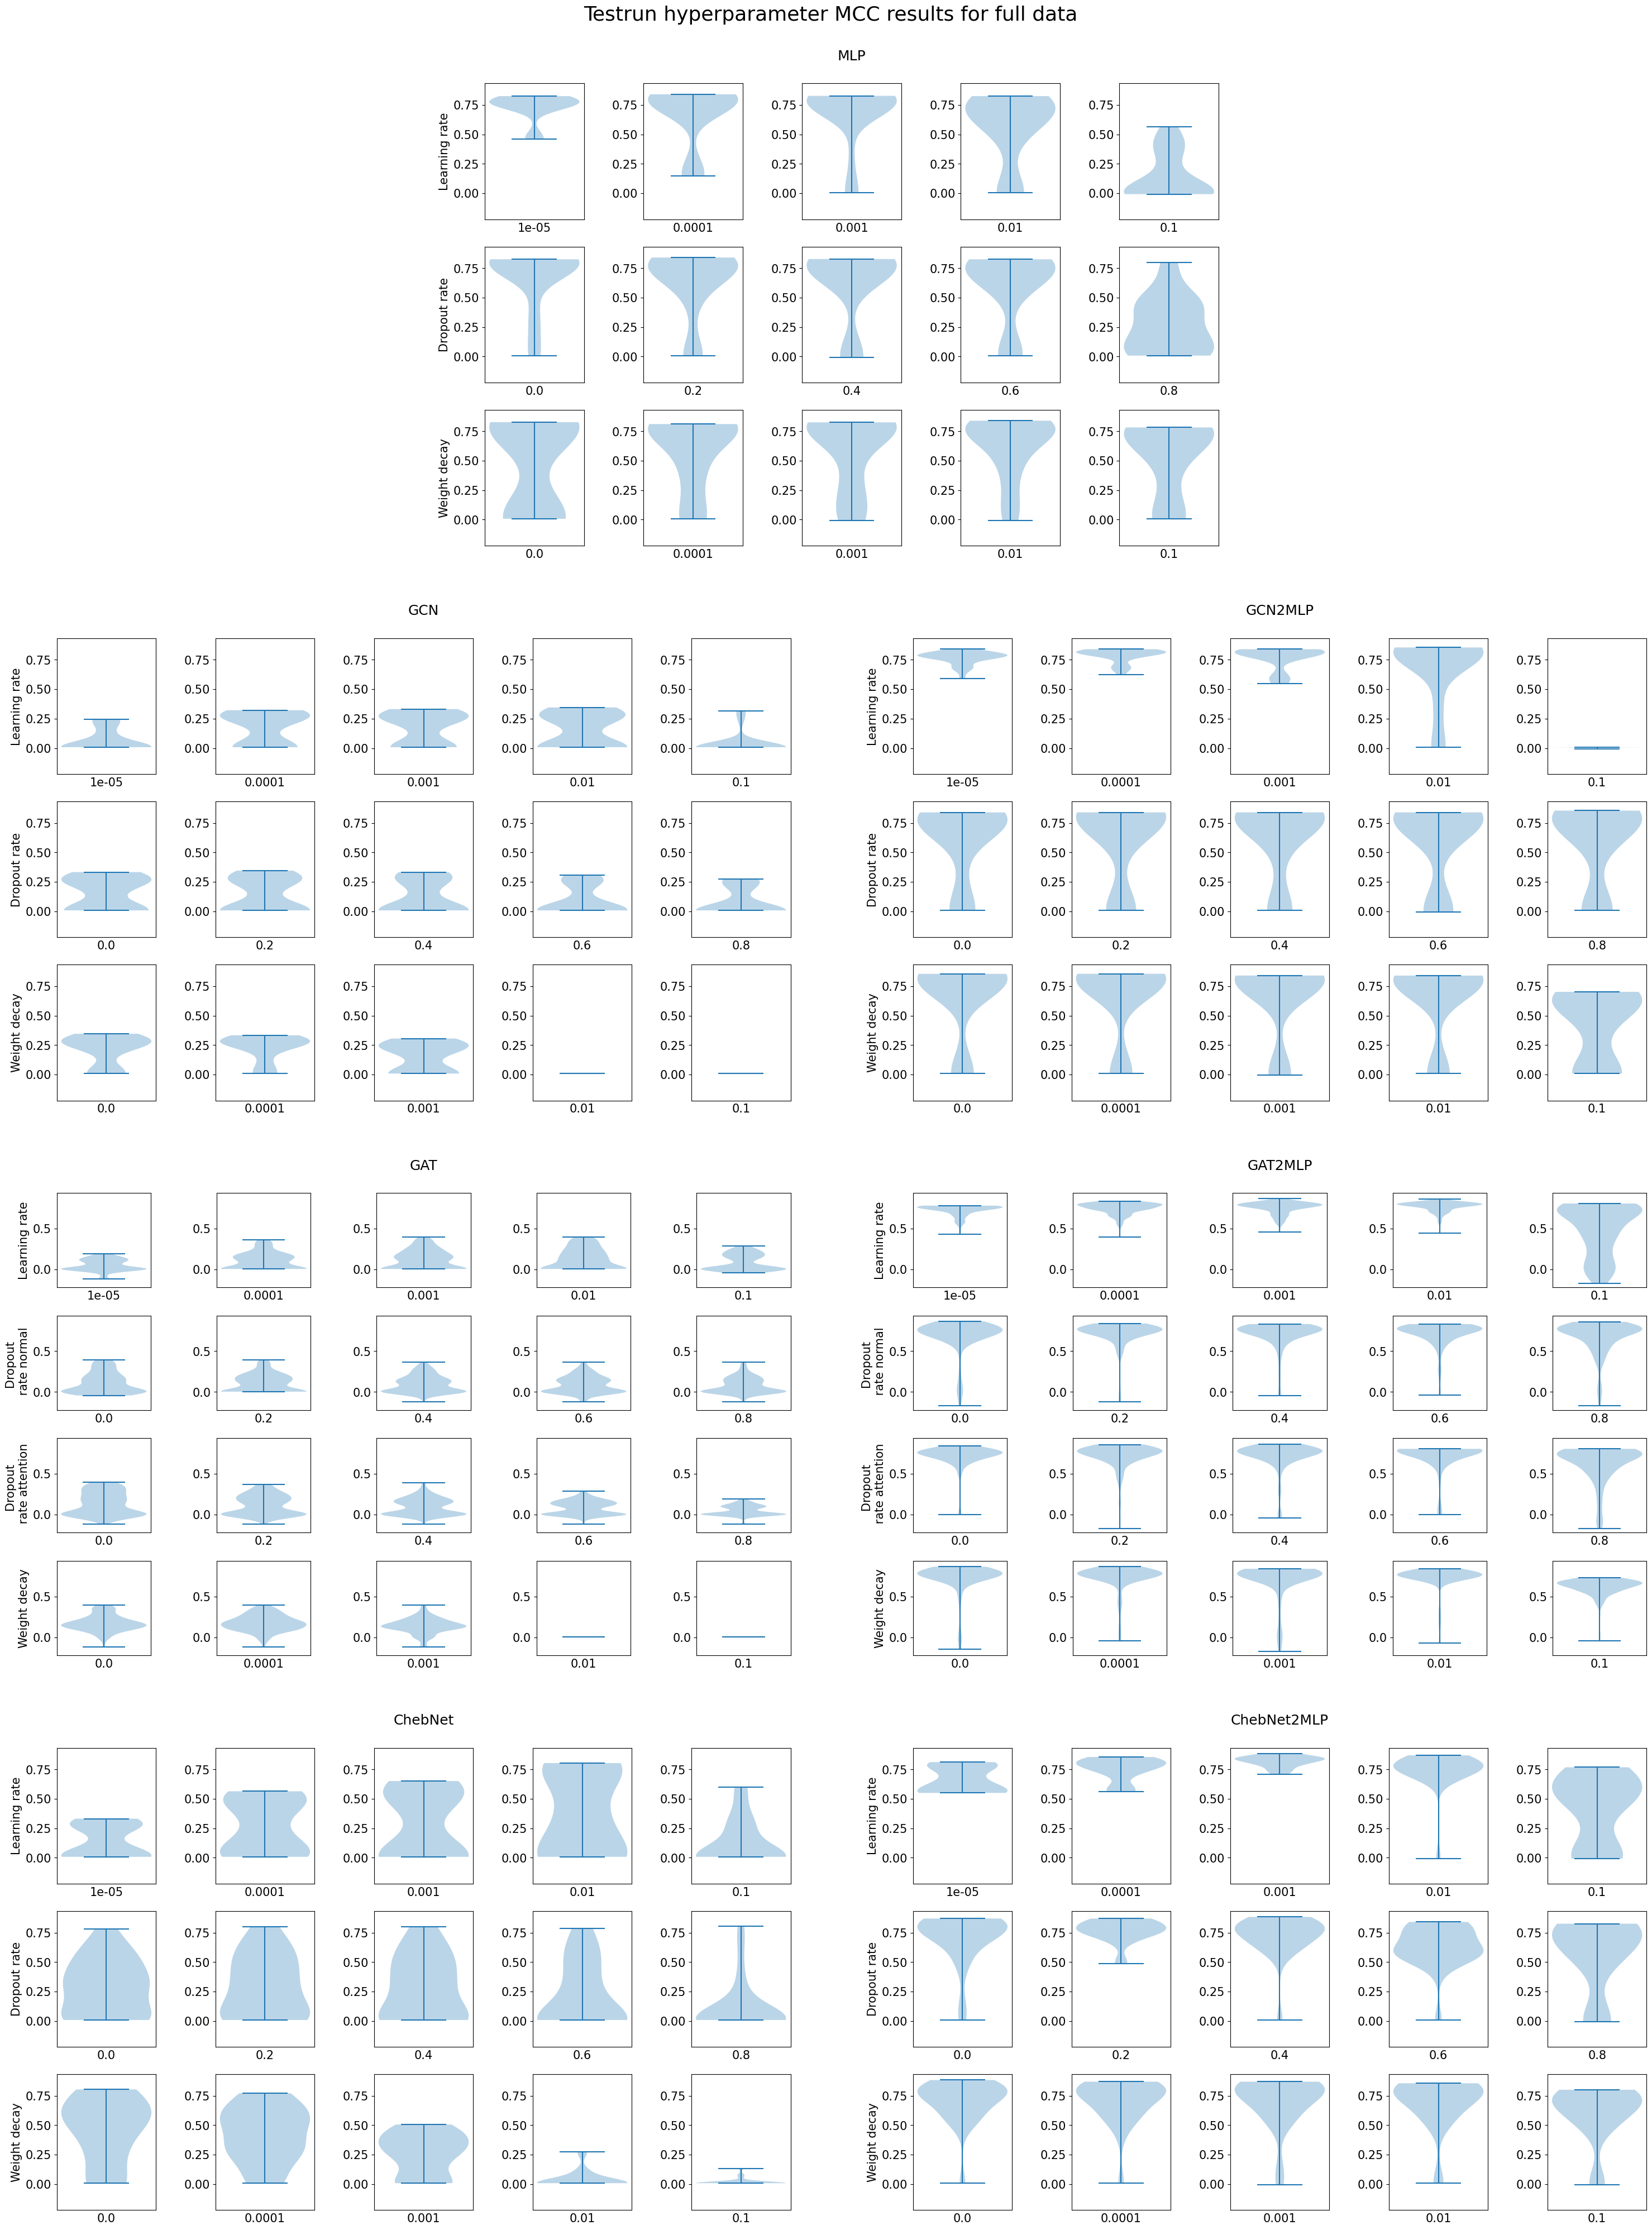

In [13]:
# BASIC MODELS, FULL DATA EXTENDED, 7 MODELS
mpl.rcParams.update({'font.size': 15})
title='Testrun hyperparameter MCC results'
fig = plt.figure(figsize=(30, 40))
fig.suptitle(title+' for full data', y=1, size=26)
min_val = min_mcc_full-0.05
max_val = max_mcc_full+0.05
fig.tight_layout(pad=40)

gs = gridspec.GridSpec(4,4)
ax1 = fig.add_subplot(gs[0,1:3])
ax2 = fig.add_subplot(gs[1,0:2])
ax3 = fig.add_subplot(gs[1,2:4])
ax4 = fig.add_subplot(gs[2,0:2])
ax5 = fig.add_subplot(gs[2,2:4])
ax6 = fig.add_subplot(gs[3,0:2])
ax7 = fig.add_subplot(gs[3,2:4])

violin_analysis_advanced(ax1,MLP_results, min_val, max_val)
ax1.set_title('MLP', pad=30)
violin_analysis_advanced(ax2,GCN_results, min_val, max_val)
ax2.set_title('GCN', pad=30)
violin_analysis_advanced(ax3,GCN2MLP_results, min_val, max_val)
ax3.set_title('GCN2MLP', pad=30)
violin_analysis_advanced_gat(ax4,GAT_results, min_val, max_val)
ax4.set_title('GAT', pad=30)
violin_analysis_advanced_gat(ax5,GAT2MLP_results, min_val, max_val)
ax5.set_title('GAT2MLP', pad=30)
violin_analysis_advanced(ax6,ChebNet_results, min_val, max_val)
ax6.set_title('ChebNet', pad=30)
violin_analysis_advanced(ax7,ChebNet2MLP_results, min_val, max_val)
ax7.set_title('ChebNet2MLP', pad=30)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.axes.get_xaxis().set_visible(False)
ax4.axes.get_yaxis().set_visible(False)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['bottom'].set_visible(False)
ax5.spines['left'].set_visible(False)
ax5.axes.get_xaxis().set_visible(False)
ax5.axes.get_yaxis().set_visible(False)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.spines['bottom'].set_visible(False)
ax6.spines['left'].set_visible(False)
ax6.axes.get_xaxis().set_visible(False)
ax6.axes.get_yaxis().set_visible(False)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)
ax7.spines['bottom'].set_visible(False)
ax7.spines['left'].set_visible(False)
ax7.axes.get_xaxis().set_visible(False)
ax7.axes.get_yaxis().set_visible(False)


gs.update(hspace=0.2, wspace=0.4)
plt.tight_layout()
'''
plt.savefig(path+'/pretests_violin_short_full_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin__short_full_extended.pdf', bbox_inches='tight')
'''
plt.show()

C:\Users\julia\AppData\Local\Temp\ipykernel_32188\3756681545.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


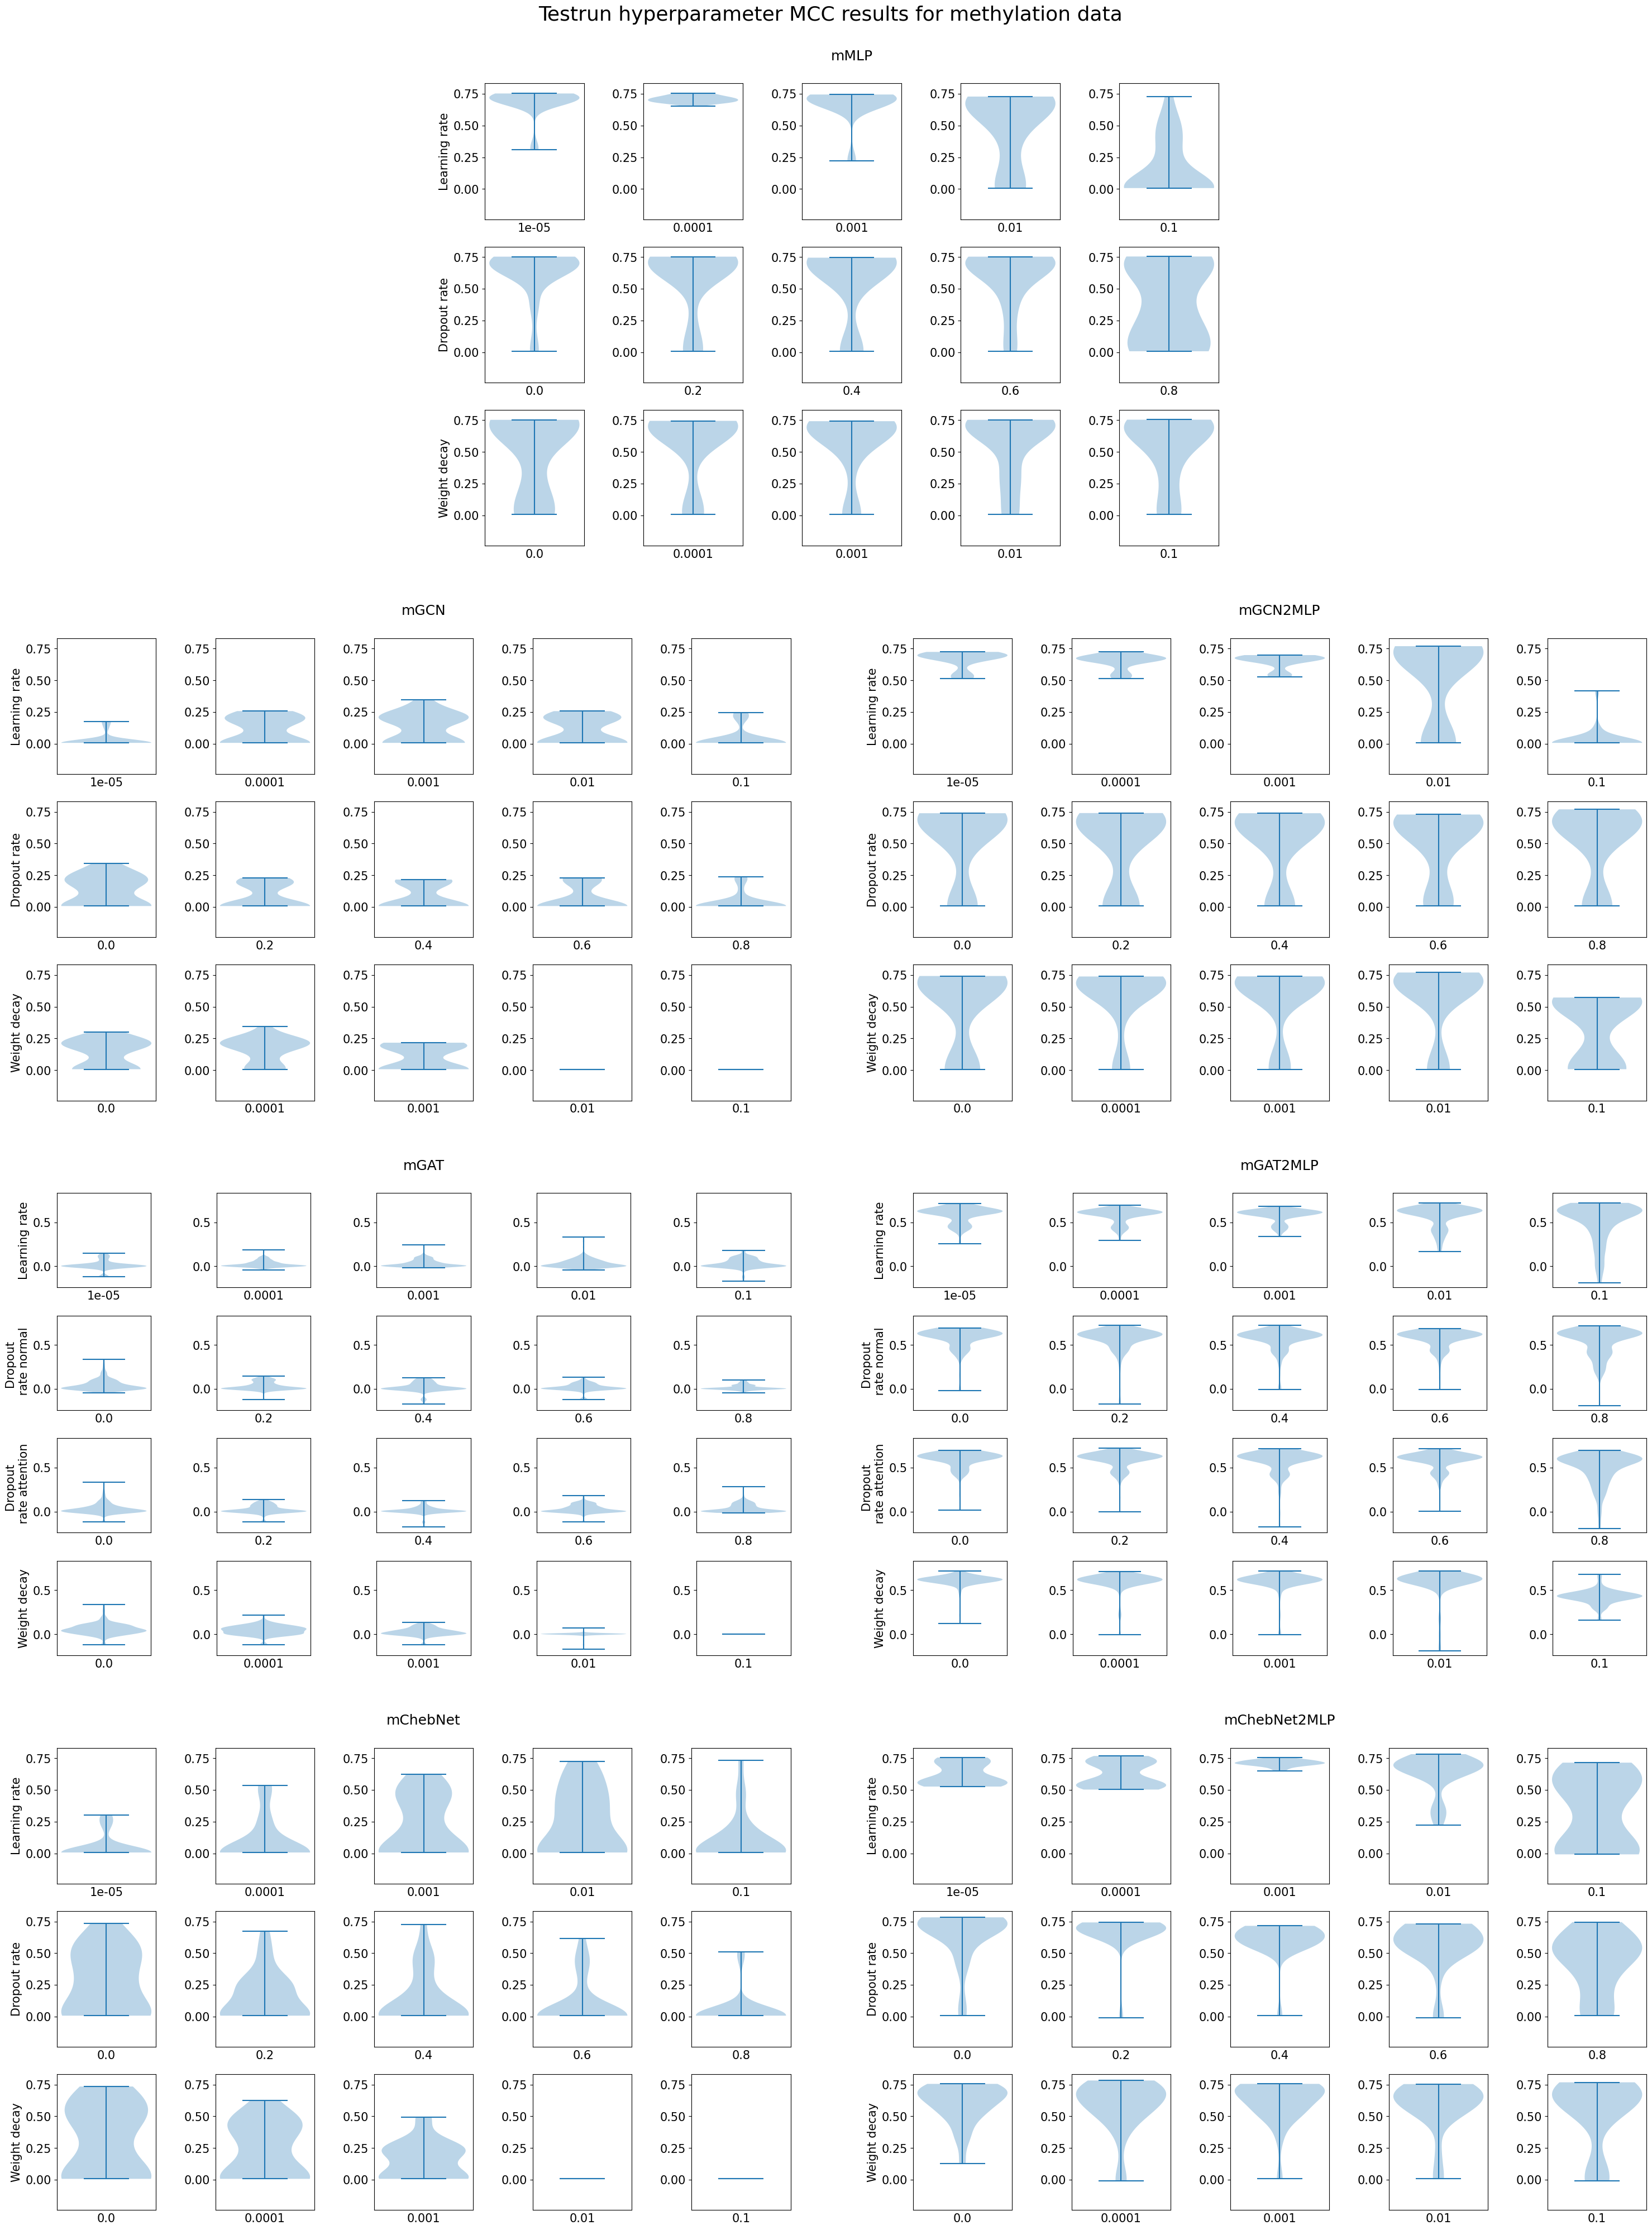

In [14]:
# BASIC MODELS, METHYLATION DATA EXTENDED, 7 MODELS
mpl.rcParams.update({'font.size': 15})
title='Testrun hyperparameter MCC results'
fig = plt.figure(figsize=(30, 40))
fig.suptitle(title+' for methylation data', y=1, size=26)
min_val = min_mcc_methyl-0.05
max_val = max_mcc_methyl+0.05
fig.tight_layout(pad=40)

gs = gridspec.GridSpec(4,4)
ax1 = fig.add_subplot(gs[0,1:3])
ax2 = fig.add_subplot(gs[1,0:2])
ax3 = fig.add_subplot(gs[1,2:4])
ax4 = fig.add_subplot(gs[2,0:2])
ax5 = fig.add_subplot(gs[2,2:4])
ax6 = fig.add_subplot(gs[3,0:2])
ax7 = fig.add_subplot(gs[3,2:4])

violin_analysis_advanced(ax1,mMLP_results, min_val, max_val)
ax1.set_title('mMLP', pad=30)
violin_analysis_advanced(ax2,mGCN_results, min_val, max_val)
ax2.set_title('mGCN', pad=30)
violin_analysis_advanced(ax3,mGCN2MLP_results, min_val, max_val)
ax3.set_title('mGCN2MLP', pad=30)
violin_analysis_advanced_gat(ax4,mGAT_results, min_val, max_val)
ax4.set_title('mGAT', pad=30)
violin_analysis_advanced_gat(ax5,mGAT2MLP_results, min_val, max_val)
ax5.set_title('mGAT2MLP', pad=30)
violin_analysis_advanced(ax6,mChebNet_results, min_val, max_val)
ax6.set_title('mChebNet', pad=30)
violin_analysis_advanced(ax7,mChebNet2MLP_results, min_val, max_val)
ax7.set_title('mChebNet2MLP', pad=30)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.axes.get_xaxis().set_visible(False)
ax4.axes.get_yaxis().set_visible(False)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['bottom'].set_visible(False)
ax5.spines['left'].set_visible(False)
ax5.axes.get_xaxis().set_visible(False)
ax5.axes.get_yaxis().set_visible(False)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.spines['bottom'].set_visible(False)
ax6.spines['left'].set_visible(False)
ax6.axes.get_xaxis().set_visible(False)
ax6.axes.get_yaxis().set_visible(False)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)
ax7.spines['bottom'].set_visible(False)
ax7.spines['left'].set_visible(False)
ax7.axes.get_xaxis().set_visible(False)
ax7.axes.get_yaxis().set_visible(False)


gs.update(hspace=0.2, wspace=0.4)
plt.tight_layout()
'''
plt.savefig(path+'/pretests_violin_short_methyl_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin__short_methyl_extended.pdf', bbox_inches='tight')
'''
plt.show()

C:\Users\julia\AppData\Local\Temp\ipykernel_32188\757758537.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


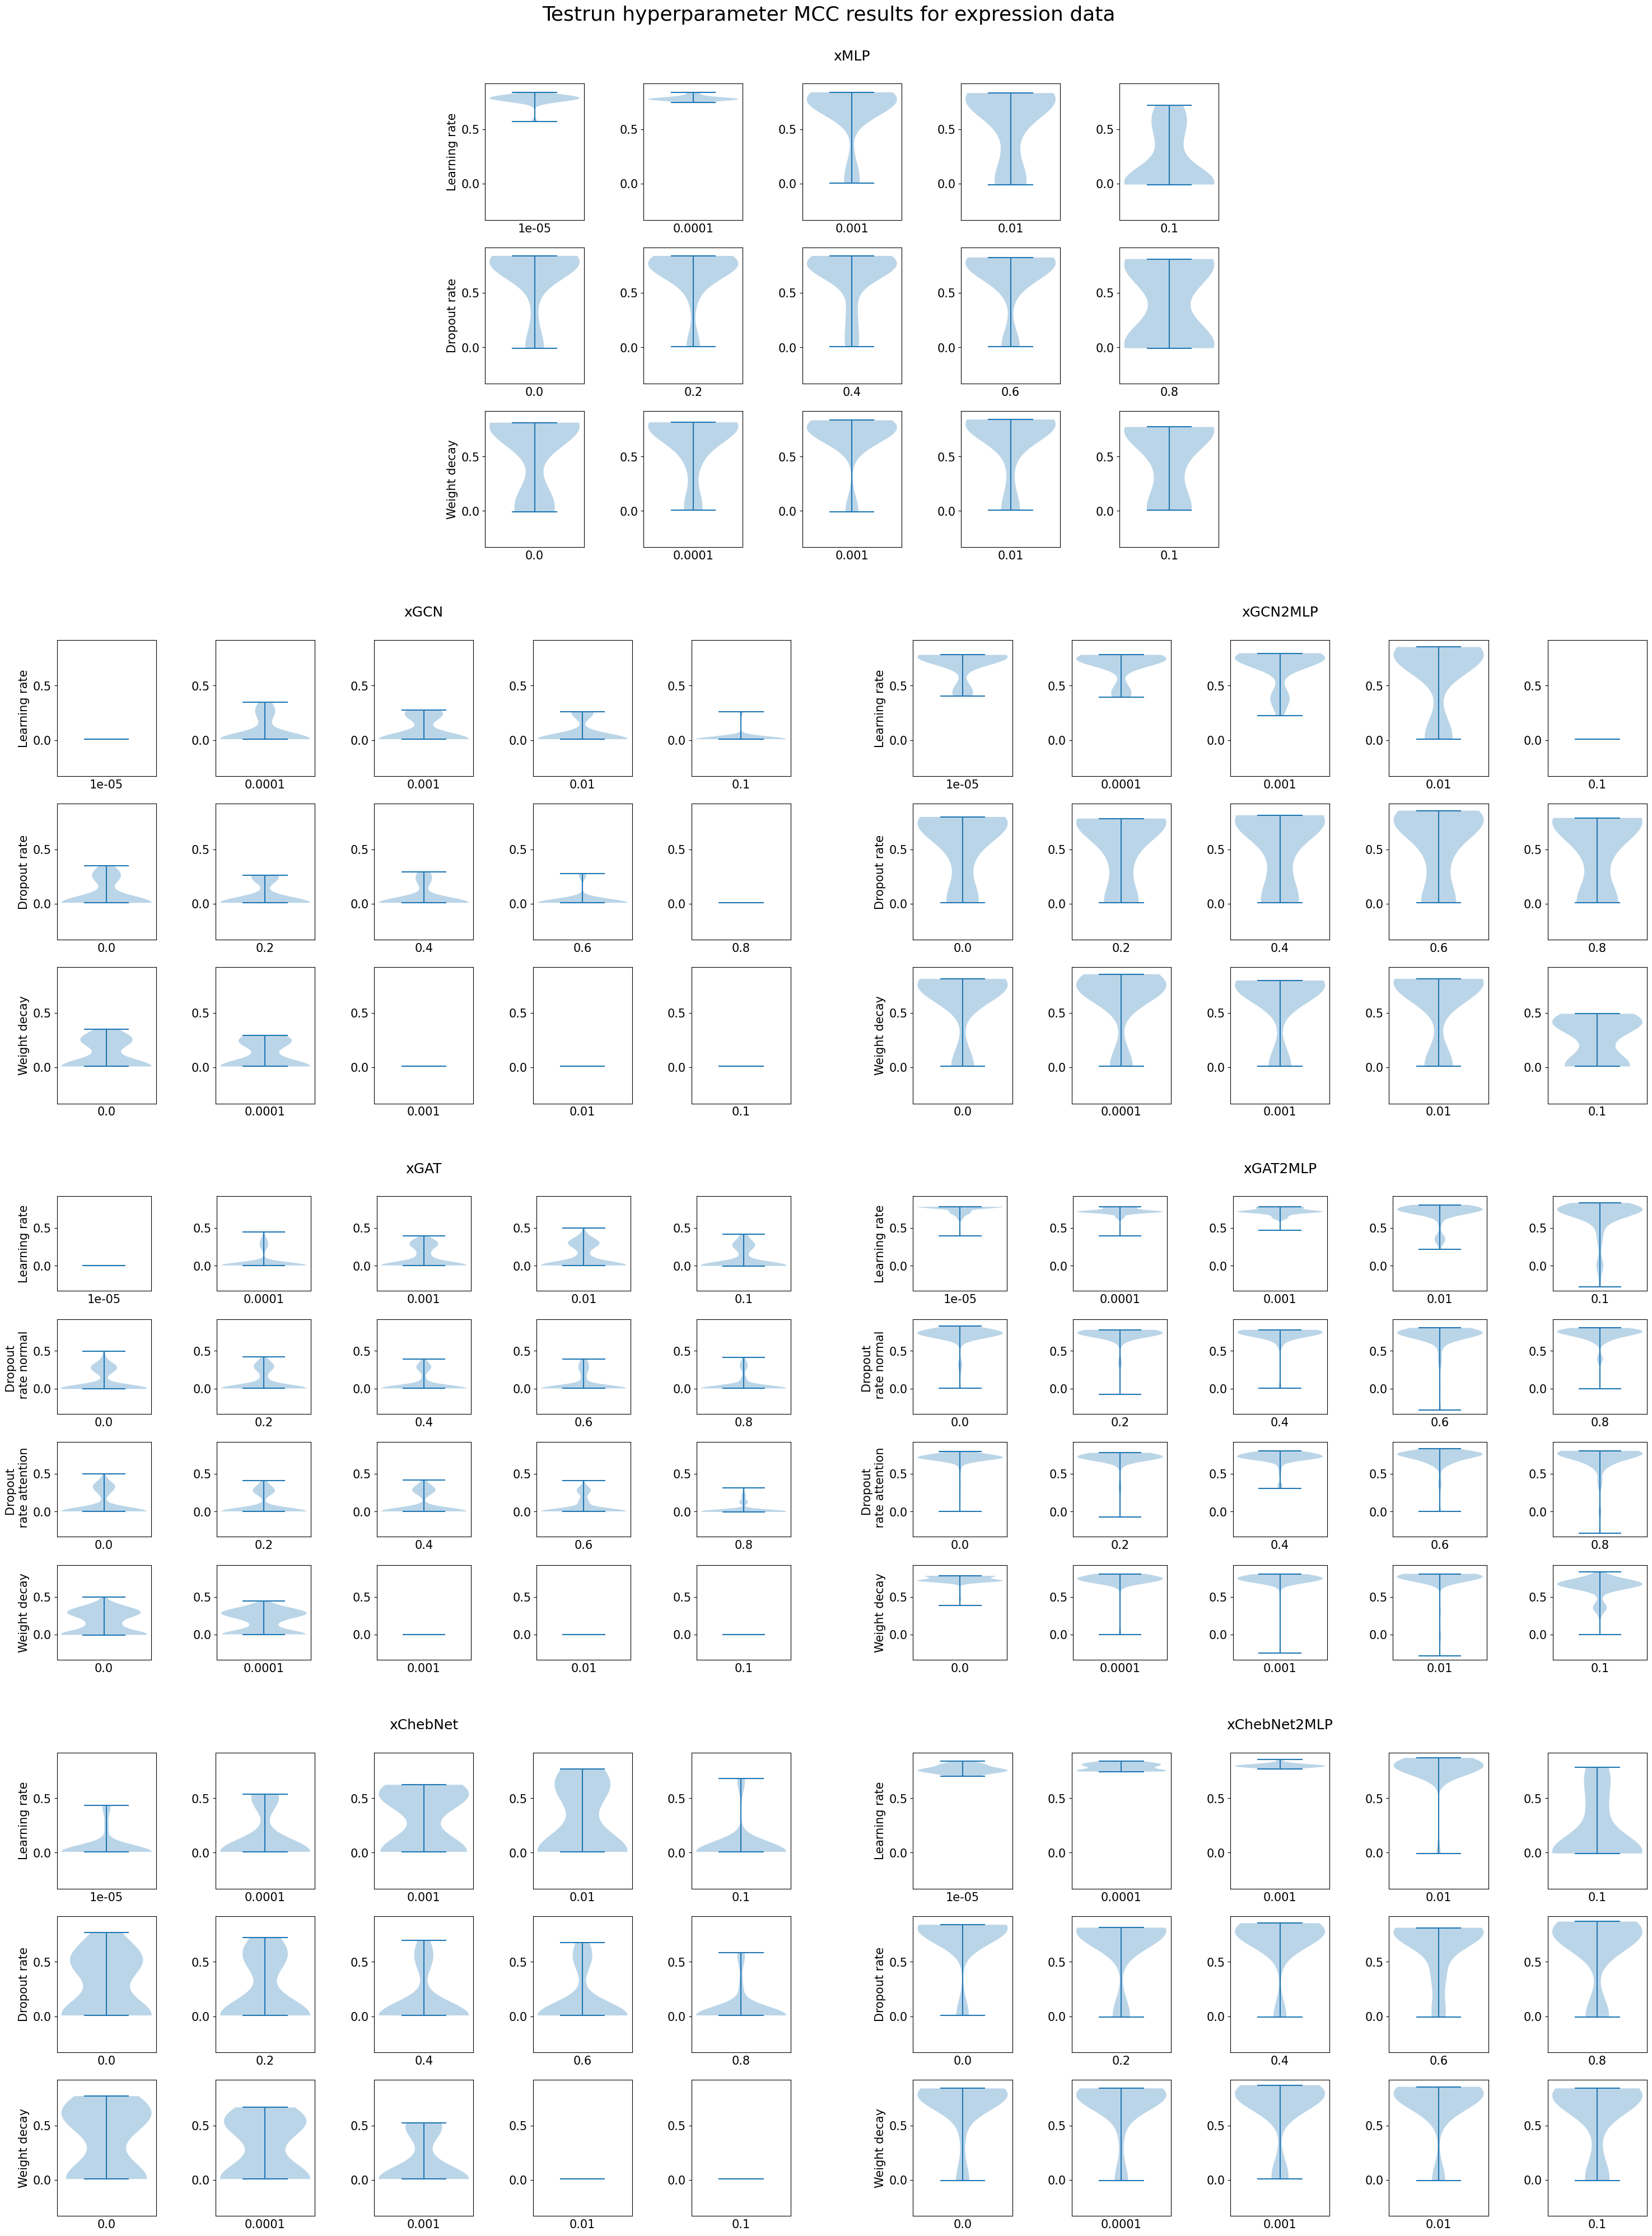

In [15]:
# BASIC MODELS, EXPRESSION DATA EXTENDED, 7 MODELS
mpl.rcParams.update({'font.size': 15})
title='Testrun hyperparameter MCC results'
fig = plt.figure(figsize=(30, 40))
fig.suptitle(title+' for expression data', y=1, size=26)
min_val = min_mcc_expr-0.05
max_val = max_mcc_expr+0.05
fig.tight_layout(pad=40)

gs = gridspec.GridSpec(4,4)
ax1 = fig.add_subplot(gs[0,1:3])
ax2 = fig.add_subplot(gs[1,0:2])
ax3 = fig.add_subplot(gs[1,2:4])
ax4 = fig.add_subplot(gs[2,0:2])
ax5 = fig.add_subplot(gs[2,2:4])
ax6 = fig.add_subplot(gs[3,0:2])
ax7 = fig.add_subplot(gs[3,2:4])

violin_analysis_advanced(ax1,xMLP_results, min_val, max_val)
ax1.set_title('xMLP', pad=30)
violin_analysis_advanced(ax2,xGCN_results, min_val, max_val)
ax2.set_title('xGCN', pad=30)
violin_analysis_advanced(ax3,xGCN2MLP_results, min_val, max_val)
ax3.set_title('xGCN2MLP', pad=30)
violin_analysis_advanced_gat(ax4,xGAT_results, min_val, max_val)
ax4.set_title('xGAT', pad=30)
violin_analysis_advanced_gat(ax5,xGAT2MLP_results, min_val, max_val)
ax5.set_title('xGAT2MLP', pad=30)
violin_analysis_advanced(ax6,xChebNet_results, min_val, max_val)
ax6.set_title('xChebNet', pad=30)
violin_analysis_advanced(ax7,xChebNet2MLP_results, min_val, max_val)
ax7.set_title('xChebNet2MLP', pad=30)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.axes.get_xaxis().set_visible(False)
ax4.axes.get_yaxis().set_visible(False)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['bottom'].set_visible(False)
ax5.spines['left'].set_visible(False)
ax5.axes.get_xaxis().set_visible(False)
ax5.axes.get_yaxis().set_visible(False)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.spines['bottom'].set_visible(False)
ax6.spines['left'].set_visible(False)
ax6.axes.get_xaxis().set_visible(False)
ax6.axes.get_yaxis().set_visible(False)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)
ax7.spines['bottom'].set_visible(False)
ax7.spines['left'].set_visible(False)
ax7.axes.get_xaxis().set_visible(False)
ax7.axes.get_yaxis().set_visible(False)


gs.update(hspace=0.2, wspace=0.4)
plt.tight_layout()
'''
plt.savefig(path+'/pretests_violin_short_expr_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin__short_expr_extended.pdf', bbox_inches='tight')
'''
plt.show()

In [16]:
#############################################################################
#############################################################################
#  SINGLE PLOT FOR ANALYSIS
#Set model
model_results = MLPLarger_results

mpl.rcParams.update({'font.size': 15})
title='Testrun hyperparameter MCC results, full data, MLP_Larger'
fig, ax = plt.subplots(figsize=(20, 15))
fig.suptitle(title, y=1, size=26)
max_val = model_results['val_mcc'].max()+0.05
min_val = model_results['val_mcc'].min()-0.05
fig.tight_layout(pad=40)

violin_analysis_advanced(ax, model_results, min_val, max_val)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

plt.tight_layout()

'''
plt.savefig(path+'/pretests_violin_MLPLarger.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_MLPLarger.pdf', bbox_inches='tight')
'''

plt.show()


NameError: name 'MLPLarger_results' is not defined

In [ ]:
# 4 PLOT FOR ANALYSIS (New Models 2 - Deep)

mpl.rcParams.update({'font.size': 15})
fig = plt.figure(figsize=(20, 15))
title='Testrun hyperparameter MCC results, full data, Deep Models'
fig.suptitle(title, y=1, size=26)
max_val = max([DeepGCN_results['val_mcc'].max(),
                DeepGAT_results['val_mcc'].max(),
                DeepGCN2MLP_results['val_mcc'].max(),
                DeepGAT2MLP_results['val_mcc'].max()]) + 0.05
min_val = min([DeepGCN_results['val_mcc'].min(),
               DeepGAT_results['val_mcc'].min(),
               DeepGCN2MLP_results['val_mcc'].min(),
               DeepGAT2MLP_results['val_mcc'].min()])-0.05

gs = gridspec.GridSpec(2,2)
ax1 = fig.add_subplot(gs[0,0:1])
ax2 = fig.add_subplot(gs[0,1:2])
ax3 = fig.add_subplot(gs[1,0:1])
ax4 = fig.add_subplot(gs[1,1:2])

violin_analysis_advanced(ax1,DeepGCN_results, min_val, max_val)
ax1.set_title('DeepGCN', pad=30)
violin_analysis_advanced(ax2,DeepGCN2MLP_results, min_val, max_val)
ax2.set_title('DeepGCN2MLP', pad=30)
violin_analysis_advanced_gat(ax3,DeepGAT_results, min_val, max_val)
ax3.set_title('DeepGAT', pad=30)
violin_analysis_advanced_gat(ax4,DeepGAT2MLP_results, min_val, max_val)
ax4.set_title('DeepGAT2MLP', pad=30)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.axes.get_xaxis().set_visible(False)
ax4.axes.get_yaxis().set_visible(False)

gs.update(hspace=0.2, wspace=0.4)
plt.tight_layout(pad=40)

'''
plt.savefig(path+'/pretests_violin_DeepModels.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_DeepModels.pdf', bbox_inches='tight')
'''
plt.show()


In [ ]:
# 4 PLOT FOR ANALYSIS (New Models 3 - Light)

mpl.rcParams.update({'font.size': 15})
fig = plt.figure(figsize=(20, 15))
title='Testrun hyperparameter MCC results, full data, Light Models'
fig.suptitle(title, y=1, size=26)
max_val = max([LightGCN_results['val_mcc'].max(),
                LightGAT_results['val_mcc'].max(),
                LightGCN2MLP_results['val_mcc'].max(),
                LightGAT2MLP_results['val_mcc'].max()]) + 0.05
min_val = min([LightGCN_results['val_mcc'].min(),
               LightGAT_results['val_mcc'].min(),
               LightGCN2MLP_results['val_mcc'].min(),
               LightGAT2MLP_results['val_mcc'].min()])-0.05

gs = gridspec.GridSpec(2,2)
ax1 = fig.add_subplot(gs[0,0:1])
ax2 = fig.add_subplot(gs[0,1:2])
ax3 = fig.add_subplot(gs[1,0:1])
ax4 = fig.add_subplot(gs[1,1:2])

violin_analysis_advanced(ax1,LightGCN_results, min_val, max_val)
ax1.set_title('LightGCN', pad=30)
violin_analysis_advanced(ax2,LightGCN2MLP_results, min_val, max_val)
ax2.set_title('LightGCN2MLP', pad=30)
violin_analysis_advanced_gat(ax3,LightGAT_results, min_val, max_val)
ax3.set_title('LightGAT', pad=30)
violin_analysis_advanced_gat(ax4,LightGAT2MLP_results, min_val, max_val)
ax4.set_title('LightGAT2MLP', pad=30)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.axes.get_xaxis().set_visible(False)
ax4.axes.get_yaxis().set_visible(False)

gs.update(hspace=0.2, wspace=0.4)
plt.tight_layout(pad=40)

'''
plt.savefig(path+'/pretests_violin_LightModels.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_LightModels.pdf', bbox_inches='tight')
'''
plt.show()


In [ ]:
# 4 PLOT FOR ANALYSIS (New Models 4 - LightDeep)

mpl.rcParams.update({'font.size': 15})
fig = plt.figure(figsize=(20, 15))
title='Testrun hyperparameter MCC results, full data, LightDeep Models'
fig.suptitle(title, y=1, size=26)
max_val = max([LightDeepGCN_results['val_mcc'].max(),
                LightDeepGAT_results['val_mcc'].max(),
                LightDeepGCN2MLP_results['val_mcc'].max(),
                LightDeepGAT2MLP_results['val_mcc'].max()]) + 0.05
min_val = min([LightDeepGCN_results['val_mcc'].min(),
               LightDeepGAT_results['val_mcc'].min(),
               LightDeepGCN2MLP_results['val_mcc'].min(),
               LightDeepGAT2MLP_results['val_mcc'].min()])-0.05

gs = gridspec.GridSpec(2,2)
ax1 = fig.add_subplot(gs[0,0:1])
ax2 = fig.add_subplot(gs[0,1:2])
ax3 = fig.add_subplot(gs[1,0:1])
ax4 = fig.add_subplot(gs[1,1:2])

violin_analysis_advanced(ax1,LightDeepGCN_results, min_val, max_val)
ax1.set_title('LightDeepGCN', pad=30)
violin_analysis_advanced(ax2,LightDeepGCN2MLP_results, min_val, max_val)
ax2.set_title('LightDeepGCN2MLP', pad=30)
violin_analysis_advanced_gat(ax3,LightDeepGAT_results, min_val, max_val)
ax3.set_title('LightDeepGAT', pad=30)
violin_analysis_advanced_gat(ax4,LightDeepGAT2MLP_results, min_val, max_val)
ax4.set_title('LightDeepGAT2MLP', pad=30)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.axes.get_xaxis().set_visible(False)
ax4.axes.get_yaxis().set_visible(False)

gs.update(hspace=0.2, wspace=0.4)
plt.tight_layout(pad=40)

'''
plt.savefig(path+'/pretests_violin_LightDeepModels.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_LightDeepModels.pdf', bbox_inches='tight')
'''

plt.show()


In [ ]:
# CHEBNET MODELS (all variants, all data)
title='Testrun hyperparameter MCC results'
fig, ax = plt.subplots(3,3, figsize=(30,20))#, layout='constrained')
fig.suptitle(title+' for ChebNet models', y=1)
min_val_cheb = min([ ChebNet_results['val_mcc'].min(),
                ResChebNet_results['val_mcc'].min(),
                DenseChebNet_results['val_mcc'].min(),
                mChebNet_results['val_mcc'].min(),
                mResChebNet_results['val_mcc'].min(),
                mDenseChebNet_results['val_mcc'].min(),
                xChebNet_results['val_mcc'].min(),
                xResChebNet_results['val_mcc'].min(),
                xDenseChebNet_results['val_mcc'].min(),
                ]) - 0.05
max_val_cheb = max([ ChebNet_results['val_mcc'].max(),
                ResChebNet_results['val_mcc'].max(),
                DenseChebNet_results['val_mcc'].max(),
                mChebNet_results['val_mcc'].max(),
                mResChebNet_results['val_mcc'].max(),
                mDenseChebNet_results['val_mcc'].max(),
                xChebNet_results['val_mcc'].max(),
                xResChebNet_results['val_mcc'].max(),
                xDenseChebNet_results['val_mcc'].max(),
                ]) + 0.05
fig.tight_layout(pad=40)


#ChebNet
violin_analysis_advanced(ax[0,0],ChebNet_results, min_val_cheb, max_val_cheb)
ax[0,0].set_title('ChebNet', pad=30)
violin_analysis_advanced(ax[0,1],ResChebNet_results, min_val_cheb, max_val_cheb)
ax[0,1].set_title('ResChebNet', pad=30)
violin_analysis_advanced(ax[0,2],DenseChebNet_results, min_val_cheb, max_val_cheb)
ax[0,2].set_title('DenseChebNet', pad=30)

#mChebNet
violin_analysis_advanced(ax[1,0],mChebNet_results, min_val_cheb, max_val_cheb)
ax[1,0].set_title('mChebNet', pad=30)
violin_analysis_advanced(ax[1,1],mResChebNet_results, min_val_cheb, max_val_cheb)
ax[1,1].set_title('mResChebNet', pad=30)
violin_analysis_advanced(ax[1,2],mDenseChebNet_results, min_val_cheb, max_val_cheb)
ax[1,2].set_title('mDenseChebNet', pad=30)

#xChebNet
violin_analysis_advanced(ax[2,0],xChebNet_results, min_val_cheb, max_val_cheb)
ax[2,0].set_title('xChebNet', pad=30)
violin_analysis_advanced(ax[2,1],xResChebNet_results, min_val_cheb, max_val_cheb)
ax[2,1].set_title('xResChebNet', pad=30)
violin_analysis_advanced(ax[2,2],xDenseChebNet_results, min_val_cheb, max_val_cheb)
ax[2,2].set_title('xDenseChebNet', pad=30)

for i in range(3):
    for j in range(3):
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)
        ax[i,j].spines['bottom'].set_visible(False)
        ax[i,j].spines['left'].set_visible(False)
        ax[i,j].axes.get_xaxis().set_visible(False)
        ax[i,j].axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)

'''
plt.savefig(path+'/pretests_violin_chebnet.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_chebnet.pdf', bbox_inches='tight')
'''

plt.show()

In [ ]:
# CHEBNET2MLP MODELS (all variants, all data)
title='Testrun hyperparameter MCC results'
fig, ax = plt.subplots(3,3, figsize=(30,20))#, layout='constrained')
fig.suptitle(title+' for ChebNet2MLP models', y=1)
min_val_cheb2mlp = min([ ChebNet2MLP_results['val_mcc'].min(),
                ResChebNet2MLP_results['val_mcc'].min(),
                DenseChebNet2MLP_results['val_mcc'].min(),
                mChebNet2MLP_results['val_mcc'].min(),
                mResChebNet2MLP_results['val_mcc'].min(),
                mDenseChebNet2MLP_results['val_mcc'].min(),
                xChebNet2MLP_results['val_mcc'].min(),
                xResChebNet2MLP_results['val_mcc'].min(),
                xDenseChebNet2MLP_results['val_mcc'].min(),
                ]) - 0.05
max_val_cheb2mlp = max([ ChebNet2MLP_results['val_mcc'].max(),
                ResChebNet2MLP_results['val_mcc'].max(),
                DenseChebNet2MLP_results['val_mcc'].max(),
                mChebNet2MLP_results['val_mcc'].max(),
                mResChebNet2MLP_results['val_mcc'].max(),
                mDenseChebNet2MLP_results['val_mcc'].max(),
                xChebNet2MLP_results['val_mcc'].max(),
                xResChebNet2MLP_results['val_mcc'].max(),
                xDenseChebNet2MLP_results['val_mcc'].max(),
                ]) + 0.05
fig.tight_layout(pad=40)


#ChebNet2MLP
violin_analysis_advanced(ax[0,0],ChebNet2MLP_results, min_val_cheb2mlp, max_val_cheb2mlp)
ax[0,0].set_title('ChebNet2MLP', pad=30)
violin_analysis_advanced(ax[0,1],ResChebNet2MLP_results, min_val_cheb2mlp, max_val_cheb2mlp)
ax[0,1].set_title('ResChebNet2MLP', pad=30)
violin_analysis_advanced(ax[0,2],DenseChebNet2MLP_results, min_val_cheb2mlp, max_val_cheb2mlp)
ax[0,2].set_title('DenseChebNet2MLP', pad=30)

#mChebNet2MLP
violin_analysis_advanced(ax[1,0],mChebNet2MLP_results, min_val_cheb2mlp, max_val_cheb2mlp)
ax[1,0].set_title('mChebNet2MLP', pad=30)
violin_analysis_advanced(ax[1,1],mResChebNet2MLP_results, min_val_cheb2mlp, max_val_cheb2mlp)
ax[1,1].set_title('mResChebNet2MLP', pad=30)
violin_analysis_advanced(ax[1,2],mDenseChebNet2MLP_results, min_val_cheb2mlp, max_val_cheb2mlp)
ax[1,2].set_title('mDenseChebNet2MLP', pad=30)

#xChebNet2MLP
violin_analysis_advanced(ax[2,0],xChebNet2MLP_results, min_val_cheb2mlp, max_val_cheb2mlp)
ax[2,0].set_title('xChebNet2MLP', pad=30)
violin_analysis_advanced(ax[2,1],xResChebNet2MLP_results, min_val_cheb2mlp, max_val_cheb2mlp)
ax[2,1].set_title('xResChebNet2MLP', pad=30)
violin_analysis_advanced(ax[2,2],xDenseChebNet2MLP_results, min_val_cheb2mlp, max_val_cheb2mlp)
ax[2,2].set_title('xDenseChebNet2MLP', pad=30)

for i in range(3):
    for j in range(3):
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)
        ax[i,j].spines['bottom'].set_visible(False)
        ax[i,j].spines['left'].set_visible(False)
        ax[i,j].axes.get_xaxis().set_visible(False)
        ax[i,j].axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)

'''
plt.savefig(path+'/pretests_violin_chebnet2mlp.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_chebnet2mlp.pdf', bbox_inches='tight')
'''

plt.show()

In [ ]:
# New Coarsening models

mpl.rcParams.update({'font.size': 15})
fig = plt.figure(figsize=(20, 20))
title='Testrun hyperparameter MCC results, full data, Coarsening Models'
fig.suptitle(title, y=1, size=26)
max_val_coarse = max([CoarseningGCN_results['val_mcc'].max(),
                #CoarseningGAT_results['val_mcc'].max(),
                CoarseningChebNet_results['val_mcc'].max(),
                CoarseningGCN2MLP_results['val_mcc'].max(),
                CoarseningGAT2MLP_results['val_mcc'].max(),
                CoarseningChebNet2MLP_results['val_mcc'].max()]) + 0.05
min_val_coarse = min([CoarseningGCN_results['val_mcc'].min(),
                #CoarseningGAT_results['val_mcc'].min(),
                CoarseningChebNet_results['val_mcc'].min(),
                CoarseningGCN2MLP_results['val_mcc'].min(),
                CoarseningGAT2MLP_results['val_mcc'].min(),
                CoarseningChebNet2MLP_results['val_mcc'].min()]) + 0.05

gs = gridspec.GridSpec(3,2)
ax1 = fig.add_subplot(gs[0,0:1])
ax2 = fig.add_subplot(gs[0,1:2])
ax3 = fig.add_subplot(gs[1,0:1])
ax4 = fig.add_subplot(gs[1,1:2])
ax5 = fig.add_subplot(gs[2,0:1])
ax6 = fig.add_subplot(gs[2,1:2])

violin_analysis_advanced(ax1,CoarseningGCN_results, min_val_coarse, max_val_coarse)
ax1.set_title('CoarseningGCN', pad=30)
violin_analysis_advanced_gat(ax2,CoarseningGAT_results, min_val_coarse, max_val_coarse)
ax2.set_title('CoarseningGAT', pad=30)
violin_analysis_advanced(ax3,CoarseningChebNet_results, min_val_coarse, max_val_coarse)
ax3.set_title('CoarseningChebNet', pad=30)
violin_analysis_advanced(ax4,CoarseningGCN2MLP_results, min_val_coarse, max_val_coarse)
ax4.set_title('CoarseningGCN2MLP', pad=30)
violin_analysis_advanced_gat(ax5,CoarseningGAT2MLP_results, min_val_coarse, max_val_coarse)
ax5.set_title('CoarseningGAT2MLP', pad=30)
violin_analysis_advanced(ax6,CoarseningChebNet2MLP_results, min_val_coarse, max_val_coarse)
ax6.set_title('CoarseningChebNet2MLP', pad=30)


ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.axes.get_xaxis().set_visible(False)
ax4.axes.get_yaxis().set_visible(False)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['bottom'].set_visible(False)
ax5.spines['left'].set_visible(False)
ax5.axes.get_xaxis().set_visible(False)
ax5.axes.get_yaxis().set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.spines['top'].set_visible(False)
ax6.spines['bottom'].set_visible(False)
ax6.spines['left'].set_visible(False)
ax6.axes.get_xaxis().set_visible(False)
ax6.axes.get_yaxis().set_visible(False)

gs.update(hspace=0.2, wspace=0.4)
plt.tight_layout(pad=40)

'''
plt.savefig(path+'/pretests_violin_CoarseningModels.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_CoarseningModels.pdf', bbox_inches='tight')
'''

plt.show()

In [ ]:
# New models (Light/Deep/LightDeep) + ChebNet(2MLP)

mpl.rcParams.update({'font.size': 15})
fig = plt.figure(figsize=(20, 20))
title='Testrun hyperparameter MCC results, full data, LightDeep ChebNet(2MLP) Models'
fig.suptitle(title, y=1, size=26)
max_val_new_cheb = max([LightChebNet_results['val_mcc'].max(),
                LightChebNet2MLP_results['val_mcc'].max(),
                DeepChebNet_results['val_mcc'].max(),
                DeepChebNet2MLP_results['val_mcc'].max(),
                LightDeepChebNet_results['val_mcc'].max(),
                LightDeepChebNet2MLP_results['val_mcc'].max()]) + 0.05
min_val_new_cheb = min([LightChebNet_results['val_mcc'].min(),
                LightChebNet2MLP_results['val_mcc'].min(),
                DeepChebNet_results['val_mcc'].min(),
                DeepChebNet2MLP_results['val_mcc'].min(),
                LightDeepChebNet_results['val_mcc'].min(),
                LightDeepChebNet2MLP_results['val_mcc'].min()]) + 0.05

gs = gridspec.GridSpec(3,2)
ax1 = fig.add_subplot(gs[0,0:1])
ax2 = fig.add_subplot(gs[0,1:2])
ax3 = fig.add_subplot(gs[1,0:1])
ax4 = fig.add_subplot(gs[1,1:2])
ax5 = fig.add_subplot(gs[2,0:1])
ax6 = fig.add_subplot(gs[2,1:2])

violin_analysis_advanced(ax1,LightChebNet_results, min_val_new_cheb, max_val_new_cheb)
ax1.set_title('LightChebNet', pad=30)
violin_analysis_advanced(ax2,LightChebNet2MLP_results, min_val_new_cheb, max_val_new_cheb)
ax2.set_title('LightChebNet2MLP', pad=30)
violin_analysis_advanced(ax3,DeepChebNet_results, min_val_new_cheb, max_val_new_cheb)
ax3.set_title('DeepChebNet', pad=30)
violin_analysis_advanced(ax4,DeepChebNet2MLP_results, min_val_new_cheb, max_val_new_cheb)
ax4.set_title('DeepChebNet2MLP', pad=30)
violin_analysis_advanced(ax5,LightDeepChebNet_results, min_val_new_cheb, max_val_new_cheb)
ax5.set_title('LightDeepChebNet', pad=30)
violin_analysis_advanced(ax6,LightDeepChebNet2MLP_results, min_val_new_cheb, max_val_new_cheb)
ax6.set_title('LightDeepChebNet2MLP', pad=30)


ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.axes.get_xaxis().set_visible(False)
ax4.axes.get_yaxis().set_visible(False)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['bottom'].set_visible(False)
ax5.spines['left'].set_visible(False)
ax5.axes.get_xaxis().set_visible(False)
ax5.axes.get_yaxis().set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.spines['top'].set_visible(False)
ax6.spines['bottom'].set_visible(False)
ax6.spines['left'].set_visible(False)
ax6.axes.get_xaxis().set_visible(False)
ax6.axes.get_yaxis().set_visible(False)

gs.update(hspace=0.2, wspace=0.4)
plt.tight_layout(pad=40)

'''
plt.savefig(path+'/pretests_violin_LightDeepChebModels.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_LightDeepChebModels.pdf', bbox_inches='tight')
'''

plt.show()

C:\Users\julia\AppData\Local\Temp\ipykernel_32188\880010307.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


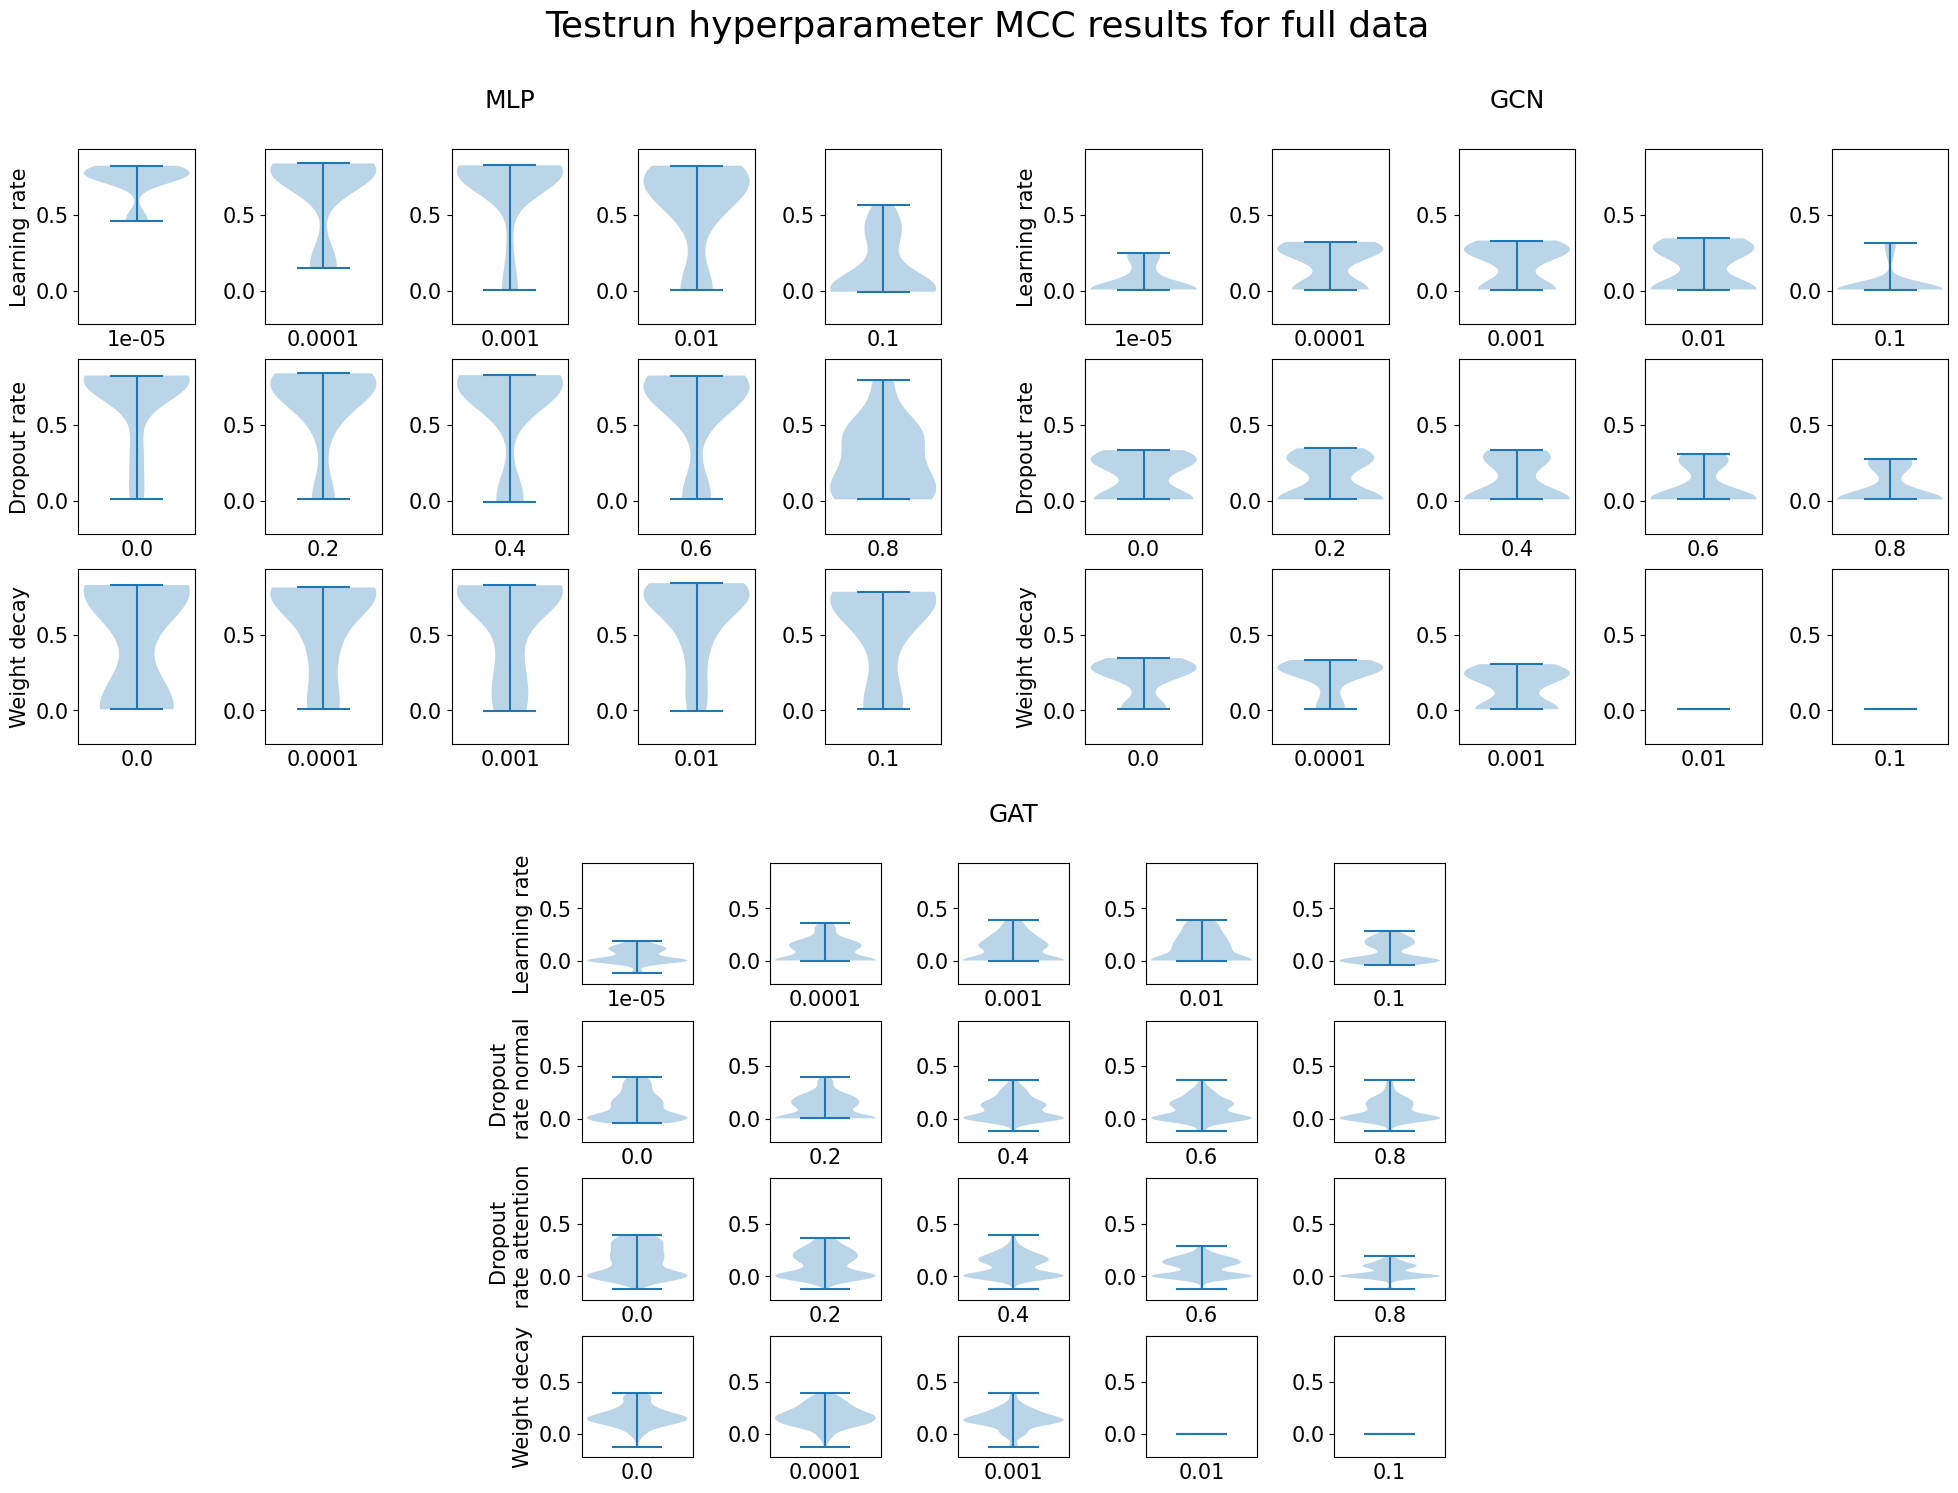

In [17]:
# FULL DATA, 3 MODELS
mpl.rcParams.update({'font.size': 15})
title='Testrun hyperparameter MCC results'
fig = plt.figure(figsize=(20, 15))
fig.suptitle(title+' for full data', y=1, size=26)
min_val = min_mcc_full-0.05
max_val = max_mcc_full+0.05
fig.tight_layout(pad=40)

gs = gridspec.GridSpec(2,4)
ax1 = fig.add_subplot(gs[0,0:2])
ax2 = fig.add_subplot(gs[0,2:4])
ax3 = fig.add_subplot(gs[1,1:3])

violin_analysis_advanced(ax1,MLP_results, min_val, max_val)
ax1.set_title('MLP', pad=30)
violin_analysis_advanced(ax2,GCN_results, min_val, max_val)
ax2.set_title('GCN', pad=30)
violin_analysis_advanced_gat(ax3,GAT_results, min_val, max_val)
ax3.set_title('GAT', pad=30)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)

gs.update(hspace=0.2, wspace=0.4)
plt.tight_layout()

'''
plt.savefig(path+'/pretests_violin_short_full.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin__short_full.pdf', bbox_inches='tight')
'''

plt.show()

C:\Users\julia\AppData\Local\Temp\ipykernel_32188\797515454.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


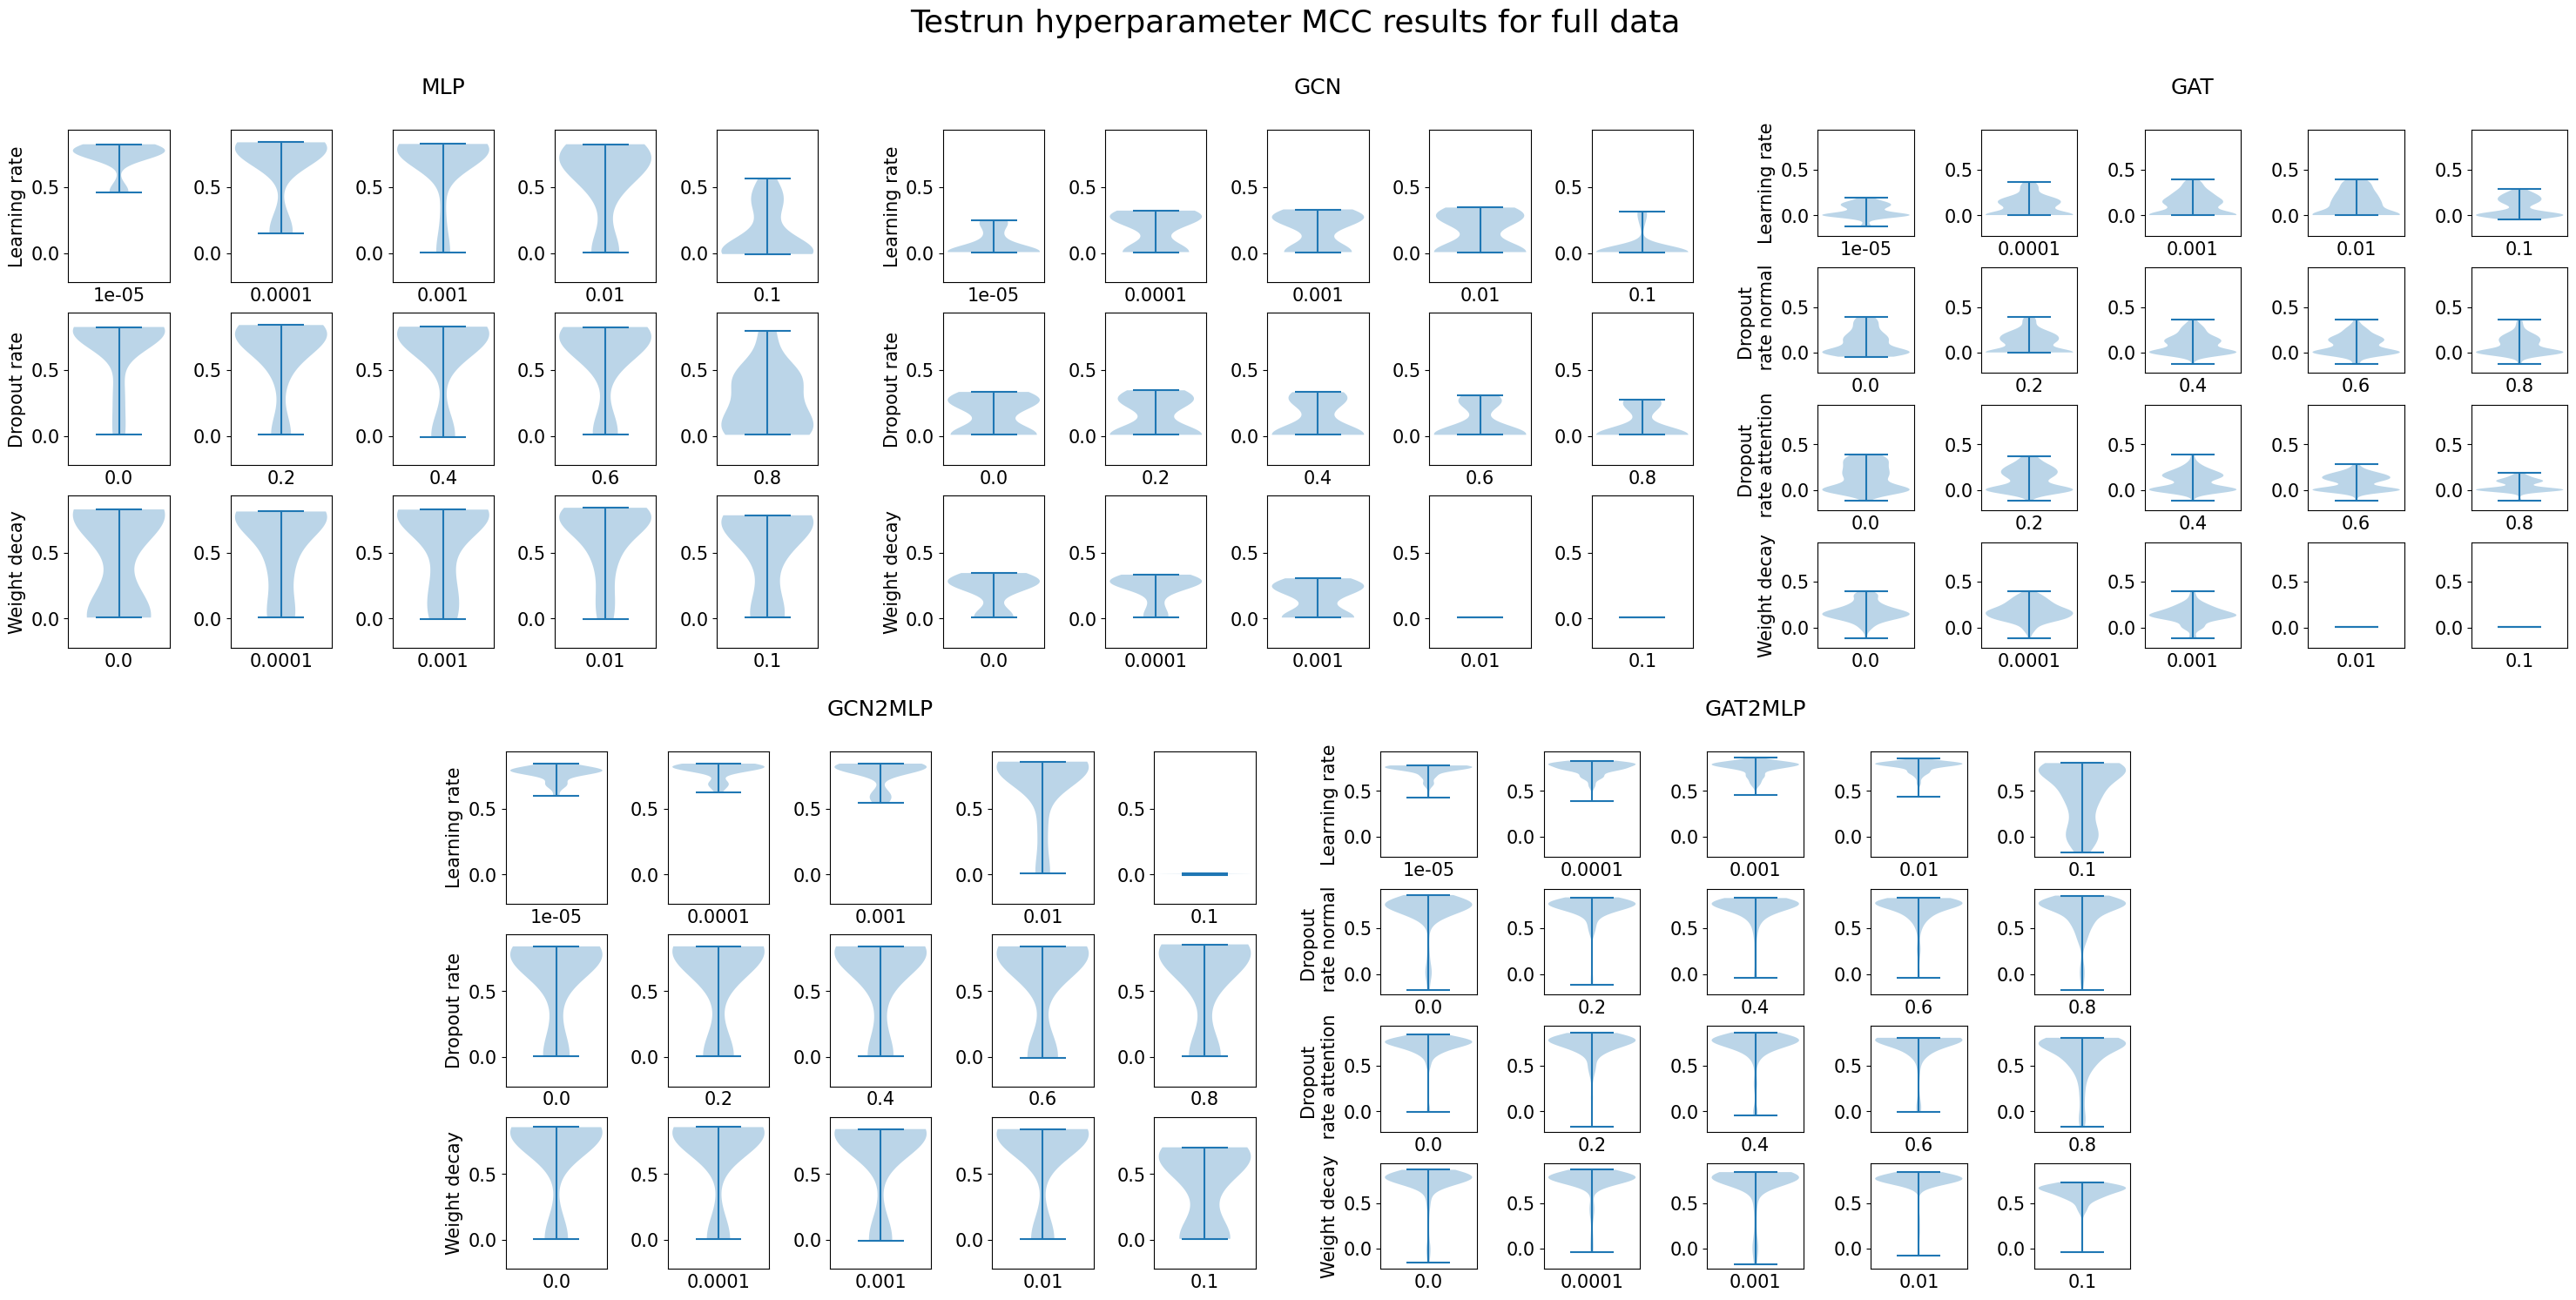

In [18]:
# FULL DATA EXTENDED, 5 MODELS
mpl.rcParams.update({'font.size': 15})
title='Testrun hyperparameter MCC results'
fig = plt.figure(figsize=(30, 15))
fig.suptitle(title+' for full data', y=1, size=26)
min_val = min_mcc_full-0.05
max_val = max_mcc_full+0.05
fig.tight_layout(pad=40)

gs = gridspec.GridSpec(2,6)
ax1 = fig.add_subplot(gs[0,0:2])
ax2 = fig.add_subplot(gs[0,2:4])
ax3 = fig.add_subplot(gs[0,4:6])
ax4 = fig.add_subplot(gs[1,1:3])
ax5 = fig.add_subplot(gs[1,3:5])

violin_analysis_advanced(ax1,MLP_results, min_val, max_val)
ax1.set_title('MLP', pad=30)
violin_analysis_advanced(ax2,GCN_results, min_val, max_val)
ax2.set_title('GCN', pad=30)
violin_analysis_advanced_gat(ax3,GAT_results, min_val, max_val)
ax3.set_title('GAT', pad=30)
violin_analysis_advanced(ax4,GCN2MLP_results, min_val, max_val)
ax4.set_title('GCN2MLP', pad=30)
violin_analysis_advanced_gat(ax5,GAT2MLP_results, min_val, max_val)
ax5.set_title('GAT2MLP', pad=30)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.axes.get_xaxis().set_visible(False)
ax4.axes.get_yaxis().set_visible(False)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['bottom'].set_visible(False)
ax5.spines['left'].set_visible(False)
ax5.axes.get_xaxis().set_visible(False)
ax5.axes.get_yaxis().set_visible(False)


gs.update(hspace=0.2, wspace=0.4)
plt.tight_layout()
'''
plt.savefig(path+'/pretests_violin_short_full_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin__short_full_extended.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
# FULL DATA
title='Testrun hyperparameter MCC results'
fig, ax = plt.subplots(3,3, figsize=(30,20))#, layout='constrained')
fig.suptitle(title+' for full data', y=1)
min_val = min_mcc_full-0.05
max_val = max_mcc_full+0.05
fig.tight_layout(pad=40)


#MLP
violin_analysis_advanced(ax[0,0],MLP_results, min_val, max_val)
ax[0,0].set_title('MLP', pad=30)
violin_analysis_advanced(ax[0,1],ResMLP_results, min_val, max_val)
ax[0,1].set_title('ResMLP', pad=30)
violin_analysis_advanced(ax[0,2],DenseMLP_results, min_val, max_val)
ax[0,2].set_title('DenseMLP', pad=30)

#GCN
violin_analysis_advanced(ax[1,0],GCN_results, min_val, max_val)
ax[1,0].set_title('GCN', pad=30)
violin_analysis_advanced(ax[1,1],ResGCN_results, min_val, max_val)
ax[1,1].set_title('ResGCN', pad=30)
violin_analysis_advanced(ax[1,2],DenseGCN_results, min_val, max_val)
ax[1,2].set_title('DenseGCN', pad=30)

#GAT
violin_analysis_advanced_gat(ax[2,0],GAT_results, min_val, max_val)
ax[2,0].set_title('GAT', pad=50)
violin_analysis_advanced_gat(ax[2,1],ResGAT_results, min_val, max_val)
ax[2,1].set_title('ResGAT', pad=50)
violin_analysis_advanced_gat(ax[2,2],DenseGAT_results, min_val, max_val)
ax[2,2].set_title('DenseGAT', pad=50)

for i in range(3):
    for j in range(3):
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)
        ax[i,j].spines['bottom'].set_visible(False)
        ax[i,j].spines['left'].set_visible(False)
        ax[i,j].axes.get_xaxis().set_visible(False)
        ax[i,j].axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)

'''
plt.savefig(path+'/pretests_violin_full.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_full.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
# FULL DATA EXTENDED (incl. GCN2MLP, GAT2MLP)
title='Testrun hyperparameter MCC results'
fig, ax = plt.subplots(5,3, figsize=(30,40))#, layout='constrained')
fig.suptitle(title+' for full data', y=1)
min_val = min_mcc_full-0.05
max_val = max_mcc_full+0.05
fig.tight_layout(pad=40)

#MLP
violin_analysis_advanced(ax[0,0],MLP_results, min_val, max_val)
ax[0,0].set_title('MLP', pad=30)
violin_analysis_advanced(ax[0,1],ResMLP_results, min_val, max_val)
ax[0,1].set_title('ResMLP', pad=30)
violin_analysis_advanced(ax[0,2],DenseMLP_results, min_val, max_val)
ax[0,2].set_title('DenseMLP', pad=30)

#GCN
violin_analysis_advanced(ax[1,0],GCN_results, min_val, max_val)
ax[1,0].set_title('GCN', pad=30)
violin_analysis_advanced(ax[1,1],ResGCN_results, min_val, max_val)
ax[1,1].set_title('ResGCN', pad=30)
violin_analysis_advanced(ax[1,2],DenseGCN_results, min_val, max_val)
ax[1,2].set_title('DenseGCN', pad=30)

#GAT
violin_analysis_advanced_gat(ax[2,0],GAT_results, min_val, max_val)
ax[2,0].set_title('GAT', pad=50)
violin_analysis_advanced_gat(ax[2,1],ResGAT_results, min_val, max_val)
ax[2,1].set_title('ResGAT', pad=50)
violin_analysis_advanced_gat(ax[2,2],DenseGAT_results, min_val, max_val)
ax[2,2].set_title('DenseGAT', pad=50)

#GCN2MLP
violin_analysis_advanced(ax[3,0],GCN2MLP_results, min_val, max_val)
ax[3,0].set_title('GCN2MLP', pad=30)
violin_analysis_advanced(ax[3,1],ResGCN2MLP_results, min_val, max_val)
ax[3,1].set_title('ResGCN2MLP', pad=30)
violin_analysis_advanced(ax[3,2],DenseGCN2MLP_results, min_val, max_val)
ax[3,2].set_title('DenseGCN2MLP', pad=30)

#GAT2MLP
violin_analysis_advanced_gat(ax[4,0],GAT2MLP_results, min_val, max_val)
ax[4,0].set_title('GAT2MLP', pad=50)
violin_analysis_advanced_gat(ax[4,1],ResGAT2MLP_results, min_val, max_val)
ax[4,1].set_title('ResGAT2MLP', pad=50)
violin_analysis_advanced_gat(ax[4,2],DenseGAT2MLP_results, min_val, max_val)
ax[4,2].set_title('DenseGAT2MLP', pad=50)

for i in range(5):
    for j in range(3):
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)
        ax[i,j].spines['bottom'].set_visible(False)
        ax[i,j].spines['left'].set_visible(False)
        ax[i,j].axes.get_xaxis().set_visible(False)
        ax[i,j].axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)
'''
plt.savefig(path+'/pretests_violin_full_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_full_extended.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
# METHYLATION DATA
title='Testrun hyperparameter MCC results'
fig, ax = plt.subplots(3,3, figsize=(30,20))#, layout='constrained')
fig.suptitle(title+' for methylation data', y=1)
min_val = min_mcc_methyl-0.05
max_val = max_mcc_methyl+0.05
fig.tight_layout(pad=40)


#MLP
violin_analysis_advanced(ax[0,0],mMLP_results, min_val, max_val)
ax[0,0].set_title('mMLP', pad=30)
violin_analysis_advanced(ax[0,1],mResMLP_results, min_val, max_val)
ax[0,1].set_title('mResMLP', pad=30)
violin_analysis_advanced(ax[0,2],mDenseMLP_results, min_val, max_val)
ax[0,2].set_title('mDenseMLP', pad=30)

#GCN
violin_analysis_advanced(ax[1,0],mGCN_results, min_val, max_val)
ax[1,0].set_title('mGCN', pad=30)
violin_analysis_advanced(ax[1,1],mResGCN_results, min_val, max_val)
ax[1,1].set_title('mResGCN', pad=30)
violin_analysis_advanced(ax[1,2],mDenseGCN_results, min_val, max_val)
ax[1,2].set_title('mDenseGCN', pad=30)

#GAT
violin_analysis_advanced_gat(ax[2,0],mGAT_results, min_val, max_val)
ax[2,0].set_title('mGAT', pad=50)
violin_analysis_advanced_gat(ax[2,1],mResGAT_results, min_val, max_val)
ax[2,1].set_title('mResGAT', pad=50)
violin_analysis_advanced_gat(ax[2,2],mDenseGAT_results, min_val, max_val)
ax[2,2].set_title('mDenseGAT', pad=50)

for i in range(3):
    for j in range(3):
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)
        ax[i,j].spines['bottom'].set_visible(False)
        ax[i,j].spines['left'].set_visible(False)
        ax[i,j].axes.get_xaxis().set_visible(False)
        ax[i,j].axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)

'''
plt.savefig(path+'/pretests_violin_methyl.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_methyl.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
# METHYLATION DATA EXTENDED
title='Testrun hyperparameter MCC results'
fig, ax = plt.subplots(5,3, figsize=(30,40))#, layout='constrained')
fig.suptitle(title+' for methylation data', y=1)
min_val = min_mcc_methyl-0.05
max_val = max_mcc_methyl+0.05
fig.tight_layout(pad=40)


#MLP
violin_analysis_advanced(ax[0,0],mMLP_results, min_val, max_val)
ax[0,0].set_title('mMLP', pad=30)
violin_analysis_advanced(ax[0,1],mResMLP_results, min_val, max_val)
ax[0,1].set_title('mResMLP', pad=30)
violin_analysis_advanced(ax[0,2],mDenseMLP_results, min_val, max_val)
ax[0,2].set_title('mDenseMLP', pad=30)

#GCN
violin_analysis_advanced(ax[1,0],mGCN_results, min_val, max_val)
ax[1,0].set_title('mGCN', pad=30)
violin_analysis_advanced(ax[1,1],mResGCN_results, min_val, max_val)
ax[1,1].set_title('mResGCN', pad=30)
violin_analysis_advanced(ax[1,2],mDenseGCN_results, min_val, max_val)
ax[1,2].set_title('mDenseGCN', pad=30)

#GAT
violin_analysis_advanced_gat(ax[2,0],mGAT_results, min_val, max_val)
ax[2,0].set_title('mGAT', pad=50)
violin_analysis_advanced_gat(ax[2,1],mResGAT_results, min_val, max_val)
ax[2,1].set_title('mResGAT', pad=50)
violin_analysis_advanced_gat(ax[2,2],mDenseGAT_results, min_val, max_val)
ax[2,2].set_title('mDenseGAT', pad=50)

#GCN2MLP
violin_analysis_advanced(ax[3,0],mGCN2MLP_results, min_val, max_val)
ax[3,0].set_title('mGCN2MLP', pad=30)
violin_analysis_advanced(ax[3,1],mResGCN2MLP_results, min_val, max_val)
ax[3,1].set_title('mResGCN2MLP', pad=30)
violin_analysis_advanced(ax[3,2],mDenseGCN2MLP_results, min_val, max_val)
ax[3,2].set_title('mDenseGCN2MLP', pad=30)

#GAT2MLP
violin_analysis_advanced_gat(ax[4,0],mGAT2MLP_results, min_val, max_val)
ax[4,0].set_title('mGAT2MLP', pad=50)
violin_analysis_advanced_gat(ax[4,1],mResGAT2MLP_results, min_val, max_val)
ax[4,1].set_title('mResGAT2MLP', pad=50)
violin_analysis_advanced_gat(ax[4,2],mDenseGAT2MLP_results, min_val, max_val)
ax[4,2].set_title('mDenseGAT2MLP', pad=50)

for i in range(5):
    for j in range(3):
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)
        ax[i,j].spines['bottom'].set_visible(False)
        ax[i,j].spines['left'].set_visible(False)
        ax[i,j].axes.get_xaxis().set_visible(False)
        ax[i,j].axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)
'''
plt.savefig(path+'/pretests_violin_methyl_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_methyl_extended.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
# EXPRESSION DATA
title='Testrun hyperparameter MCC results'
fig, ax = plt.subplots(3,3, figsize=(30,20))#, layout='constrained')
fig.suptitle(title+' for expression data', y=1)
min_val = min_mcc_expr-0.05
max_val = max_mcc_expr+0.05
fig.tight_layout(pad=40)


#MLP
violin_analysis_advanced(ax[0,0],xMLP_results, min_val, max_val)
ax[0,0].set_title('xMLP', pad=30)
violin_analysis_advanced(ax[0,1],xResMLP_results, min_val, max_val)
ax[0,1].set_title('xResMLP', pad=30)
violin_analysis_advanced(ax[0,2],xDenseMLP_results, min_val, max_val)
ax[0,2].set_title('xDenseMLP', pad=30)

#GCN
violin_analysis_advanced(ax[1,0],xGCN_results, min_val, max_val)
ax[1,0].set_title('xGCN', pad=30)
violin_analysis_advanced(ax[1,1],xResGCN_results, min_val, max_val)
ax[1,1].set_title('xResGCN', pad=30)
violin_analysis_advanced(ax[1,2],xDenseGCN_results, min_val, max_val)
ax[1,2].set_title('xDenseGCN', pad=30)

#GAT
violin_analysis_advanced_gat(ax[2,0],xGAT_results, min_val, max_val)
ax[2,0].set_title('xGAT', pad=50)
violin_analysis_advanced_gat(ax[2,1],xResGAT_results, min_val, max_val)
ax[2,1].set_title('xResGAT', pad=50)
violin_analysis_advanced_gat(ax[2,2],xDenseGAT_results, min_val, max_val)
ax[2,2].set_title('xDenseGAT', pad=50)

for i in range(3):
    for j in range(3):
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)
        ax[i,j].spines['bottom'].set_visible(False)
        ax[i,j].spines['left'].set_visible(False)
        ax[i,j].axes.get_xaxis().set_visible(False)
        ax[i,j].axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)

'''
plt.savefig(path+'/pretests_violin_expr.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_expr.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
# EXPRESSION DATA EXTENDED
title='Testrun hyperparameter MCC results'
fig, ax = plt.subplots(5,3, figsize=(30,40))#, layout='constrained')
fig.suptitle(title+' for expression data', y=1)
min_val = min_mcc_expr-0.05
max_val = max_mcc_expr+0.05
fig.tight_layout(pad=40)


#MLP
violin_analysis_advanced(ax[0,0],xMLP_results, min_val, max_val)
ax[0,0].set_title('xMLP', pad=30)
violin_analysis_advanced(ax[0,1],xResMLP_results, min_val, max_val)
ax[0,1].set_title('xResMLP', pad=30)
violin_analysis_advanced(ax[0,2],xDenseMLP_results, min_val, max_val)
ax[0,2].set_title('xDenseMLP', pad=30)

#GCN
violin_analysis_advanced(ax[1,0],xGCN_results, min_val, max_val)
ax[1,0].set_title('xGCN', pad=30)
violin_analysis_advanced(ax[1,1],xResGCN_results, min_val, max_val)
ax[1,1].set_title('xResGCN', pad=30)
violin_analysis_advanced(ax[1,2],xDenseGCN_results, min_val, max_val)
ax[1,2].set_title('xDenseGCN', pad=30)

#GAT
violin_analysis_advanced_gat(ax[2,0],xGAT_results, min_val, max_val)
ax[2,0].set_title('xGAT', pad=50)
violin_analysis_advanced_gat(ax[2,1],xResGAT_results, min_val, max_val)
ax[2,1].set_title('xResGAT', pad=50)
violin_analysis_advanced_gat(ax[2,2],xDenseGAT_results, min_val, max_val)
ax[2,2].set_title('xDenseGAT', pad=50)

#GCN2MLP
violin_analysis_advanced(ax[3,0],xGCN2MLP_results, min_val, max_val)
ax[3,0].set_title('xGCN2MLP', pad=30)
violin_analysis_advanced(ax[3,1],xResGCN2MLP_results, min_val, max_val)
ax[3,1].set_title('xResGCN2MLP', pad=30)
violin_analysis_advanced(ax[3,2],xDenseGCN2MLP_results, min_val, max_val)
ax[3,2].set_title('xDenseGCN2MLP', pad=30)

#GAT2MLP
violin_analysis_advanced_gat(ax[4,0],xGAT2MLP_results, min_val, max_val)
ax[4,0].set_title('xGAT2MLP', pad=50)
violin_analysis_advanced_gat(ax[4,1],xResGAT2MLP_results, min_val, max_val)
ax[4,1].set_title('xResGAT2MLP', pad=50)
violin_analysis_advanced_gat(ax[4,2],xDenseGAT2MLP_results, min_val, max_val)
ax[4,2].set_title('xDenseGAT2MLP', pad=50)

for i in range(5):
    for j in range(3):
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)
        ax[i,j].spines['bottom'].set_visible(False)
        ax[i,j].spines['left'].set_visible(False)
        ax[i,j].axes.get_xaxis().set_visible(False)
        ax[i,j].axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)
'''
plt.savefig(path+'/pretests_violin_expr_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_expr_extended.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
### VIOLINPLOTS FOR NEW MODEL GCN2MLP

# FULL DATA
title='Testrun hyperparameter MCC results'
fig, ax = plt.subplots(3,3, figsize=(30,24)) #, layout='constrained')
fig.suptitle(title+' for full data', y=1)
min_val = min_mcc_full-0.05
max_val = max_mcc_full+0.05
fig.tight_layout(pad=40)

#GCN2MLP
violin_analysis_advanced(ax[0,0],GCN2MLP_results, min_val, max_val)
ax[0,0].set_title('GCN2MLP', pad=30)
violin_analysis_advanced(ax[0,1],ResGCN2MLP_results, min_val, max_val)
ax[0,1].set_title('ResGCN2MLP', pad=30)
violin_analysis_advanced(ax[0,2],DenseGCN2MLP_results, min_val, max_val)
ax[0,2].set_title('DenseGCN2MLP', pad=30)

#mGCN2MLP
violin_analysis_advanced(ax[1,0],mGCN2MLP_results, min_val, max_val)
ax[1,0].set_title('mGCN2MLP', pad=30)
violin_analysis_advanced(ax[1,1],mResGCN2MLP_results, min_val, max_val)
ax[1,1].set_title('mResGCN2MLP', pad=30)
violin_analysis_advanced(ax[1,2],mDenseGCN2MLP_results, min_val, max_val)
ax[1,2].set_title('mDenseGCN2MLP', pad=30)

#xGCN2MLP
violin_analysis_advanced(ax[2,0],xGCN2MLP_results, min_val, max_val)
ax[2,0].set_title('xGCN2MLP', pad=50)
violin_analysis_advanced(ax[2,1],xResGCN2MLP_results, min_val, max_val)
ax[2,1].set_title('xResGCN2MLP', pad=50)
violin_analysis_advanced(ax[2,2],xDenseGCN2MLP_results, min_val, max_val)
ax[2,2].set_title('xDenseGCN2MLP', pad=50)

for i in range(3):
    for j in range(3):
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)
        ax[i,j].spines['bottom'].set_visible(False)
        ax[i,j].spines['left'].set_visible(False)
        ax[i,j].axes.get_xaxis().set_visible(False)
        ax[i,j].axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)

'''
plt.savefig(path+'/pretests_violin_GCN2MLP.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_GCN2MLP.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
### VIOLINPLOTS FOR NEW MODEL GAT2MLP

# FULL DATA
title='Testrun hyperparameter MCC results'
fig, ax = plt.subplots(3,3, figsize=(30,30)) #, layout='constrained')
fig.suptitle(title+' for full data', y=1)
min_val = min_mcc_full-0.05
max_val = max_mcc_full+0.05
fig.tight_layout(pad=40)

#GAT2MLP
violin_analysis_advanced_gat(ax[0,0],GAT2MLP_results, min_val, max_val)
ax[0,0].set_title('GAT2MLP', pad=30)
violin_analysis_advanced_gat(ax[0,1],ResGAT2MLP_results, min_val, max_val)
ax[0,1].set_title('ResGAT2MLP', pad=30)
violin_analysis_advanced_gat(ax[0,2],DenseGAT2MLP_results, min_val, max_val)
ax[0,2].set_title('DenseGAT2MLP', pad=30)

#mGAT2MLP
violin_analysis_advanced_gat(ax[1,0],mGAT2MLP_results, min_val, max_val)
ax[1,0].set_title('mGAT2MLP', pad=30)
violin_analysis_advanced_gat(ax[1,1],mResGAT2MLP_results, min_val, max_val)
ax[1,1].set_title('mResGAT2MLP', pad=30)
violin_analysis_advanced_gat(ax[1,2],mDenseGAT2MLP_results, min_val, max_val)
ax[1,2].set_title('mDenseGAT2MLP', pad=30)

#xGAT2MLP
violin_analysis_advanced_gat(ax[2,0],xGAT2MLP_results, min_val, max_val)
ax[2,0].set_title('xGAT2MLP', pad=50)
violin_analysis_advanced_gat(ax[2,1],xResGAT2MLP_results, min_val, max_val)
ax[2,1].set_title('xResGAT2MLP', pad=50)
violin_analysis_advanced_gat(ax[2,2],xDenseGAT2MLP_results, min_val, max_val)
ax[2,2].set_title('xDenseGAT2MLP', pad=50)

for i in range(3):
    for j in range(3):
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)
        ax[i,j].spines['bottom'].set_visible(False)
        ax[i,j].spines['left'].set_visible(False)
        ax[i,j].axes.get_xaxis().set_visible(False)
        ax[i,j].axes.get_yaxis().set_visible(False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)

'''
plt.savefig(path+'/pretests_violin_GAT2MLP.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_GAT2MLP.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
# Analysis different Coarsenings for GCN

mpl.rcParams.update({'font.size': 15})
fig = plt.figure(figsize=(20,20))
title='Testrun hyperparameter MCC results, full data, Coarsening GCN variants'
fig.suptitle(title, y=1, size=26)
max_val = max([CoarseningGCN_0_results['val_mcc'].max(),
                CoarseningGCN_1_results['val_mcc'].max(),
                CoarseningGCN_2_results['val_mcc'].max(),
                CoarseningGCN_3_results['val_mcc'].max(),
                CoarseningGCN_4_results['val_mcc'].max()]) + 0.05
min_val = min([CoarseningGCN_0_results['val_mcc'].min(),
               CoarseningGCN_1_results['val_mcc'].min(),
               CoarseningGCN_2_results['val_mcc'].min(),
               CoarseningGCN_3_results['val_mcc'].min(),
               CoarseningGCN_4_results['val_mcc'].min()])-0.05

gs = gridspec.GridSpec(3,2)
ax1 = fig.add_subplot(gs[0,0:1])
ax2 = fig.add_subplot(gs[0,1:2])
ax3 = fig.add_subplot(gs[1,0:1])
ax4 = fig.add_subplot(gs[1,1:2])
ax5 = fig.add_subplot(gs[2,0:1])

violin_analysis_advanced(ax1,CoarseningGCN_0_results, min_val, max_val)
ax1.set_title('Coarsening 0', pad=30)
violin_analysis_advanced(ax2,CoarseningGCN_1_results, min_val, max_val)
ax2.set_title('Coarsening 1', pad=30)
violin_analysis_advanced(ax3,CoarseningGCN_2_results, min_val, max_val)
ax3.set_title('Coarsening 2', pad=30)
violin_analysis_advanced(ax4,CoarseningGCN_3_results, min_val, max_val)
ax4.set_title('Coarsening 3', pad=30)
violin_analysis_advanced(ax5,CoarseningGCN_4_results, min_val, max_val)
ax5.set_title('Coarsening 4', pad=30)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.axes.get_xaxis().set_visible(False)
ax4.axes.get_yaxis().set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['top'].set_visible(False)
ax5.spines['bottom'].set_visible(False)
ax5.spines['left'].set_visible(False)
ax5.axes.get_xaxis().set_visible(False)
ax5.axes.get_yaxis().set_visible(False)

gs.update(hspace=0.2, wspace=0.4)
plt.tight_layout(pad=40)

'''
plt.savefig(path+'/pretests_violin_differentCoarseningGCNs.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_violin_differentCoarseningGCNs.pdf', bbox_inches='tight')
'''
plt.show()


In [24]:
# 3D GRID PLOTS
def analysis_3d(ax, data, cmap, norm):
    ax.set_xlabel('learning rate', labelpad=10)
    ax.set_ylabel('dropout rate', labelpad=10)
    ax.set_zlabel('weight decay', labelpad=20)

    lr = data['config/train_loop_config/learning_rate']
    lr.replace({0.00001:0, 0.0001:1, 0.001:2, 0.01:3, 0.1:4}, inplace=True)
    dp = data['config/train_loop_config/dropout_rate'] 
    wd = data['config/train_loop_config/weight_decay']
    wd.replace({0:0, 0.0001:1, 0.001:2, 0.01:3, 0.1:4}, inplace=True)
    metrics = data['val_mcc']

    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels([0.00001, 0.0001, 0.001, 0.01, 0.1])
    ax.set_zticks([0,1,2,3,4])
    ax.set_zticklabels([0, 0.0001, 0.001, 0.01, 0.1])
    ax.set_yticks([0,0.2,0.4,0.6,0.8])

    ax.tick_params(axis='z', pad=10)

    ax.set_zlim(0,4)

    ax.scatter(lr, dp, wd, c= metrics, cmap=cmap, norm=norm)
    plt.tight_layout()



def analysis_3d_gat(ax, data, cmap, norm, single=True):
    ax.set_ylabel('dropout rate (normal, attention)', labelpad=60)
    if single:
        ax.set_zlabel('weight decay', labelpad=30)
        ax.set_xlabel('learning rate', labelpad=10)
    else:
        ax.set_zlabel('weight decay', labelpad=20)
        ax.set_xlabel('learning rate')


    lr = data['config/train_loop_config/learning_rate']
    lr.replace({0.00001:0, 0.0001:1, 0.001:2, 0.01:3, 0.1:4}, inplace=True)
    dp = data[['config/train_loop_config/dropout_rate_normal','config/train_loop_config/dropout_rate_attention']]

    wd = data['config/train_loop_config/weight_decay']
    wd.replace({0:0, 0.0001:1, 0.001:2, 0.01:3, 0.1:4}, inplace=True)
    metrics = data['val_mcc']


    dp['dropout'] = data[['config/train_loop_config/dropout_rate_normal','config/train_loop_config/dropout_rate_attention']].apply(tuple, axis=1)
    dp.drop(columns=['config/train_loop_config/dropout_rate_normal','config/train_loop_config/dropout_rate_attention'], inplace=True)
    
    # alternative replace dictionary (dropout rate ordering for GAT)
    # replace_dict = {(0,0): 0, (0,0.2):1, (0.2, 0):2, (0.2, 0.2):3, (0, 0.4):4, (0.4, 0): 5, (0, 0.6):6, (0.6, 0):7, (0.2, 0.4):8,
    #           (0.4, 0.2):9, (0, 0.8): 10, (0.8, 0):11, (0.2, 0.6):12, (0.6, 0.2): 13, (0.4, 0.4): 14, (0.2, 0.8): 15, (0.8, 0.2): 16,
    #           (0.4, 0.6):17, (0.6, 0.4):18, (0.4, 0.8): 19, (0.8, 0.4): 20, (0.6, 0.6):21, (0.6, 0.8): 22, (0.8, 0.6): 23, (0.8, 0.8):24}
    
    replace_dict = {(0,0): 0,
                    (0,0.2):1, (0.2, 0):2, (0.2, 0.2):3,
                    (0, 0.4):4, (0.4, 0): 5, (0.2, 0.4):6, (0.4, 0.2): 7,(0.4, 0.4):8,
                    (0, 0.6): 9, (0.6, 0):10, (0.2, 0.6):11, (0.6, 0.2):12, (0.4, 0.6):13, (0.6, 0.4):14, (0.6, 0.6):15,
                    (0, 0.8):16, (0.8, 0):17, (0.2, 0.8): 18, (0.8, 0.2):19, (0.4, 0.8):20, (0.8, 0.4):21, (0.6, 0.8):22, (0.8, 0.6):23, (0.8, 0.8):24}
    y_axis = [(0,0), (0,0.2), (0.2, 0), (0.2, 0.2), (0, 0.4), (0.4, 0), (0.2, 0.4), (0.4, 0.2),(0.4, 0.4),(0, 0.6), (0.6, 0),
                   (0.2, 0.6), (0.6, 0.2), (0.4, 0.6), (0.6, 0.4), (0.6, 0.6), (0, 0.8), (0.8, 0), (0.2, 0.8), (0.8, 0.2),
                   (0.4, 0.8), (0.8, 0.4), (0.6, 0.8), (0.8, 0.6), (0.8, 0.8)]
    dp['dropout'] = dp['dropout'].map(replace_dict)


    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels([0.00001, 0.0001, 0.001, 0.01, 0.1])
    ax.set_zticks([0,1,2,3,4])
    ax.set_zticklabels([0, 0.0001, 0.001, 0.01, 0.1])
    ax.set_yticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24])
    ax.set_yticklabels([str(tupel) for tupel in y_axis])
    if single:
        ax.tick_params(axis='x', pad=0, labelsize=6)
        ax.tick_params(axis='y', pad=0, labelsize=6)
        ax.tick_params(axis='z', pad=0, labelsize=6)
    else:
        ax.tick_params(axis='x', pad=0, labelsize=5)
        ax.tick_params(axis='y', pad=0, labelsize=5)
        ax.tick_params(axis='z', pad=0, labelsize=5)
    ax.set_aspect('equal',  'box') #oder 'auto' weil sonst error?


    for label in ax.get_xticklabels():
        label.set_horizontalalignment('center')
    for label in ax.get_yticklabels():
        label.set_horizontalalignment('left')
    for label in ax.get_zticklabels():
        label.set_horizontalalignment('left')

    ax.set_zlim(0,4)

    dp = dp.squeeze()
    ax.scatter(lr, dp, wd, c= metrics, alpha=0.7, cmap=cmap, norm=norm, s=4)
    plt.tight_layout()


C:\Users\julia\AppData\Local\Temp\ipykernel_32188\1089203594.py:25: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()
C:\Users\julia\AppData\Local\Temp\ipykernel_32188\1089203594.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
C:\Users\julia\AppData\Local\Temp\ipykernel_32188\1089203594.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dp['dropout'] = data[['config/train_loop_config/dropout_rate_normal','config/train_loop_config/dropout_rate_attention']].apply(tuple, axis=1)
C:\Users\julia\AppData\Local\Temp\ipykernel_32188\1089203594.py:49:

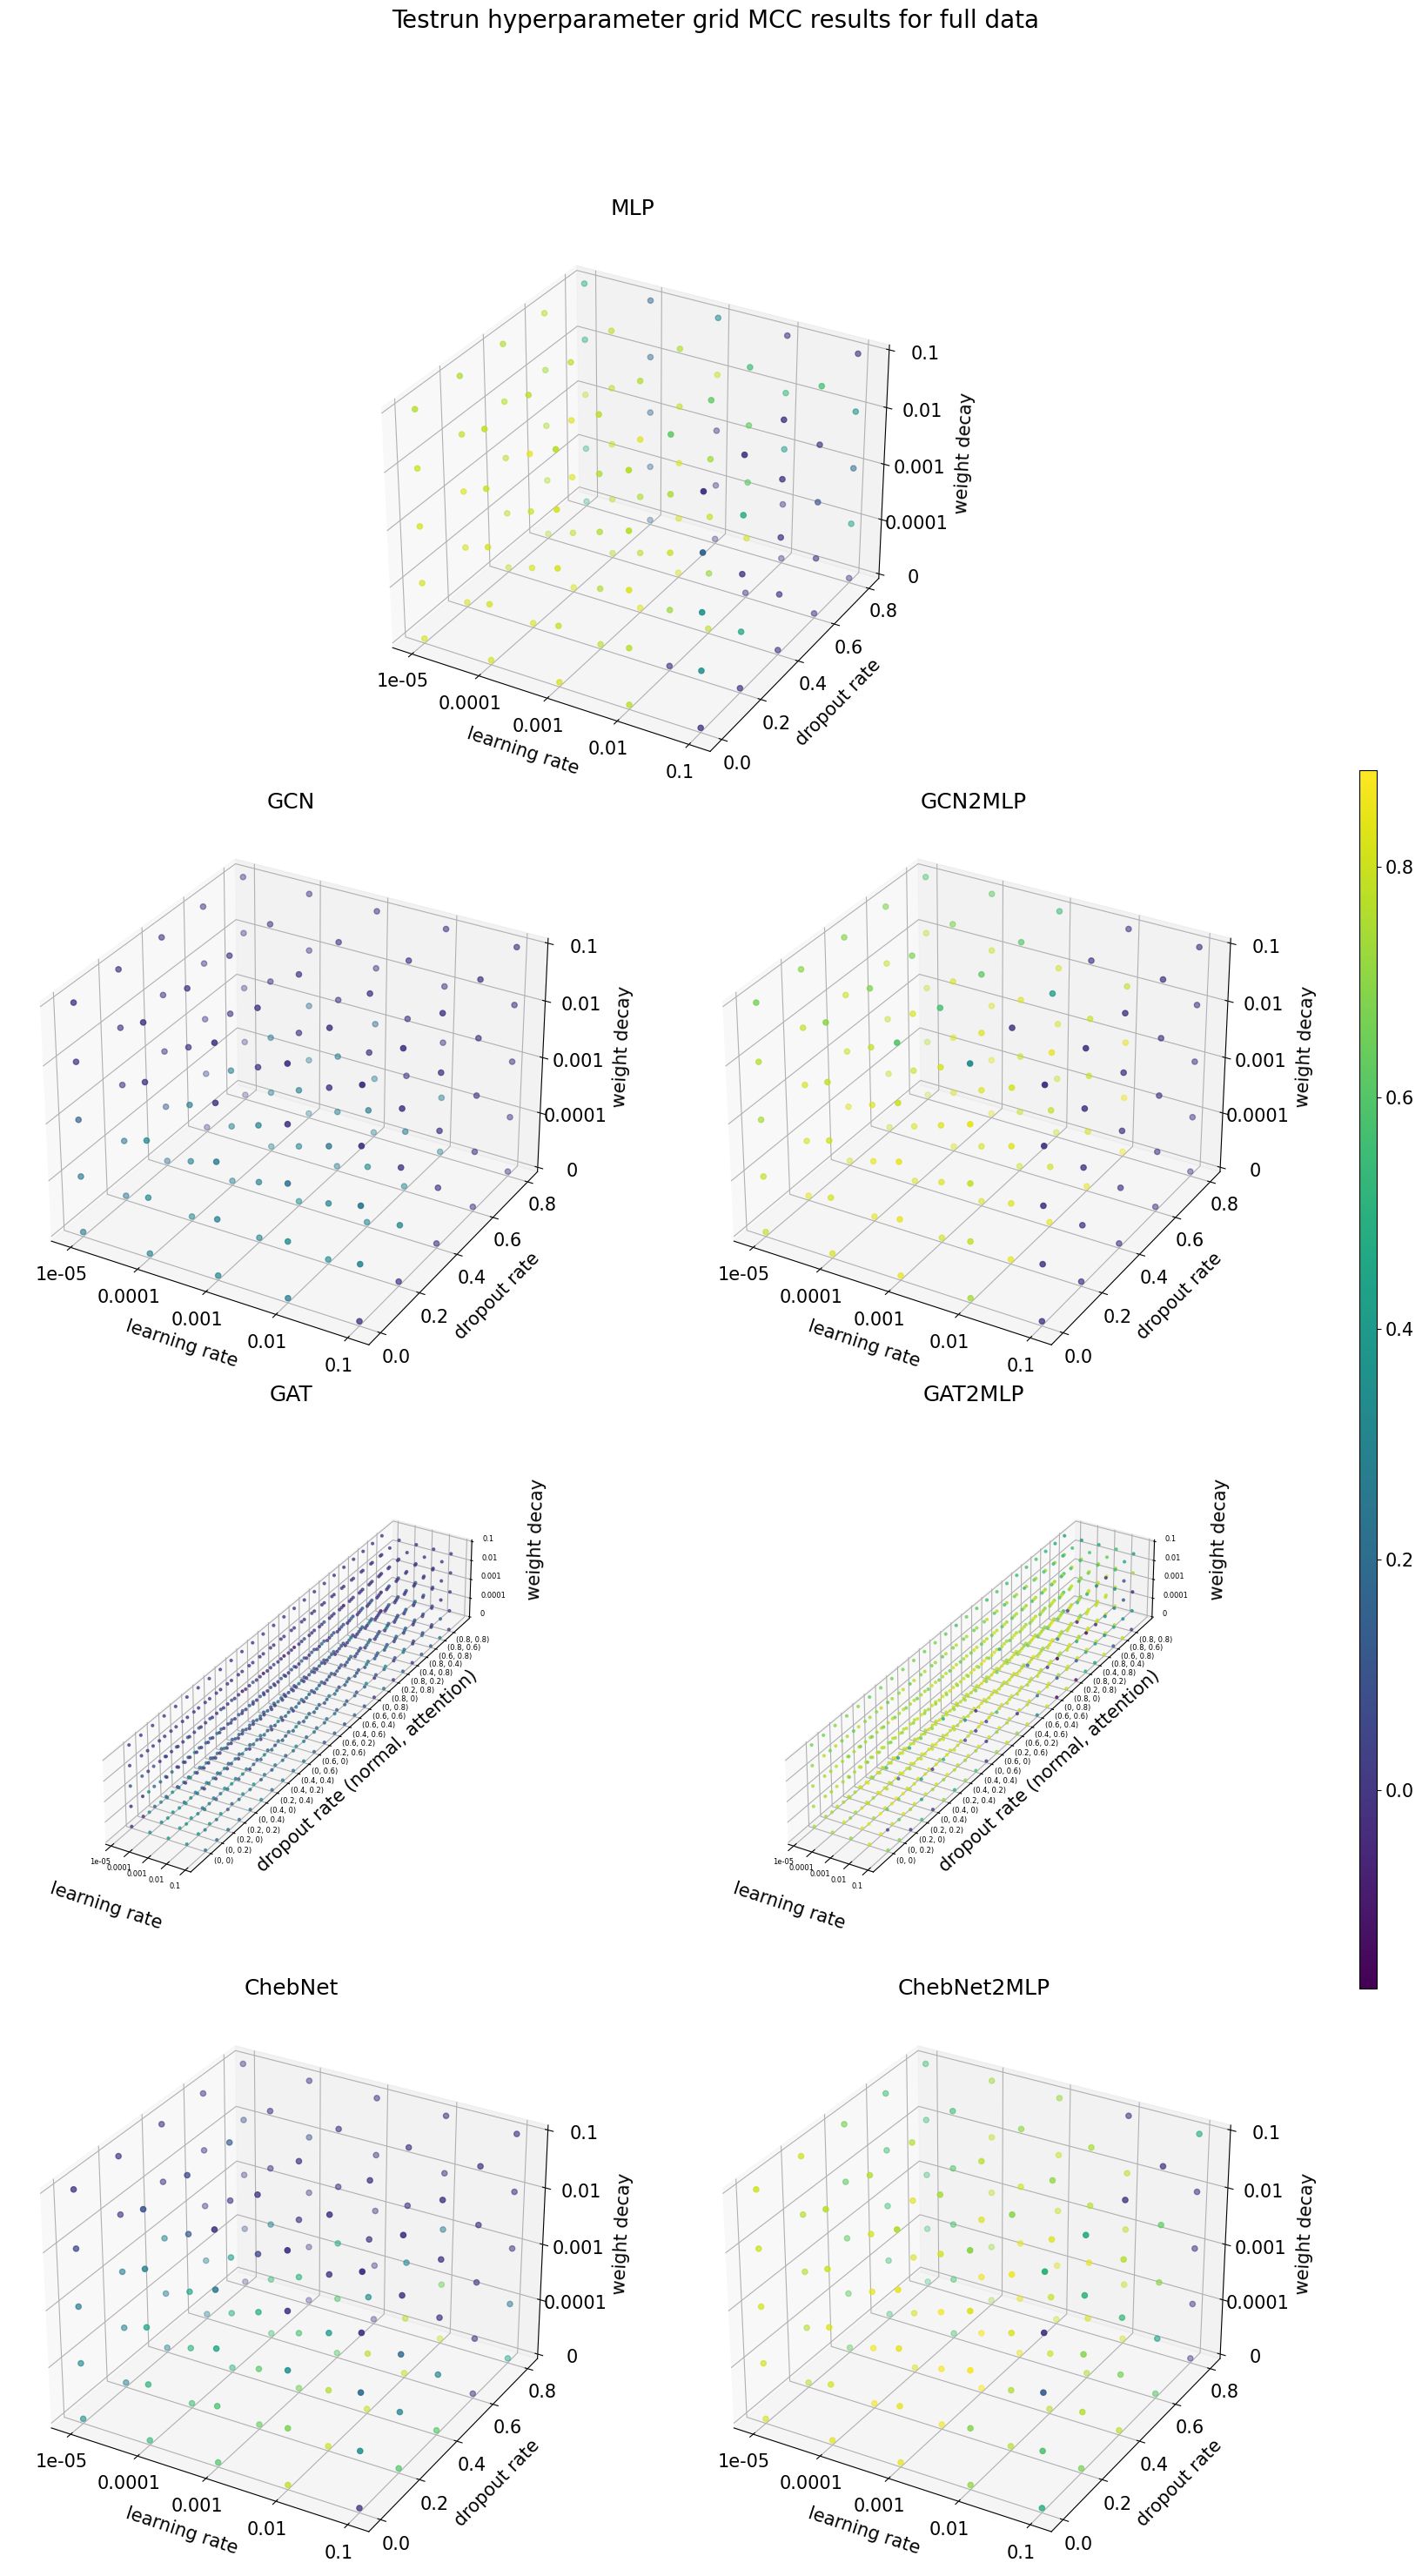

In [21]:
#BASIC MODELS, FULL DATA EXTENDED, 7 MODELS
title='Testrun hyperparameter grid MCC results'
fig = plt.figure(figsize=(20, 35))
fig.suptitle(title+' for full data', size=20, x=0.56, y=.95)

gs = gridspec.GridSpec(4, 4)#, height_ratios=[1, 1.8]) 
ax1 = fig.add_subplot(gs[0, 1:3], projection='3d')
ax2 = fig.add_subplot(gs[1, 0:2], projection='3d')
ax3 = fig.add_subplot(gs[1, 2:4], projection='3d')
ax4 = fig.add_subplot(gs[2, 0:2], projection='3d')
ax5 = fig.add_subplot(gs[2, 2:4], projection='3d')
ax6 = fig.add_subplot(gs[3, 0:2], projection='3d')
ax7 = fig.add_subplot(gs[3, 2:4], projection='3d')

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_full, vmax=max_mcc_full)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax1,MLP_results, cmap, norm)
ax1.set_title('MLP')
analysis_3d(ax2,GCN_results, cmap, norm)
ax2.set_title('GCN')
analysis_3d(ax3,GCN2MLP_results, cmap, norm)
ax3.set_title('GCN2MLP')
analysis_3d_gat(ax4,GAT_results, cmap, norm)
ax4.set_title('GAT')
analysis_3d_gat(ax5,GAT2MLP_results, cmap, norm)
ax5.set_title('GAT2MLP')
#fig.text(0.5, 0.5, 'GAT', ha='center', va='bottom', fontsize=14)
analysis_3d(ax6,ChebNet_results, cmap, norm)
ax6.set_title('ChebNet')
analysis_3d(ax7,ChebNet2MLP_results, cmap, norm)
ax7.set_title('ChebNet2MLP')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)

'''
plt.savefig(path+'/pretests_grid_short_full_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_short_full_extended.pdf', bbox_inches='tight')
'''
plt.show()


C:\Users\schirmacher3\AppData\Local\Temp\ipykernel_15968\1089203594.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
C:\Users\schirmacher3\AppData\Local\Temp\ipykernel_15968\1089203594.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
C:\Users\schirmacher3\AppData\Local\Temp\ipykernel_15968\1089203594.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\schirmacher3\AppData\Local\Temp\ipykernel_15968\1089203594.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#r

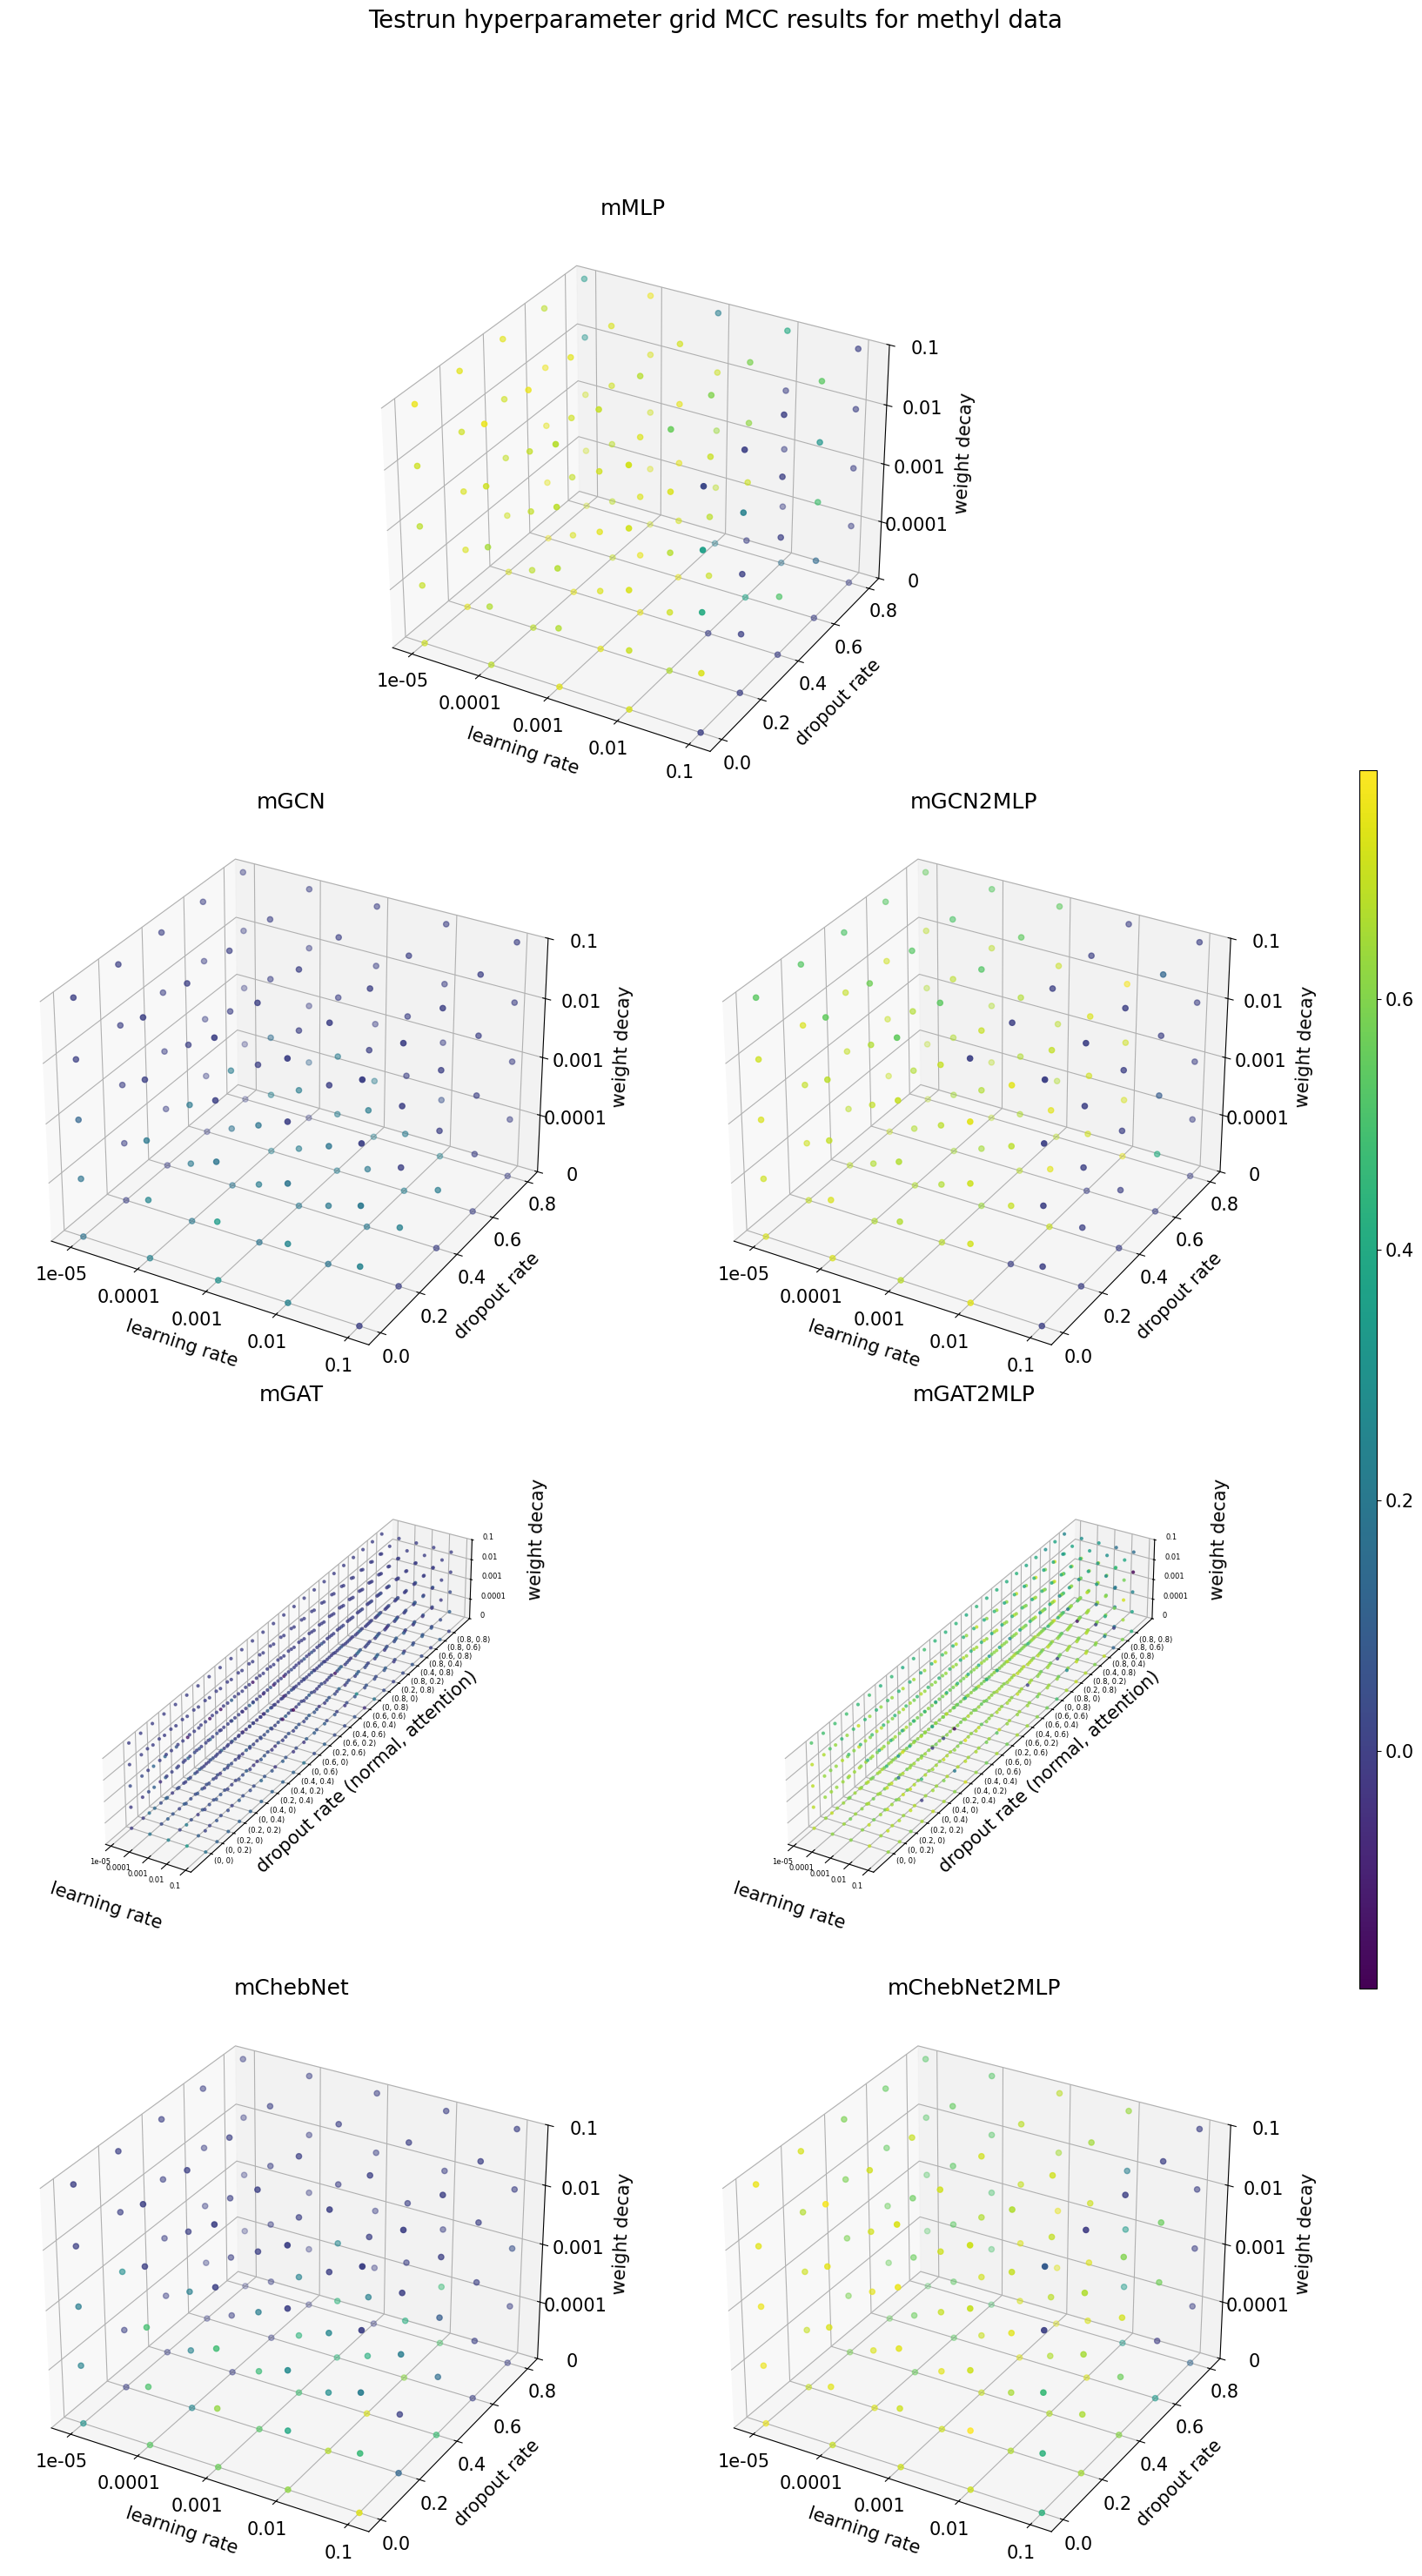

In [ ]:
#BASIC MODELS, METHYL DATA EXTENDED, 7 MODELS
title='Testrun hyperparameter grid MCC results'
fig = plt.figure(figsize=(20, 35))
fig.suptitle(title+' for methyl data', size=20, x=0.56, y=.95)

gs = gridspec.GridSpec(4, 4)#, height_ratios=[1, 1.8]) 
ax1 = fig.add_subplot(gs[0, 1:3], projection='3d')
ax2 = fig.add_subplot(gs[1, 0:2], projection='3d')
ax3 = fig.add_subplot(gs[1, 2:4], projection='3d')
ax4 = fig.add_subplot(gs[2, 0:2], projection='3d')
ax5 = fig.add_subplot(gs[2, 2:4], projection='3d')
ax6 = fig.add_subplot(gs[3, 0:2], projection='3d')
ax7 = fig.add_subplot(gs[3, 2:4], projection='3d')

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_methyl, vmax=max_mcc_methyl)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax1,mMLP_results, cmap, norm)
ax1.set_title('mMLP')
analysis_3d(ax2,mGCN_results, cmap, norm)
ax2.set_title('mGCN')
analysis_3d(ax3,mGCN2MLP_results, cmap, norm)
ax3.set_title('mGCN2MLP')
analysis_3d_gat(ax4,mGAT_results, cmap, norm)
ax4.set_title('mGAT')
analysis_3d_gat(ax5,mGAT2MLP_results, cmap, norm)
ax5.set_title('mGAT2MLP')
#fig.text(0.5, 0.5, 'GAT', ha='center', va='bottom', fontsize=14)
analysis_3d(ax6,mChebNet_results, cmap, norm)
ax6.set_title('mChebNet')
analysis_3d(ax7,mChebNet2MLP_results, cmap, norm)
ax7.set_title('mChebNet2MLP')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)
'''
plt.savefig(path+'/pretests_grid_short_methyl_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_short_methyl_extended.pdf', bbox_inches='tight')
'''
plt.show()


C:\Users\schirmacher3\AppData\Local\Temp\ipykernel_15968\1089203594.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
C:\Users\schirmacher3\AppData\Local\Temp\ipykernel_15968\1089203594.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
C:\Users\schirmacher3\AppData\Local\Temp\ipykernel_15968\1089203594.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\schirmacher3\AppData\Local\Temp\ipykernel_15968\1089203594.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#r

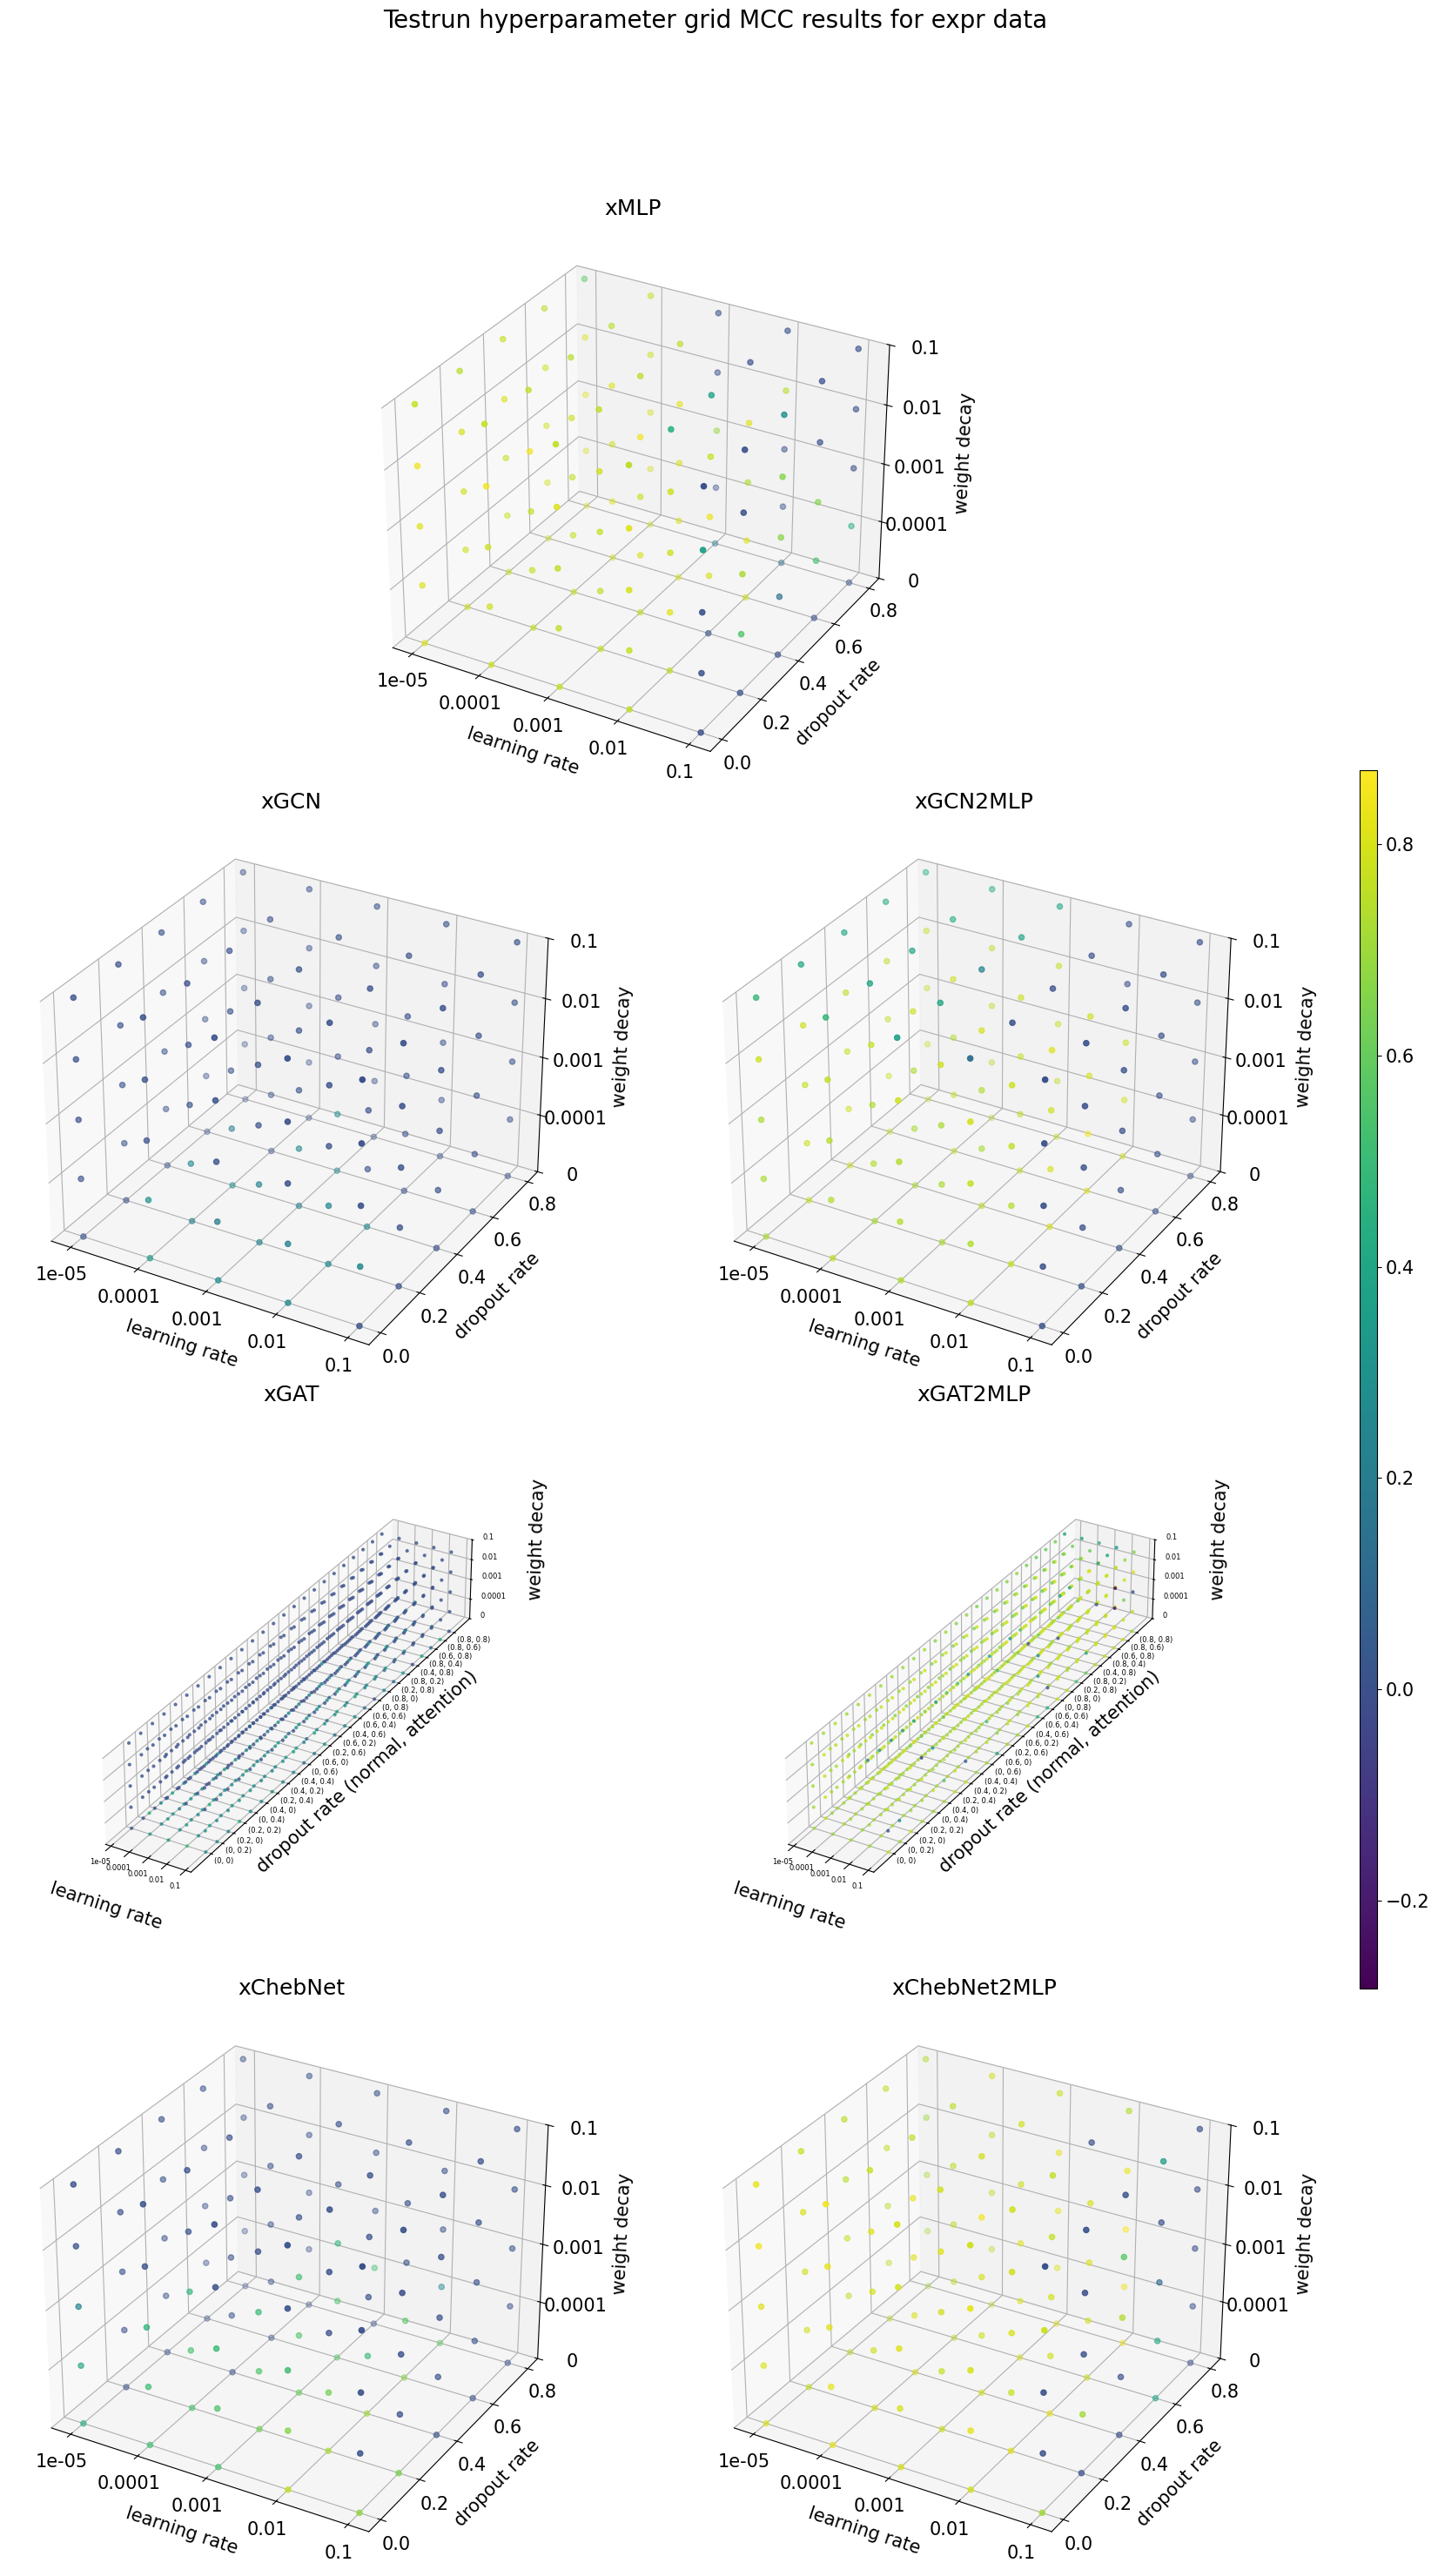

In [ ]:
#BASIC MODELS, EXPR DATA EXTENDED, 7 MODELS
title='Testrun hyperparameter grid MCC results'
fig = plt.figure(figsize=(20, 35))
fig.suptitle(title+' for expr data', size=20, x=0.56, y=.95)

gs = gridspec.GridSpec(4, 4)#, height_ratios=[1, 1.8]) 
ax1 = fig.add_subplot(gs[0, 1:3], projection='3d')
ax2 = fig.add_subplot(gs[1, 0:2], projection='3d')
ax3 = fig.add_subplot(gs[1, 2:4], projection='3d')
ax4 = fig.add_subplot(gs[2, 0:2], projection='3d')
ax5 = fig.add_subplot(gs[2, 2:4], projection='3d')
ax6 = fig.add_subplot(gs[3, 0:2], projection='3d')
ax7 = fig.add_subplot(gs[3, 2:4], projection='3d')

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_expr, vmax=max_mcc_expr)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax1,xMLP_results, cmap, norm)
ax1.set_title('xMLP')
analysis_3d(ax2,xGCN_results, cmap, norm)
ax2.set_title('xGCN')
analysis_3d(ax3,xGCN2MLP_results, cmap, norm)
ax3.set_title('xGCN2MLP')
analysis_3d_gat(ax4,xGAT_results, cmap, norm)
ax4.set_title('xGAT')
analysis_3d_gat(ax5,xGAT2MLP_results, cmap, norm)
ax5.set_title('xGAT2MLP')
#fig.text(0.5, 0.5, 'GAT', ha='center', va='bottom', fontsize=14)
analysis_3d(ax6,xChebNet_results, cmap, norm)
ax6.set_title('xChebNet')
analysis_3d(ax7,xChebNet2MLP_results, cmap, norm)
ax7.set_title('xChebNet2MLP')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)
'''
plt.savefig(path+'/pretests_grid_short_expr_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_short_expr_extended.pdf', bbox_inches='tight')
'''
plt.show()


In [ ]:
GAT_results.groupby(by=['config/train_loop_config/learning_rate']).mean(numeric_only=True)['time_total_s']

config/train_loop_config/learning_rate
0.0    4136.761723
1.0    2270.684567
2.0     416.964139
3.0     230.411704
4.0     237.909491
Name: time_total_s, dtype: float64

In [ ]:
# ###################################################################################### 
# ######################################################################################
#  SINGLE PLOT FOR ANALYSIS
#Set model
model_results = MLPLarger_results

mpl.rcParams.update({'font.size': 15})
title='Testrun hyperparameter grid MCC results, full data, MLP_Larger'
fig = plt.figure(figsize=(10, 7))
fig.suptitle(title, y=1, size=26)
max_val = model_results['val_mcc'].max()
min_val = model_results['val_mcc'].min()
fig.tight_layout(pad=40)

gs = gridspec.GridSpec(1, 1) 
ax = fig.add_subplot(gs[0, 0], projection='3d')

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax,model_results, cmap, norm)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)

'''
plt.savefig(path+'/pretests_grid_MLPLarger.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_MLPLarger.pdf', bbox_inches='tight')
'''

plt.show()


In [ ]:
# PLOT FOR ANALYSIS, New Models 2 DEEP
#Set model
title='Testrun hyperparameter grid MCC results, full data, Deeper Models'
fig = plt.figure(figsize=(15, 20))
fig.suptitle(title, y=1, size=26)

gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.8]) 
ax1 = fig.add_subplot(gs[0, 0:1], projection='3d')
ax2 = fig.add_subplot(gs[0, 1:2], projection='3d')
ax3 = fig.add_subplot(gs[1, 0:1], projection='3d')
ax4 = fig.add_subplot(gs[1, 1:2], projection='3d')

max_val = max([DeepGCN_results['val_mcc'].max(),
                DeepGAT_results['val_mcc'].max(),
                DeepGCN2MLP_results['val_mcc'].max(),
                DeepGAT2MLP_results['val_mcc'].max()]) + 0.05
min_val = min([DeepGCN_results['val_mcc'].min(),
               DeepGAT_results['val_mcc'].min(),
               DeepGCN2MLP_results['val_mcc'].min(),
               DeepGAT2MLP_results['val_mcc'].min()])-0.05

fig.tight_layout(pad=40)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax1,DeepGCN_results, cmap, norm)
ax1.set_title('DeepGCN')
analysis_3d(ax2,DeepGCN2MLP_results, cmap, norm)
ax2.set_title('DeepGCN2MLP')
analysis_3d_gat(ax3,DeepGAT_results, cmap, norm)
ax3.set_title('DeepGAT')
analysis_3d_gat(ax4,DeepGAT2MLP_results, cmap, norm)
ax4.set_title('DeepGAT2MLP')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)

'''
plt.savefig(path+'/pretests_grid_DeeperModels.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_DeeperModels.pdf', bbox_inches='tight')
'''

plt.show()


In [ ]:
# SINGLE PLOT FOR ANALYSIS, New Models 3 LIGHT
#Set model
title='Testrun hyperparameter grid MCC results, full data, Light Models'
fig = plt.figure(figsize=(15, 20))
fig.suptitle(title, y=1, size=26)

gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.8]) 
ax1 = fig.add_subplot(gs[0, 0:1], projection='3d')
ax2 = fig.add_subplot(gs[0, 1:2], projection='3d')
ax3 = fig.add_subplot(gs[1, 0:1], projection='3d')
ax4 = fig.add_subplot(gs[1, 1:2], projection='3d')

max_val = max([LightGCN_results['val_mcc'].max(),
                LightGAT_results['val_mcc'].max(),
                LightGCN2MLP_results['val_mcc'].max(),
                LightGAT2MLP_results['val_mcc'].max()]) + 0.05
min_val = min([LightGCN_results['val_mcc'].min(),
               LightGAT_results['val_mcc'].min(),
               LightGCN2MLP_results['val_mcc'].min(),
               LightGAT2MLP_results['val_mcc'].min()])-0.05

fig.tight_layout(pad=40)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax1,LightGCN_results, cmap, norm)
ax1.set_title('LightGCN')
analysis_3d(ax2,LightGCN2MLP_results, cmap, norm)
ax2.set_title('LightGCN2MLP')
analysis_3d_gat(ax3,LightGAT_results, cmap, norm)
ax3.set_title('LightGAT')
analysis_3d_gat(ax4,LightGAT2MLP_results, cmap, norm)
ax4.set_title('LightGAT2MLP')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)

'''
plt.savefig(path+'/pretests_grid_LightModels.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_LightModels.pdf', bbox_inches='tight')
'''

plt.show()

In [ ]:
# SINGLE PLOT FOR ANALYSIS, New Models 4 LIGHTDEEP
#Set model
title='Testrun hyperparameter grid MCC results, full data, LightDeep Models'
fig = plt.figure(figsize=(15, 20))
fig.suptitle(title, y=1, size=26)

gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.8]) 
ax1 = fig.add_subplot(gs[0, 0:1], projection='3d')
ax2 = fig.add_subplot(gs[0, 1:2], projection='3d')
ax3 = fig.add_subplot(gs[1, 0:1], projection='3d')
ax4 = fig.add_subplot(gs[1, 1:2], projection='3d')

max_val = max([LightDeepGCN_results['val_mcc'].max(),
                LightDeepGAT_results['val_mcc'].max(),
                LightDeepGCN2MLP_results['val_mcc'].max(),
                LightDeepGAT2MLP_results['val_mcc'].max()]) + 0.05
min_val = min([LightDeepGCN_results['val_mcc'].min(),
               LightDeepGAT_results['val_mcc'].min(),
               LightDeepGCN2MLP_results['val_mcc'].min(),
               LightDeepGAT2MLP_results['val_mcc'].min()])-0.05

fig.tight_layout(pad=40)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax1,LightDeepGCN_results, cmap, norm)
ax1.set_title('LightDeepGCN')
analysis_3d(ax2,LightGCN2MLP_results, cmap, norm)
ax2.set_title('LightDeepGCN2MLP')
analysis_3d_gat(ax3,LightDeepGAT_results, cmap, norm)
ax3.set_title('LightDeepGAT')
analysis_3d_gat(ax4,LightDeepGAT2MLP_results, cmap, norm)
ax4.set_title('LightDeepGAT2MLP')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)

'''
plt.savefig(path+'/pretests_grid_LightDeepModels.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_LightDeepModels.pdf', bbox_inches='tight')
'''

plt.show()

In [ ]:
#FULL DATA, 3 MODELS
title='Testrun hyperparameter grid MCC results'
fig = plt.figure(figsize=(18, 18))
fig.suptitle(title+' for full data', size=20, x=0.56, y=.95)

gs = gridspec.GridSpec(2, 4, height_ratios=[1, 1.8]) 
ax1 = fig.add_subplot(gs[0, 0:2], projection='3d')
ax2 = fig.add_subplot(gs[0, 2:4], projection='3d')
ax3 = fig.add_subplot(gs[1, 0:4], projection='3d')

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_full, vmax=max_mcc_full)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax1,MLP_results, cmap, norm)
ax1.set_title('MLP')
analysis_3d(ax2,GCN_results, cmap, norm)
ax2.set_title('GCN')
analysis_3d_gat(ax3,GAT_results, cmap, norm)
fig.text(0.5, 0.5, 'GAT', ha='center', va='bottom', fontsize=14)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)

'''
plt.savefig(path+'/pretests_grid_short_full.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_short_full.pdf', bbox_inches='tight')
'''
plt.show()


C:\Users\julia\AppData\Local\Temp\ipykernel_32188\1089203594.py:25: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()
C:\Users\julia\AppData\Local\Temp\ipykernel_32188\1089203594.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dp['dropout'] = data[['config/train_loop_config/dropout_rate_normal','config/train_loop_config/dropout_rate_attention']].apply(tuple, axis=1)
C:\Users\julia\AppData\Local\Temp\ipykernel_32188\1089203594.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ve

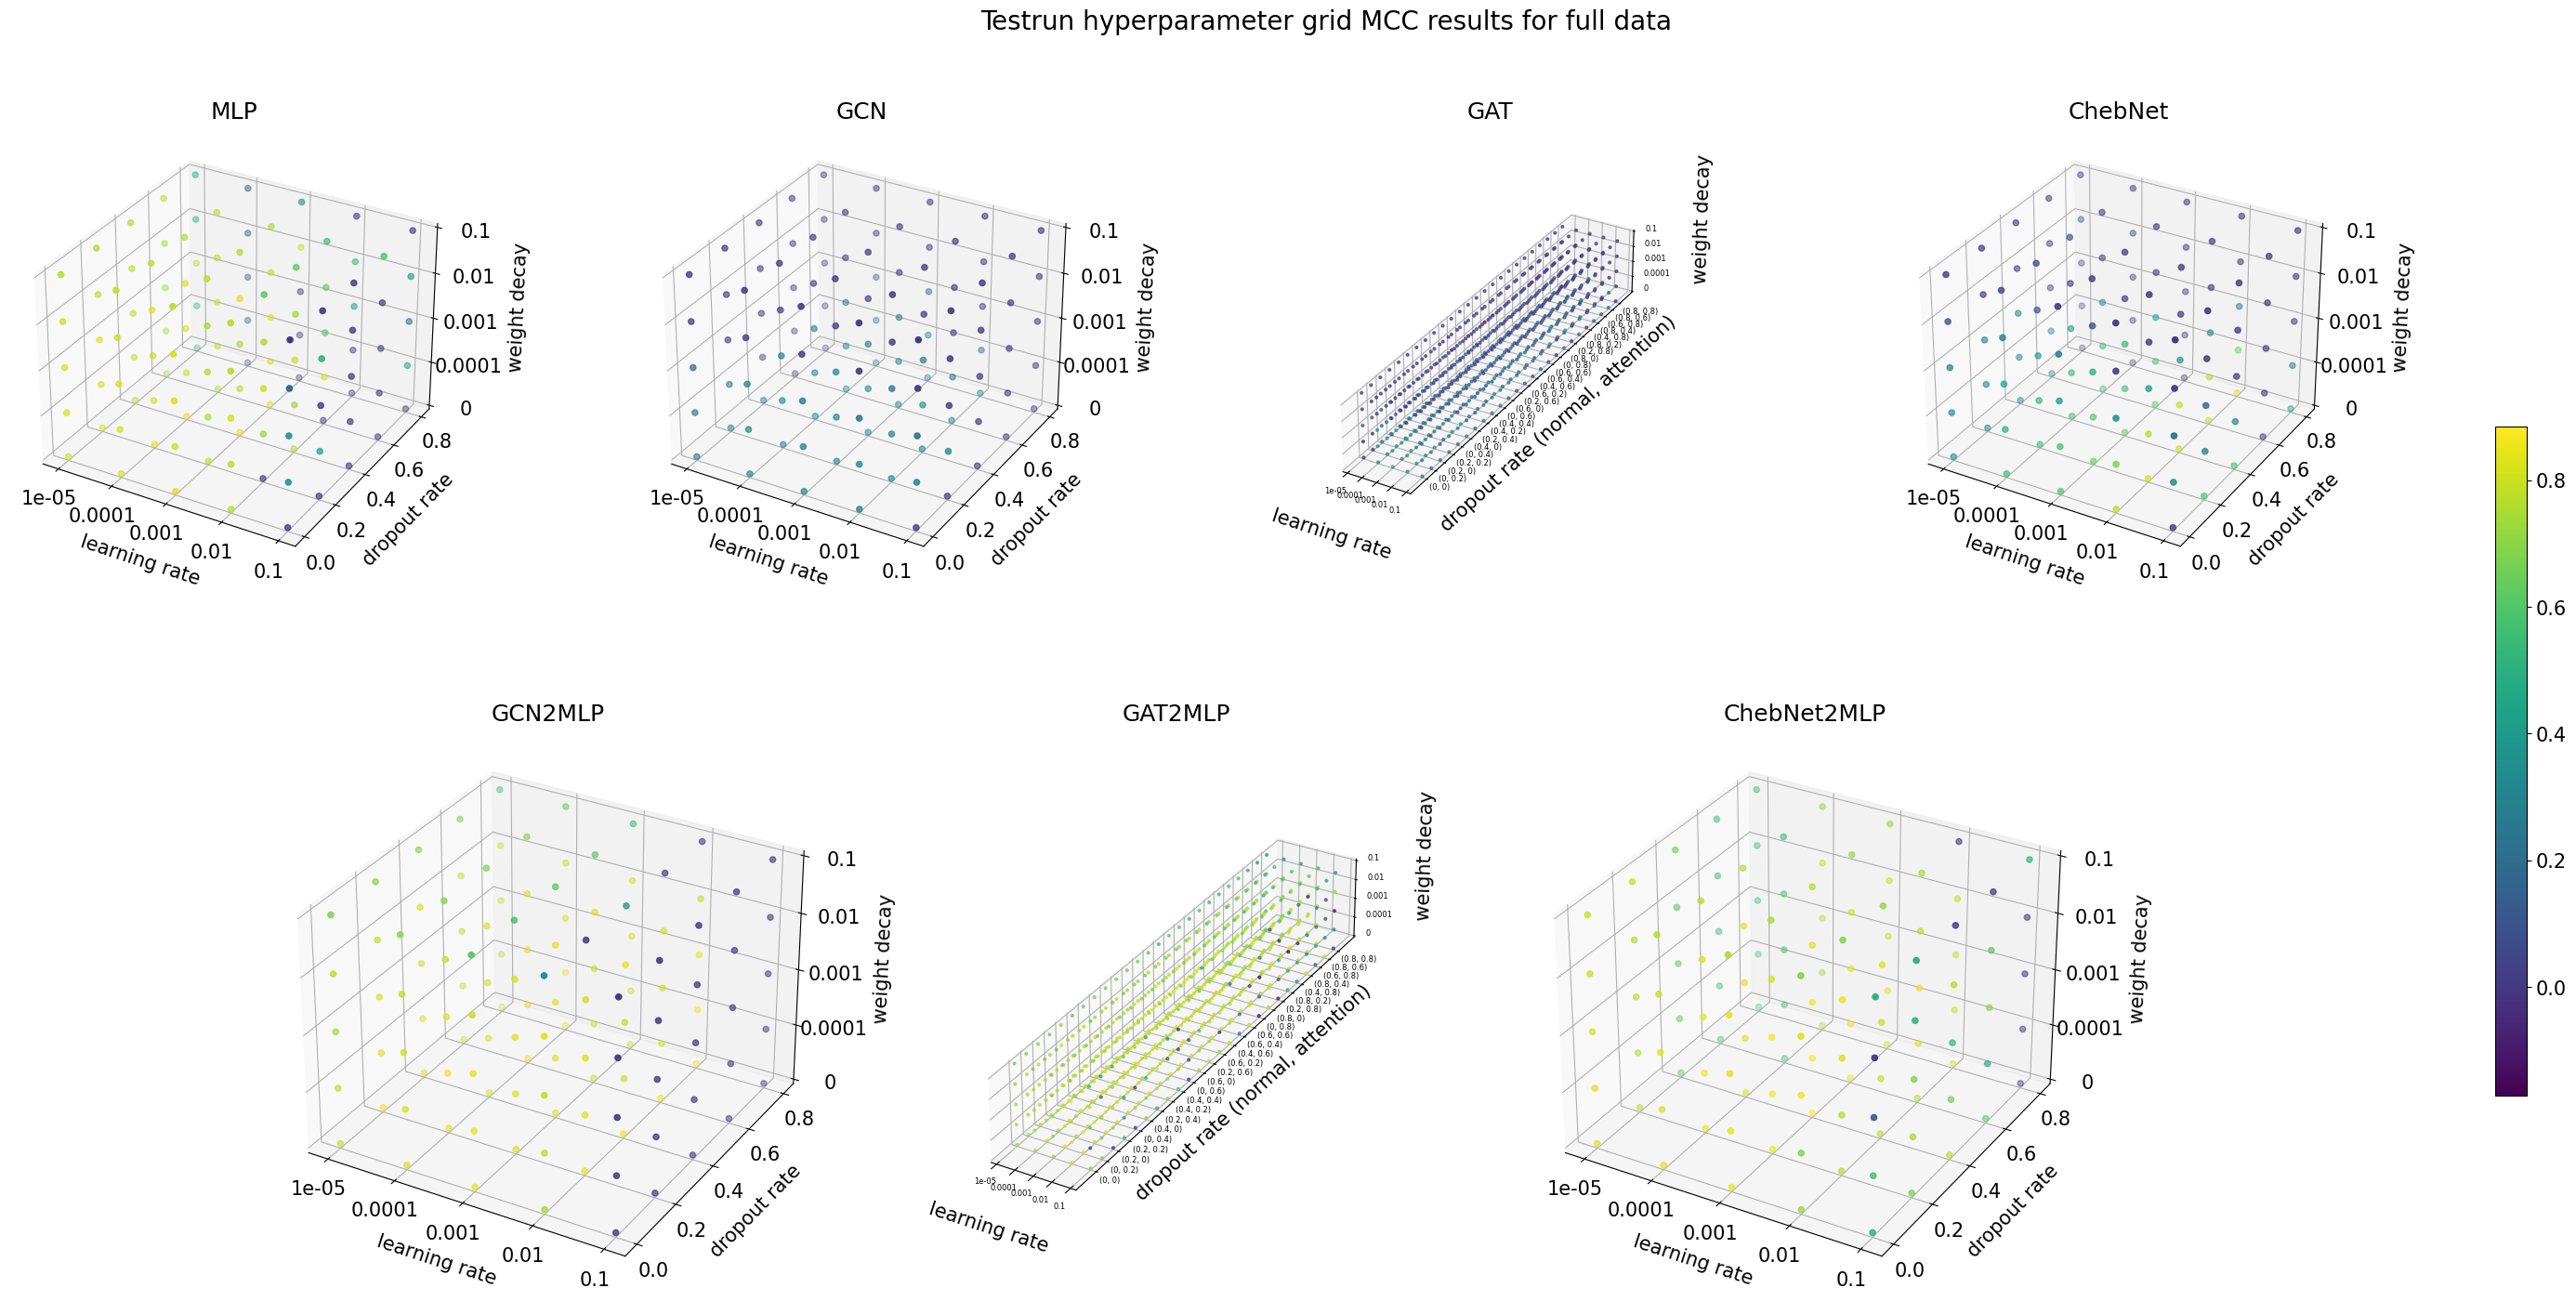

In [ ]:
#FULL DATA EXTENDED, 5 MODELS
title='Testrun hyperparameter grid MCC results'
fig = plt.figure(figsize=(34, 18))
fig.suptitle(title+' for full data', size=20, x=0.56, y=.95)

gs = gridspec.GridSpec(2, 8, height_ratios=[1, 1.8]) 
ax1 = fig.add_subplot(gs[0, 0:2], projection='3d')
ax2 = fig.add_subplot(gs[0, 2:4], projection='3d')
ax3 = fig.add_subplot(gs[0, 4:6], projection='3d')
ax3_2 = fig.add_subplot(gs[0, 6:8], projection='3d')
ax4 = fig.add_subplot(gs[1, 1:3], projection='3d')
ax5 = fig.add_subplot(gs[1, 3:5], projection='3d')
ax5_2 = fig.add_subplot(gs[1, 5:7], projection='3d')

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_full, vmax=max_mcc_full)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax1,MLP_results, cmap, norm)
ax1.set_title('MLP')
analysis_3d(ax2,GCN_results, cmap, norm)
ax2.set_title('GCN')
analysis_3d_gat(ax3,GAT_results, cmap, norm)
ax3.set_title('GAT')
analysis_3d(ax3_2,ChebNet_results, cmap, norm)
ax3_2.set_title('ChebNet')
#fig.text(0.5, 0.5, 'GAT', ha='center', va='bottom', fontsize=14)
analysis_3d(ax4,GCN2MLP_results, cmap, norm)
ax4.set_title('GCN2MLP')
analysis_3d_gat(ax5,GAT2MLP_results, cmap, norm)
ax5.set_title('GAT2MLP')
analysis_3d(ax5_2,ChebNet2MLP_results, cmap, norm)
ax5_2.set_title('ChebNet2MLP')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.26, hspace=0.05)
'''
plt.savefig(path+'/pretests_grid_short_full_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_short_full_extended.pdf', bbox_inches='tight')
'''
plt.show()


In [ ]:
#FULL DATA
title='Testrun hyperparameter grid MCC results'
fig = plt.figure(figsize=(20, 20))
fig.suptitle(title+' for full data', size=20)
ax = np.array([fig.add_subplot(3,3,j+3*(i-1), projection='3d') for i in range(1,4,1) for j in range(1,4,1)]).reshape(3,3)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_full, vmax=max_mcc_full)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax[0,0],MLP_results, cmap, norm)
ax[0,0].set_title('MLP')
analysis_3d(ax[0,1],ResMLP_results, cmap, norm)
ax[0,1].set_title('ResMLP')
analysis_3d(ax[0,2],DenseMLP_results, cmap, norm)
ax[0,2].set_title('DenseMLP')

analysis_3d(ax[1,0],GCN_results, cmap, norm)
ax[1,0].set_title('GCN')
analysis_3d(ax[1,1],ResGCN_results, cmap, norm)
ax[1,1].set_title('ResGCN')
analysis_3d(ax[1,2],DenseGCN_results, cmap, norm)
ax[1,2].set_title('DenseGCN')

analysis_3d_gat(ax[2,0],GAT_results, cmap, norm, single=False)
ax[2,0].set_title('GAT')
analysis_3d_gat(ax[2,1],ResGAT_results, cmap, norm, single=False)
ax[2,1].set_title('ResGAT')
analysis_3d_gat(ax[2,2],DenseGAT_results, cmap, norm, single=False)
sc = ax[2,2].set_title('DenseGAT')

fig.subplots_adjust(right=0.87)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.subplots_adjust(wspace=0.3, hspace=0.2)

'''
plt.savefig(path+'/pretests_grid_full.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_full.pdf', bbox_inches='tight')
'''
plt.show()

NameError: name 'min_mcc_full' is not defined

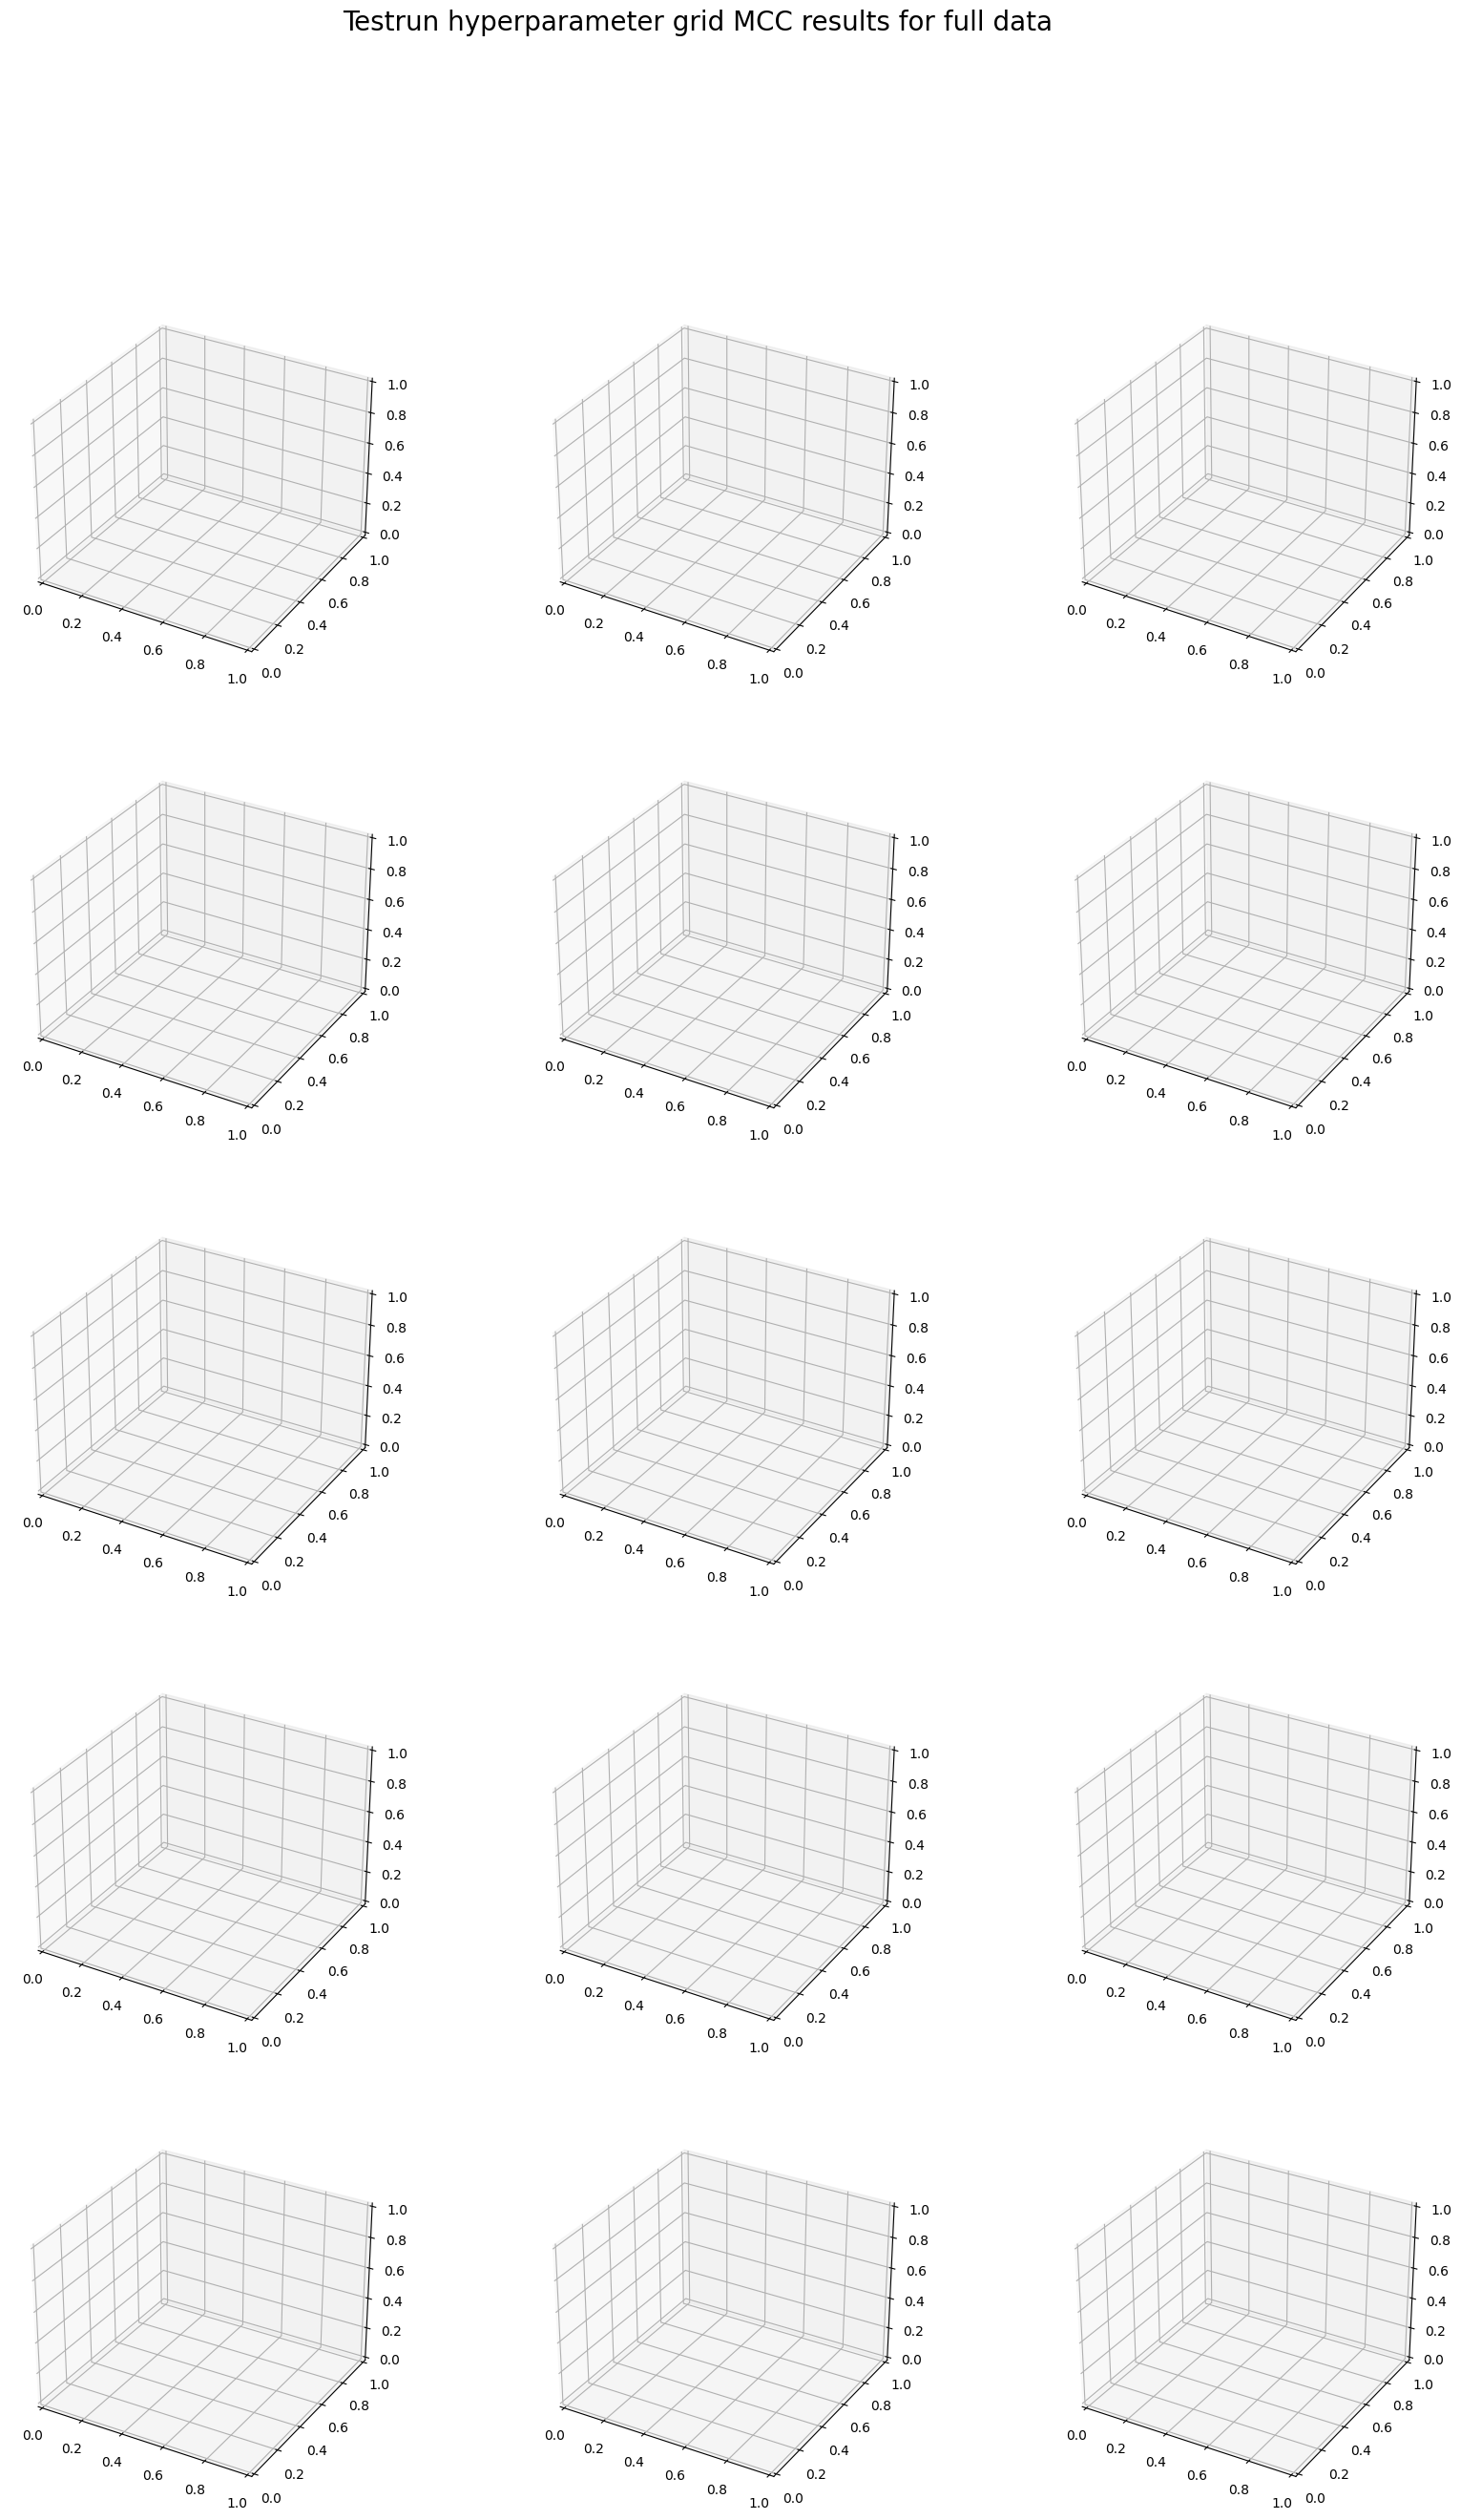

In [4]:
#FULL DATA EXTENDED
title='Testrun hyperparameter grid MCC results'
fig = plt.figure(figsize=(20, 30))
fig.suptitle(title+' for full data', size=20)
ax = np.array([fig.add_subplot(5,3,j+3*(i-1), projection='3d') for i in range(1,6,1) for j in range(1,4,1)]).reshape(5,3)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_full, vmax=max_mcc_full)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax[0,0],MLP_results, cmap, norm)
ax[0,0].set_title('MLP')
analysis_3d(ax[0,1],ResMLP_results, cmap, norm)
ax[0,1].set_title('ResMLP')
analysis_3d(ax[0,2],DenseMLP_results, cmap, norm)
ax[0,2].set_title('DenseMLP')

analysis_3d(ax[1,0],GCN_results, cmap, norm)
ax[1,0].set_title('GCN')
analysis_3d(ax[1,1],ResGCN_results, cmap, norm)
ax[1,1].set_title('ResGCN')
analysis_3d(ax[1,2],DenseGCN_results, cmap, norm)
ax[1,2].set_title('DenseGCN')

analysis_3d_gat(ax[2,0],GAT_results, cmap, norm, single=False)
ax[2,0].set_title('GAT')
analysis_3d_gat(ax[2,1],ResGAT_results, cmap, norm, single=False)
ax[2,1].set_title('ResGAT')
analysis_3d_gat(ax[2,2],DenseGAT_results, cmap, norm, single=False)
ax[2,2].set_title('DenseGAT')

analysis_3d(ax[3,0],GCN2MLP_results, cmap, norm)
ax[3,0].set_title('GCN2MLP')
analysis_3d(ax[3,1],ResGCN2MLP_results, cmap, norm)
ax[3,1].set_title('ResGCN2MLP')
analysis_3d(ax[3,2],DenseGCN2MLP_results, cmap, norm)
ax[3,2].set_title('DenseGCN2MLP')

analysis_3d_gat(ax[4,0],GAT2MLP_results, cmap, norm, single=False)
ax[4,0].set_title('GAT2MLP')
analysis_3d_gat(ax[4,1],ResGAT2MLP_results, cmap, norm, single=False)
ax[4,1].set_title('ResGAT2MLP')
analysis_3d_gat(ax[4,2],DenseGAT2MLP_results, cmap, norm, single=False)
sc = ax[4,2].set_title('DenseGAT2MLP')

fig.subplots_adjust(right=0.87)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.subplots_adjust(wspace=0.3, hspace=0.2)
'''
plt.savefig(path+'/pretests_grid_full_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_full_extended.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
#METHYL DATA
fig = plt.figure(figsize=(20,20))
fig.suptitle(title+' for methylation data', size=20)
ax = np.array([fig.add_subplot(3,3,j+3*(i-1), projection='3d') for i in range(1,4,1) for j in range(1,4,1)]).reshape(3,3)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_methyl, vmax=max_mcc_methyl)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax[0,0],mMLP_results, cmap, norm)
ax[0,0].set_title('mMLP')
analysis_3d(ax[0,1],mResMLP_results, cmap, norm)
ax[0,1].set_title('mResMLP')
analysis_3d(ax[0,2],mDenseMLP_results, cmap, norm)
ax[0,2].set_title('mDenseMLP')

analysis_3d(ax[1,0],mGCN_results, cmap, norm)
ax[1,0].set_title('mGCN')
analysis_3d(ax[1,1],mResGCN_results, cmap, norm)
ax[1,1].set_title('mResGCN')
analysis_3d(ax[1,2],mDenseGCN_results, cmap, norm)
ax[1,2].set_title('mDenseGCN')

analysis_3d_gat(ax[2,0],mGAT_results, cmap, norm)
ax[2,0].set_title('mGAT')
analysis_3d_gat(ax[2,1],mResGAT_results, cmap, norm)
ax[2,1].set_title('mResGAT')
analysis_3d_gat(ax[2,2],mDenseGAT_results, cmap, norm)
sc = ax[2,2].set_title('mDenseGAT')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.subplots_adjust(wspace=0.3, hspace=0.2)

'''
plt.savefig(path+'/pretests_grid_methyl.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_methyl.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
#METHYL DATA EXTENDED
fig = plt.figure(figsize=(20,30))
fig.suptitle(title+' for methylation data', size=20)
ax = np.array([fig.add_subplot(5,3,j+3*(i-1), projection='3d') for i in range(1,6,1) for j in range(1,4,1)]).reshape(5,3)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_methyl, vmax=max_mcc_methyl)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax[0,0],mMLP_results, cmap, norm)
ax[0,0].set_title('mMLP')
analysis_3d(ax[0,1],mResMLP_results, cmap, norm)
ax[0,1].set_title('mResMLP')
analysis_3d(ax[0,2],mDenseMLP_results, cmap, norm)
ax[0,2].set_title('mDenseMLP')

analysis_3d(ax[1,0],mGCN_results, cmap, norm)
ax[1,0].set_title('mGCN')
analysis_3d(ax[1,1],mResGCN_results, cmap, norm)
ax[1,1].set_title('mResGCN')
analysis_3d(ax[1,2],mDenseGCN_results, cmap, norm)
ax[1,2].set_title('mDenseGCN')

analysis_3d_gat(ax[2,0],mGAT_results, cmap, norm)
ax[2,0].set_title('mGAT')
analysis_3d_gat(ax[2,1],mResGAT_results, cmap, norm)
ax[2,1].set_title('mResGAT')
analysis_3d_gat(ax[2,2],mDenseGAT_results, cmap, norm)
sc = ax[2,2].set_title('mDenseGAT')

analysis_3d(ax[3,0],mGCN2MLP_results, cmap, norm)
ax[3,0].set_title('mGCN2MLP')
analysis_3d(ax[3,1],mResGCN2MLP_results, cmap, norm)
ax[3,1].set_title('mResGCN2MLP')
analysis_3d(ax[3,2],mDenseGCN2MLP_results, cmap, norm)
ax[3,2].set_title('mDenseGCN2MLP')

analysis_3d_gat(ax[4,0],mGAT2MLP_results, cmap, norm)
ax[4,0].set_title('mGAT2MLP')
analysis_3d_gat(ax[4,1],mResGAT2MLP_results, cmap, norm)
ax[4,1].set_title('mResGAT2MLP')
analysis_3d_gat(ax[4,2],mDenseGAT2MLP_results, cmap, norm)
sc = ax[4,2].set_title('mDenseGAT2MLP')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.subplots_adjust(wspace=0.3, hspace=0.2)

'''
plt.savefig(path+'/pretests_grid_methyl_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_methyl_extended.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
#EXPRESSION DATA
fig = plt.figure(figsize=(20,20))
fig.suptitle(title+' for expression data', size=20)
ax = np.array([fig.add_subplot(3,3,j+3*(i-1), projection='3d') for i in range(1,4,1) for j in range(1,4,1)]).reshape(3,3)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_expr, vmax=max_mcc_expr)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax[0,0],xMLP_results, cmap, norm)
ax[0,0].set_title('xMLP')
analysis_3d(ax[0,1],xResMLP_results, cmap, norm)
ax[0,1].set_title('xResMLP')
analysis_3d(ax[0,2],xDenseMLP_results, cmap, norm)
ax[0,2].set_title('xDenseMLP')

analysis_3d(ax[1,0],xGCN_results, cmap, norm)
ax[1,0].set_title('xGCN')
analysis_3d(ax[1,1],xResGCN_results, cmap, norm)
ax[1,1].set_title('xResGCN')
analysis_3d(ax[1,2],xDenseGCN_results, cmap, norm)
ax[1,2].set_title('xDenseGCN')

analysis_3d_gat(ax[2,0],xGAT_results, cmap, norm)
ax[2,0].set_title('xGAT')
analysis_3d_gat(ax[2,1],xResGAT_results, cmap, norm)
ax[2,1].set_title('xResGAT')
analysis_3d_gat(ax[2,2],xDenseGAT_results, cmap, norm)
sc = ax[2,2].set_title('xDenseGAT')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.subplots_adjust(wspace=0.3, hspace=0.2)
'''
plt.savefig(path+'/pretests_grid_expr.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_expr.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
#EXPRESSION DATA EXTENDED
fig = plt.figure(figsize=(20,30))
fig.suptitle(title+' for expression data', size=20)
ax = np.array([fig.add_subplot(5,3,j+3*(i-1), projection='3d') for i in range(1,6,1) for j in range(1,4,1)]).reshape(5,3)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_expr, vmax=max_mcc_expr)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax[0,0],xMLP_results, cmap, norm)
ax[0,0].set_title('xMLP')
analysis_3d(ax[0,1],xResMLP_results, cmap, norm)
ax[0,1].set_title('xResMLP')
analysis_3d(ax[0,2],xDenseMLP_results, cmap, norm)
ax[0,2].set_title('xDenseMLP')

analysis_3d(ax[1,0],xGCN_results, cmap, norm)
ax[1,0].set_title('xGCN')
analysis_3d(ax[1,1],xResGCN_results, cmap, norm)
ax[1,1].set_title('xResGCN')
analysis_3d(ax[1,2],xDenseGCN_results, cmap, norm)
ax[1,2].set_title('xDenseGCN')

analysis_3d_gat(ax[2,0],xGAT_results, cmap, norm)
ax[2,0].set_title('xGAT')
analysis_3d_gat(ax[2,1],xResGAT_results, cmap, norm)
ax[2,1].set_title('xResGAT')
analysis_3d_gat(ax[2,2],xDenseGAT_results, cmap, norm)
sc = ax[2,2].set_title('xDenseGAT')

analysis_3d(ax[3,0],xGCN2MLP_results, cmap, norm)
ax[3,0].set_title('xGCN2MLP')
analysis_3d(ax[3,1],xResGCN2MLP_results, cmap, norm)
ax[3,1].set_title('xResGCN2MLP')
analysis_3d(ax[3,2],xDenseGCN2MLP_results, cmap, norm)
ax[3,2].set_title('xDenseGCN2MLP')

analysis_3d_gat(ax[4,0],xGAT2MLP_results, cmap, norm)
ax[4,0].set_title('xGAT2MLP')
analysis_3d_gat(ax[4,1],xResGAT2MLP_results, cmap, norm)
ax[4,1].set_title('xResGAT2MLP')
analysis_3d_gat(ax[4,2],xDenseGAT2MLP_results, cmap, norm)
sc = ax[4,2].set_title('xDenseGAT2MLP')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.subplots_adjust(wspace=0.3, hspace=0.2)
'''
plt.savefig(path+'/pretests_grid_expr_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_expr_extended.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
#NEW METHODS GCN2MLP
title='Testrun hyperparameter grid MCC results'
fig = plt.figure(figsize=(20, 20))
fig.suptitle(title+' for full data', size=20)
ax = np.array([fig.add_subplot(3,3,j+3*(i-1), projection='3d') for i in range(1,4,1) for j in range(1,4,1)]).reshape(3,3)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_full, vmax=max_mcc_full)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax[0,0],GCN2MLP_results, cmap, norm)
ax[0,0].set_title('GCN2MLP')
analysis_3d(ax[0,1],ResGCN2MLP_results, cmap, norm)
ax[0,1].set_title('ResGCN2MLP')
analysis_3d(ax[0,2],DenseGCN2MLP_results, cmap, norm)
ax[0,2].set_title('DenseGCN2MLP')

analysis_3d(ax[1,0],mGCN2MLP_results, cmap, norm)
ax[1,0].set_title('mGCN2MLP')
analysis_3d(ax[1,1],mResGCN2MLP_results, cmap, norm)
ax[1,1].set_title('mResGCN2MLP')
analysis_3d(ax[1,2],mDenseGCN2MLP_results, cmap, norm)
ax[1,2].set_title('mDenseGCN2MLP')

analysis_3d(ax[2,0],xGCN2MLP_results, cmap, norm)
ax[2,0].set_title('xGCN2MLP')
analysis_3d(ax[2,1],xResGCN2MLP_results, cmap, norm)
ax[2,1].set_title('xResGCN2MLP')
analysis_3d(ax[2,2],xDenseGCN2MLP_results, cmap, norm)
sc = ax[2,2].set_title('xDenseGCN2MLP')

fig.subplots_adjust(right=0.87)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.subplots_adjust(wspace=0.3, hspace=0.2)
'''
plt.savefig(path+'/pretests_grid_GCN2MLP.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_GCN2MLP.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
#NEW METHODS GAT2MLP
title='Testrun hyperparameter grid MCC results'
fig = plt.figure(figsize=(20, 20))
fig.suptitle(title+' for full data', size=20)
ax = np.array([fig.add_subplot(3,3,j+3*(i-1), projection='3d') for i in range(1,4,1) for j in range(1,4,1)]).reshape(3,3)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_mcc_full, vmax=max_mcc_full)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d_gat(ax[0,0],GAT2MLP_results, cmap, norm)
ax[0,0].set_title('GAT2MLP')
analysis_3d_gat(ax[0,1],ResGAT2MLP_results, cmap, norm)
ax[0,1].set_title('ResGAT2MLP')
analysis_3d_gat(ax[0,2],DenseGAT2MLP_results, cmap, norm)
ax[0,2].set_title('DenseGAT2MLP')

analysis_3d_gat(ax[1,0],mGAT2MLP_results, cmap, norm)
ax[1,0].set_title('mGAT2MLP')
analysis_3d_gat(ax[1,1],mResGAT2MLP_results, cmap, norm)
ax[1,1].set_title('mResGAT2MLP')
analysis_3d_gat(ax[1,2],mDenseGAT2MLP_results, cmap, norm)
ax[1,2].set_title('mDenseGAT2MLP')

analysis_3d_gat(ax[2,0],xGAT2MLP_results, cmap, norm)
ax[2,0].set_title('xGAT2MLP')
analysis_3d_gat(ax[2,1],xResGAT2MLP_results, cmap, norm)
ax[2,1].set_title('xResGAT2MLP')
analysis_3d_gat(ax[2,2],xDenseGAT2MLP_results, cmap, norm)
sc = ax[2,2].set_title('xDenseGAT2MLP')

fig.subplots_adjust(right=0.87)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.subplots_adjust(wspace=0.3, hspace=0.2)
'''
plt.savefig(path+'/pretests_grid_GAT2MLP.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_GAT2MLP.pdf', bbox_inches='tight')
'''
plt.show()

In [ ]:
#CHEBNET MODELS
fig = plt.figure(figsize=(20,20))
fig.suptitle(title+' for ChebNet models', size=20)
ax = np.array([fig.add_subplot(3,3,j+3*(i-1), projection='3d') for i in range(1,4,1) for j in range(1,4,1)]).reshape(3,3)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_val_cheb, vmax=max_val_cheb)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax[0,0],ChebNet_results, cmap, norm)
ax[0,0].set_title('ChebNet')
analysis_3d(ax[0,1],ResChebNet_results, cmap, norm)
ax[0,1].set_title('ResChebNet')
analysis_3d(ax[0,2],DenseChebNet_results, cmap, norm)
ax[0,2].set_title('DenseChebNet')

analysis_3d(ax[1,0],mChebNet_results, cmap, norm)
ax[1,0].set_title('mChebNet')
analysis_3d(ax[1,1],mResChebNet_results, cmap, norm)
ax[1,1].set_title('mResChebNet')
analysis_3d(ax[1,2],mDenseChebNet_results, cmap, norm)
ax[1,2].set_title('mDenseChebNet')

analysis_3d(ax[2,0],xChebNet_results, cmap, norm)
ax[2,0].set_title('xChebNet')
analysis_3d(ax[2,1],xResChebNet_results, cmap, norm)
ax[2,1].set_title('xResChebNet')
analysis_3d(ax[2,2],xDenseChebNet_results, cmap, norm)
sc = ax[2,2].set_title('xDenseChebNet')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.subplots_adjust(wspace=0.3, hspace=0.2)

'''
plt.savefig(path+'/pretests_grid_chebnet.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_chebnet.pdf', bbox_inches='tight')
'''

plt.show()

In [ ]:
#CHEBNET2MLP MODELS
fig = plt.figure(figsize=(20,20))
fig.suptitle(title+' for ChebNet2MLP models', size=20)
ax = np.array([fig.add_subplot(3,3,j+3*(i-1), projection='3d') for i in range(1,4,1) for j in range(1,4,1)]).reshape(3,3)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_val_cheb2mlp, vmax=max_val_cheb2mlp)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax[0,0],ChebNet2MLP_results, cmap, norm)
ax[0,0].set_title('ChebNet2MLP')
analysis_3d(ax[0,1],ResChebNet2MLP_results, cmap, norm)
ax[0,1].set_title('ResChebNet2MLP')
analysis_3d(ax[0,2],DenseChebNet2MLP_results, cmap, norm)
ax[0,2].set_title('DenseChebNet2MLP')

analysis_3d(ax[1,0],mChebNet2MLP_results, cmap, norm)
ax[1,0].set_title('mChebNet2MLP')
analysis_3d(ax[1,1],mResChebNet2MLP_results, cmap, norm)
ax[1,1].set_title('mResChebNet2MLP')
analysis_3d(ax[1,2],mDenseChebNet2MLP_results, cmap, norm)
ax[1,2].set_title('mDenseChebNet2MLP')

analysis_3d(ax[2,0],xChebNet2MLP_results, cmap, norm)
ax[2,0].set_title('xChebNet2MLP')
analysis_3d(ax[2,1],xResChebNet2MLP_results, cmap, norm)
ax[2,1].set_title('xResChebNet2MLP')
analysis_3d(ax[2,2],xDenseChebNet2MLP_results, cmap, norm)
sc = ax[2,2].set_title('xDenseChebNet2MLP')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.subplots_adjust(wspace=0.3, hspace=0.2)

'''
plt.savefig(path+'/pretests_grid_chebnet2mlp.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_chebnet2mlp.pdf', bbox_inches='tight')
'''

plt.show()

In [ ]:
# New models (Light/Deep/LightDeep) + ChebNet(2MLP)

title='Testrun hyperparameter grid MCC results, full data, LightDeep ChebNet Models'
fig = plt.figure(figsize=(25,30))
fig.suptitle(title, y=1, size=26)

gs = gridspec.GridSpec(3, 2)
ax1 = fig.add_subplot(gs[0, 0:1], projection='3d')
ax2 = fig.add_subplot(gs[0, 1:2], projection='3d')
ax3 = fig.add_subplot(gs[1, 0:1], projection='3d')
ax4 = fig.add_subplot(gs[1, 1:2], projection='3d')
ax5 = fig.add_subplot(gs[2, 0:1], projection='3d')
ax6 = fig.add_subplot(gs[2, 1:2], projection='3d')

fig.tight_layout(pad=40)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_val_new_cheb, vmax=max_val_new_cheb)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax1,LightChebNet_results, cmap, norm)
ax1.set_title('LightChebNet')
analysis_3d(ax2,LightChebNet2MLP_results, cmap, norm)
ax2.set_title('LightChebNet2MLP')
analysis_3d(ax3,DeepChebNet_results, cmap, norm)
ax3.set_title('DeepChebNet')
analysis_3d(ax4,DeepChebNet2MLP_results, cmap, norm)
ax4.set_title('DeepChebNet2MLP')
analysis_3d(ax5,LightDeepChebNet_results, cmap, norm)
ax5.set_title('LightDeepChebNet')
analysis_3d(ax6,LightDeepChebNet2MLP_results, cmap, norm)
ax6.set_title('LightDeepChebNet2MLP')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)

'''
plt.savefig(path+'/pretests_grid_LightDeepChebModels.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_LightDeepChebModels.pdf', bbox_inches='tight')
'''

plt.show()

In [ ]:
# New models Coarsening

title='Testrun hyperparameter grid MCC results, full data, Coarsening Models'
fig = plt.figure(figsize=(25,30))
fig.suptitle(title, y=1, size=26)

gs = gridspec.GridSpec(3, 2)
ax1 = fig.add_subplot(gs[0, 0:1], projection='3d')
ax2 = fig.add_subplot(gs[0, 1:2], projection='3d')
ax3 = fig.add_subplot(gs[1, 0:1], projection='3d')
ax4 = fig.add_subplot(gs[1, 1:2], projection='3d')
ax5 = fig.add_subplot(gs[2, 0:1], projection='3d')
ax6 = fig.add_subplot(gs[2, 1:2], projection='3d')

fig.tight_layout(pad=40)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_val_coarse, vmax=max_val_coarse)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax1,CoarseningGCN_results, cmap, norm)
ax1.set_title('CoarseningGCN')
analysis_3d_gat(ax2,CoarseningGAT_results, cmap, norm)
ax2.set_title('CoarseningGAT')
analysis_3d(ax3,CoarseningChebNet_results, cmap, norm)
ax3.set_title('CoarseningChebNet')
analysis_3d(ax4,CoarseningGCN2MLP_results, cmap, norm)
ax4.set_title('CoarseningGCN2MLP')
analysis_3d_gat(ax5,CoarseningGAT2MLP_results, cmap, norm)
ax5.set_title('CoarseningGAT2MLP')
analysis_3d(ax6,CoarseningChebNet2MLP_results, cmap, norm)
ax6.set_title('CoarseningChebNet2MLP')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)

'''
plt.savefig(path+'/pretests_grid_CoarseningModels.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_CoarseningModels.pdf', bbox_inches='tight')
'''

plt.show()

In [ ]:
# Grid analysis for different Coarsenings for GCN

title='Testrun hyperparameter grid MCC results, full data, different Coarsenings for CoarseningGCN'
fig = plt.figure(figsize=(25,30))
fig.suptitle(title, y=1, size=26)

gs = gridspec.GridSpec(3, 2)
ax1 = fig.add_subplot(gs[0, 0:1], projection='3d')
ax2 = fig.add_subplot(gs[0, 1:2], projection='3d')
ax3 = fig.add_subplot(gs[1, 0:1], projection='3d')
ax4 = fig.add_subplot(gs[1, 1:2], projection='3d')
ax5 = fig.add_subplot(gs[2, 0:1], projection='3d')

fig.tight_layout(pad=40)

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min_val_coarse, vmax=max_val_coarse)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

analysis_3d(ax1,CoarseningGCN_0_results, cmap, norm)
ax1.set_title('Coarsening 0')
analysis_3d(ax2,CoarseningGCN_1_results, cmap, norm)
ax2.set_title('Coarsening 1')
analysis_3d(ax3,CoarseningGCN_2_results, cmap, norm)
ax3.set_title('Coarsening 2')
analysis_3d(ax4,CoarseningGCN_3_results, cmap, norm)
ax4.set_title('Coarsening 3')
analysis_3d(ax5,CoarseningGCN_4_results, cmap, norm)
ax5.set_title('Coarsening 4')


fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)

'''
plt.savefig(path+'/pretests_grid_LightDeepChebModels.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/pretests_grid_LightDeepChebModels.pdf', bbox_inches='tight')
'''

plt.show()

In [ ]:
CoarseningGCN_0_results

In [ ]:
data = [CoarseningGCN_0_results['val_mcc'],
        CoarseningGCN_1_results['val_mcc'],
        CoarseningGCN_2_results['val_mcc'],
        CoarseningGCN_3_results['val_mcc'],
        CoarseningGCN_4_results['val_mcc']]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(data, showcaps=True, showmeans=True)
ax.set_xticklabels(['0','1', '2', '3', '4'] )

In [ ]:
percentile_val = 78
print(np.percentile(CoarseningGCN_0_results['val_mcc'], percentile_val))
print(np.percentile(CoarseningGCN_1_results['val_mcc'], percentile_val))
print(np.percentile(CoarseningGCN_2_results['val_mcc'], percentile_val))
print(np.percentile(CoarseningGCN_3_results['val_mcc'], percentile_val))
print(np.percentile(CoarseningGCN_4_results['val_mcc'], percentile_val))

In [ ]:
print(CoarseningGCN_0_results['val_mcc'].describe())
print(CoarseningGCN_1_results['val_mcc'].describe())
print(CoarseningGCN_2_results['val_mcc'].describe())
print(CoarseningGCN_3_results['val_mcc'].describe())
print(CoarseningGCN_4_results['val_mcc'].describe())

In [ ]:
# Count number of max val appearances

print('Number of max val_mcc appearances:')
print((CoarseningGCN_0_results['val_mcc'] == CoarseningGCN_0_results['val_mcc'].max()).sum())
print((CoarseningGCN_1_results['val_mcc'] == CoarseningGCN_1_results['val_mcc'].max()).sum())
print((CoarseningGCN_2_results['val_mcc'] == CoarseningGCN_2_results['val_mcc'].max()).sum())
print((CoarseningGCN_3_results['val_mcc'] == CoarseningGCN_3_results['val_mcc'].max()).sum())
print((CoarseningGCN_4_results['val_mcc'] == CoarseningGCN_4_results['val_mcc'].max()).sum())

print('Number of max val_accuracy appearances:')
print((CoarseningGCN_0_results['val_accuracy'] == CoarseningGCN_0_results['val_accuracy'].max()).sum())
print((CoarseningGCN_1_results['val_accuracy'] == CoarseningGCN_1_results['val_accuracy'].max()).sum())
print((CoarseningGCN_2_results['val_accuracy'] == CoarseningGCN_2_results['val_accuracy'].max()).sum())
print((CoarseningGCN_3_results['val_accuracy'] == CoarseningGCN_3_results['val_accuracy'].max()).sum())
print((CoarseningGCN_4_results['val_accuracy'] == CoarseningGCN_4_results['val_accuracy'].max()).sum())

print('Number of max val_auroc appearances:')
print((CoarseningGCN_0_results['val_auroc'] == CoarseningGCN_0_results['val_auroc'].max()).sum())
print((CoarseningGCN_1_results['val_auroc'] == CoarseningGCN_1_results['val_auroc'].max()).sum())
print((CoarseningGCN_2_results['val_auroc'] == CoarseningGCN_2_results['val_auroc'].max()).sum())
print((CoarseningGCN_3_results['val_auroc'] == CoarseningGCN_3_results['val_auroc'].max()).sum())
print((CoarseningGCN_4_results['val_auroc'] == CoarseningGCN_4_results['val_auroc'].max()).sum())

print('Number of max val_f1_score appearances:')
print((CoarseningGCN_0_results['val_f1_score'] == CoarseningGCN_0_results['val_f1_score'].max()).sum())
print((CoarseningGCN_1_results['val_f1_score'] == CoarseningGCN_1_results['val_f1_score'].max()).sum())
print((CoarseningGCN_2_results['val_f1_score'] == CoarseningGCN_2_results['val_f1_score'].max()).sum())
print((CoarseningGCN_3_results['val_f1_score'] == CoarseningGCN_3_results['val_f1_score'].max()).sum())
print((CoarseningGCN_4_results['val_f1_score'] == CoarseningGCN_4_results['val_f1_score'].max()).sum())

In [ ]:
learning_rate_list = [0.1, 0.01, 0.001, 0.0001, 0.00001]
weight_decay_list = [0, 0.0001, 0.001, 0.01, 0.1]
dropout_rate_list = [0, 0.2, 0.4, 0.6, 0.8]

In [ ]:
print('Best Hyperparameters per Coarsening:')

print('Coarsening 0:')
print('Learning Rate:', learning_rate_list[int(CoarseningGCN_0_results.iloc[CoarseningGCN_0_results['val_auroc'].argmax()]['config/train_loop_config/learning_rate'])])
print('Dropout Rate:', CoarseningGCN_0_results.iloc[CoarseningGCN_0_results['val_auroc'].argmax()]['config/train_loop_config/dropout_rate'])
print('Weight Decay:', weight_decay_list[int(CoarseningGCN_0_results.iloc[CoarseningGCN_0_results['val_auroc'].argmax()]['config/train_loop_config/weight_decay'])])

print('Coarsening 1:')
print('Learning Rate:', learning_rate_list[int(CoarseningGCN_1_results.iloc[CoarseningGCN_1_results['val_auroc'].argmax()]['config/train_loop_config/learning_rate'])])
print('Dropout Rate:', CoarseningGCN_1_results.iloc[CoarseningGCN_1_results['val_auroc'].argmax()]['config/train_loop_config/dropout_rate'])
print('Weight Decay:', weight_decay_list[int(CoarseningGCN_1_results.iloc[CoarseningGCN_1_results['val_auroc'].argmax()]['config/train_loop_config/weight_decay'])])

print('Coarsening 2:')
print('Learning Rate:', learning_rate_list[int(CoarseningGCN_2_results.iloc[CoarseningGCN_2_results['val_auroc'].argmax()]['config/train_loop_config/learning_rate'])])
print('Dropout Rate:', CoarseningGCN_2_results.iloc[CoarseningGCN_2_results['val_auroc'].argmax()]['config/train_loop_config/dropout_rate'])
print('Weight Decay:', weight_decay_list[int(CoarseningGCN_2_results.iloc[CoarseningGCN_2_results['val_auroc'].argmax()]['config/train_loop_config/weight_decay'])])

print('Coarsening 3:')
print('Learning Rate:', learning_rate_list[int(CoarseningGCN_3_results.iloc[CoarseningGCN_3_results['val_auroc'].argmax()]['config/train_loop_config/learning_rate'])])
print('Dropout Rate:', CoarseningGCN_3_results.iloc[CoarseningGCN_3_results['val_auroc'].argmax()]['config/train_loop_config/dropout_rate'])
print('Weight Decay:', weight_decay_list[int(CoarseningGCN_3_results.iloc[CoarseningGCN_3_results['val_auroc'].argmax()]['config/train_loop_config/weight_decay'])])

print('Coarsening 4:')
print('Learning Rate:', learning_rate_list[int(CoarseningGCN_4_results.iloc[CoarseningGCN_4_results['val_auroc'].argmax()]['config/train_loop_config/learning_rate'])])
print('Dropout Rate:', CoarseningGCN_4_results.iloc[CoarseningGCN_4_results['val_auroc'].argmax()]['config/train_loop_config/dropout_rate'])
print('Weight Decay:', weight_decay_list[int(CoarseningGCN_4_results.iloc[CoarseningGCN_4_results['val_auroc'].argmax()]['config/train_loop_config/weight_decay'])])

